# 04 — Finite-Pulse Third-Order Validation

This notebook validates the finite-width frequency-domain formulation for third-order nonlinear spectroscopy.

The finite-width calculation retains

- the complete light-matter interaction superoperator
  $$
  V = V_{\uparrow} + V_{\downarrow},
  $$
- the finite temporal widths of all three pulses,
- the Liouvillian evolution occurring across each pulse through the operator-valued filters
  $$
  F_1,\qquad F_2,\qquad F_3.
  $$

For a general prepared state, the finite-width response is

$$
P^{(3)}_{s,\mathrm{finite}}(\omega_3,T,\omega_1)
=
\left\langle\!\left\langle
\mu
\left|
G(\omega_3)\,
V\,
e^{\mathcal{L}T}\,
F_3^{(s_3)}(\omega_3)\,
F_2^{(s_2)}(\omega_1)\,
V\,
G(\omega_1)\,
V\,
F_1^{(s_1)}(\omega_1)
\right|
\rho_{\mathrm{ref}}
\right\rangle\!\right\rangle .
$$

The goals of this notebook are:

1. implement the Gaussian Liouvillian pulse operators $F_1$, $F_2$, and $F_3$;
2. validate the analytic $F_j$ expressions numerically;
3. calculate finite-width rephasing and nonrephasing spectra using the full interaction $V$;
4. compare the finite-width result with the impulsive-RWA and short-pulse-RWA limits;
5. compare the finite-width frequency-domain result with explicit finite-pulse ODE propagation;
6. study how increasing pulse width suppresses nonresonant and counter-rotating Liouvillian modes.

The central question is whether the RWA-like selection of resonant pathways emerges dynamically from the finite-pulse integrations rather than being imposed explicitly.

In [5]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# Project path
# ------------------------------------------------------------

repo_root = Path.cwd().parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ------------------------------------------------------------
# Project imports
# ------------------------------------------------------------

from src.dimer_model import (
    build_dimer,
    stationary_state,
    vec,
    unvec,
)

print("Current directory:", Path.cwd())
print("Repository root:", repo_root)
print("Project imports successful.")

Current directory: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/notebooks
Repository root: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy
Project imports successful.


## 1. Model and initial preparations

We use the same coupled thermal dimer employed in the previous validation notebooks.

The finite-pulse frequency-domain calculation will retain the complete interaction
superoperator \(V\). We will consider both

- the prepared ground state \(\rho_g = |gg\rangle\langle gg|\), which is nonstationary at finite thermal occupation, and
- the stationary state \(\rho_{\mathrm{ss}}\), satisfying
  $$
  \mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle = 0.
  $$

Keeping both preparations will allow us to test the general \(F_1F_2F_3\) formulation as well as the stationary-state limit.

In [6]:
model = build_dimer()

hbar = model["hbar"]
d = model["d"]

omega_a = model["omega_a"]
omega_b = model["omega_b"]
J = model["J"]

gamma_a = model["gamma_a"]
gamma_b = model["gamma_b"]
nbar_a = model["nbar_a"]
nbar_b = model["nbar_b"]

H_S = model["H_S"]
mu = model["mu"]

L = model["L_super"]
V = model["V"]

rho_g = model["rho0"]
rho_g_vec = vec(rho_g)

I_L = np.eye(d**2, dtype=complex)

print("Hilbert-space dimension:", d)
print("Liouville-space dimension:", d**2)
print()
print("omega_a =", omega_a)
print("omega_b =", omega_b)
print("J       =", J)
print("gamma_a =", gamma_a)
print("gamma_b =", gamma_b)
print("nbar_a  =", nbar_a)
print("nbar_b  =", nbar_b)

Hilbert-space dimension: 4
Liouville-space dimension: 16

omega_a = 1.0
omega_b = 1.2
J       = 0.1
gamma_a = 0.05
gamma_b = 0.05
nbar_a  = 0.05
nbar_b  = 0.05


In [7]:
omega_bar = 0.5 * (omega_a + omega_b)

splitting = np.sqrt(
    ((omega_a - omega_b) / 2.0)**2
    + J**2
)

Omega_minus = omega_bar - splitting
Omega_plus = omega_bar + splitting

print("Omega_- =", Omega_minus)
print("Omega_+ =", Omega_plus)

Omega_- = 0.9585786437626906
Omega_+ = 1.2414213562373095


### 1.1 Stationary and nonstationary preparations

At finite thermal occupation, the prepared ground state

$$
\rho_g = |gg\rangle\langle gg|
$$

is not stationary under the field-free Liouvillian,

$$
\mathcal{L}|\rho_g\rangle\rangle \neq 0.
$$

We therefore also construct the stationary state \(\rho_{\mathrm{ss}}\), defined by

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle = 0,
\qquad
\mathrm{Tr}(\rho_{\mathrm{ss}})=1.
$$

These two preparations will be useful for different validation tests.

For the general nonstationary preparation, all three finite-pulse operators

$$
F_1,\qquad F_2,\qquad F_3
$$

must be retained.

For the stationary preparation, the action of \(F_1\) simplifies exactly to the ordinary
laser spectrum,

$$
F_1^{(s_1)}(\omega_1)
|\rho_{\mathrm{ss}}\rangle\rangle
=
E_1^{(s_1)}(\omega_1)
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

We will verify this identity numerically after implementing the pulse operators.

In [8]:
rho_ss = stationary_state(L, d)
rho_ss_vec = vec(rho_ss)

# ------------------------------------------------------------
# Basic diagnostics
# ------------------------------------------------------------

stationarity_error = np.linalg.norm(L @ rho_ss_vec)
ground_drift = np.linalg.norm(L @ rho_g_vec)

trace_ss = np.trace(rho_ss)
trace_g = np.trace(rho_g)

hermiticity_ss = np.linalg.norm(rho_ss - rho_ss.conj().T)
hermiticity_g = np.linalg.norm(rho_g - rho_g.conj().T)

eigvals_ss = np.linalg.eigvalsh(rho_ss)
eigvals_g = np.linalg.eigvalsh(rho_g)

print("Stationary state")
print("----------------")
print("Tr(rho_ss)             =", trace_ss)
print("||L rho_ss||           =", stationarity_error)
print("Hermiticity error      =", hermiticity_ss)
print("Eigenvalues of rho_ss  =", eigvals_ss)

print()

print("Prepared ground state")
print("---------------------")
print("Tr(rho_g)              =", trace_g)
print("||L rho_g||            =", ground_drift)
print("Hermiticity error      =", hermiticity_g)
print("Eigenvalues of rho_g   =", eigvals_g)

Stationary state
----------------
Tr(rho_ss)             = (1+0j)
||L rho_ss||           = 1.7414670990977083e-18
Hermiticity error      = 0.0
Eigenvalues of rho_ss  = [0.002066 0.043388 0.043388 0.911157]

Prepared ground state
---------------------
Tr(rho_g)              = (1+0j)
||L rho_g||            = 0.006123724356957946
Hermiticity error      = 0.0
Eigenvalues of rho_g   = [0. 0. 0. 1.]


## 2. Gaussian laser spectra and Liouvillian pulse operators

For a Gaussian field component with sign \(s=\pm1\),

$$
E^{(s)}(u)
=
\frac{E_0}{2}
\exp\left(-\frac{u^2}{2\sigma^2}\right)
e^{is\Phi}
e^{-is\omega_L u},
$$

the scalar laser spectrum is

$$
E^{(s)}(\omega)
=
C\,e^{is\Phi}
\exp\left[
-\frac{\sigma^2}{2}
(\omega-s\omega_L)^2
\right],
$$

with

$$
C=
\frac{E_0}{2}\sqrt{2\pi}\sigma.
$$

For finite-width pulses, the pulse integrations become matrix functions of the
field-free Liouvillian.

For pulse 1,

$$
F_1^{(s)}(\omega_1)
=
C_1 e^{is\Phi_1}
\exp\left[
\frac{\sigma_1^2}{2}
\left(
\mathcal{L}
+i(\omega_1-s\omega_{L1})I
\right)^2
\right].
$$

For pulse 2,

$$
F_2^{(s)}(\omega_1)
=
C_2 e^{is\Phi_2}
\exp\left[
\frac{\sigma_2^2}{2}
\left(
\mathcal{L}
+i(\omega_1+s\omega_{L2})I
\right)^2
\right].
$$

For pulse 3,

$$
F_3^{(s)}(\omega_3)
=
C_3 e^{is\Phi_3}
\exp\left[
\frac{\sigma_3^2}{2}
\left(
\mathcal{L}
+i(\omega_3-s\omega_{L3})I
\right)^2
\right].
$$

We first implement these analytic expressions and verify their basic identities
before using them in a third-order spectrum.

In [9]:
# ------------------------------------------------------------
# Initial pulse parameters
# ------------------------------------------------------------

E0 = 1.0

sigma_1 = 2.0
sigma_2 = 2.0
sigma_3 = 2.0

omega_L1 = Omega_plus
omega_L2 = Omega_plus
omega_L3 = Omega_plus

Phi_1 = 0.0
Phi_2 = 0.0
Phi_3 = 0.0

print("Carrier frequencies")
print("-------------------")
print("omega_L1 =", omega_L1)
print("omega_L2 =", omega_L2)
print("omega_L3 =", omega_L3)

print()
print("Pulse widths")
print("------------")
print("sigma_1 =", sigma_1)
print("sigma_2 =", sigma_2)
print("sigma_3 =", sigma_3)

Carrier frequencies
-------------------
omega_L1 = 1.2414213562373095
omega_L2 = 1.2414213562373095
omega_L3 = 1.2414213562373095

Pulse widths
------------
sigma_1 = 2.0
sigma_2 = 2.0
sigma_3 = 2.0


In [10]:
def gaussian_spectrum(
    omega,
    s,
    sigma,
    omega_L,
    E0=1.0,
    Phi=0.0,
):
    """
    Scalar spectrum of one signed Gaussian field component.

    s = +1 : positive-frequency field component
    s = -1 : negative-frequency field component
    """

    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    return (
        C
        * np.exp(1j * s * Phi)
        * np.exp(
            -0.5 * sigma**2 * (omega - s * omega_L)**2
        )
    )

In [11]:
def F1(
    omega1,
    s,
    sigma,
    omega_L,
    L,
    I_L,
    E0=1.0,
    Phi=0.0,
):
    """
    Finite-width Liouvillian operator for pulse 1.
    """

    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    A = L + 1j * (omega1 - s * omega_L) * I_L

    return (
        C
        * np.exp(1j * s * Phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


def F2(
    omega1,
    s,
    sigma,
    omega_L,
    L,
    I_L,
    E0=1.0,
    Phi=0.0,
):
    """
    Finite-width Liouvillian operator for pulse 2.
    """

    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    A = L + 1j * (omega1 + s * omega_L) * I_L

    return (
        C
        * np.exp(1j * s * Phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


def F3(
    omega3,
    s,
    sigma,
    omega_L,
    L,
    I_L,
    E0=1.0,
    Phi=0.0,
):
    """
    Finite-width Liouvillian operator for pulse 3.
    """

    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    A = L + 1j * (omega3 - s * omega_L) * I_L

    return (
        C
        * np.exp(1j * s * Phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )

### 2.1 Validation of the first-pulse operator

For a stationary preparation,

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle = 0,
$$

so the field-free propagator inside the first pulse acts trivially,

$$
e^{\mathcal{L}u_1}|\rho_{\mathrm{ss}}\rangle\rangle
=
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

Therefore the first finite-width pulse operator must satisfy the exact identity

$$
F_1^{(s)}(\omega_1)
|\rho_{\mathrm{ss}}\rangle\rangle
=
E_1^{(s)}(\omega_1)
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

This should hold for either field sign \(s=\pm1\).

For the nonstationary prepared ground state,

$$
\mathcal{L}|\rho_g\rangle\rangle \neq 0,
$$

and the same reduction is not exact. In that case the full operator \(F_1\) retains the
field-free evolution occurring across the first pulse.

In [12]:
# ------------------------------------------------------------
# Test frequencies for the first interaction
# ------------------------------------------------------------

omega1_NR = Omega_plus
omega1_R = -Omega_plus

tests = [
    ("Nonrephasing", omega1_NR, +1),
    ("Rephasing",    omega1_R,  -1),
]

for label, omega1, s1 in tests:

    F1_test = F1(
        omega1=omega1,
        s=s1,
        sigma=sigma_1,
        omega_L=omega_L1,
        L=L,
        I_L=I_L,
        E0=E0,
        Phi=Phi_1,
    )

    E1_test = gaussian_spectrum(
        omega=omega1,
        s=s1,
        sigma=sigma_1,
        omega_L=omega_L1,
        E0=E0,
        Phi=Phi_1,
    )

    # Stationary state
    lhs_ss = F1_test @ rho_ss_vec
    rhs_ss = E1_test * rho_ss_vec

    err_ss = (
        np.linalg.norm(lhs_ss - rhs_ss)
        / np.linalg.norm(rhs_ss)
    )

    # Prepared ground state
    lhs_g = F1_test @ rho_g_vec
    rhs_g = E1_test * rho_g_vec

    err_g = (
        np.linalg.norm(lhs_g - rhs_g)
        / np.linalg.norm(rhs_g)
    )

    print(label)
    print("-" * len(label))
    print("omega1 =", omega1)
    print("s1     =", s1)
    print("E1     =", E1_test)
    print()
    print("Stationary-state relative error =", err_ss)
    print("Ground-state relative difference =", err_g)
    print()

Nonrephasing
------------
omega1 = 1.2414213562373095
s1     = 1
E1     = (2.5066282746310002+0j)

Stationary-state relative error = 1.9561219089855844e-16
Ground-state relative difference = 0.0007179541993567128

Rephasing
---------
omega1 = -1.2414213562373095
s1     = -1
E1     = (2.5066282746310002+0j)

Stationary-state relative error = 1.9561219089855844e-16
Ground-state relative difference = 0.0007179541993567128



### 2.2 Direct validation of the analytic pulse operators

The Gaussian pulse operators were obtained analytically from their defining
time-domain integrals.

For pulse 1,

$$
F_1^{(s)}(\omega_1)
=
\int_{-\infty}^{\infty}
du\,
e^{i\omega_1 u}
E^{(s)}(u)
e^{\mathcal{L}u}.
$$

For pulse 2,

$$
F_2^{(s)}(\omega_1)
=
\int_{-\infty}^{\infty}
du\,
e^{-i\omega_1 u}
E^{(s)}(u)
e^{-\mathcal{L}u}.
$$

For pulse 3,

$$
F_3^{(s)}(\omega_3)
=
\int_{-\infty}^{\infty}
du\,
e^{i\omega_3 u}
E^{(s)}(u)
e^{\mathcal{L}u}.
$$

We now compare these defining integrals, evaluated numerically, with the
closed-form Gaussian matrix expressions implemented above.

This test independently checks the Gaussian prefactors, Fourier signs,
carrier-frequency signs, and Liouvillian propagation signs.

In [13]:
def gaussian_field_component(
    u,
    s,
    sigma,
    omega_L,
    E0=1.0,
    Phi=0.0,
):
    """
    Signed Gaussian field component E^(s)(u).
    """

    return (
        0.5 * E0
        * np.exp(-u**2 / (2.0 * sigma**2))
        * np.exp(1j * s * Phi)
        * np.exp(-1j * s * omega_L * u)
    )

In [14]:
def numerical_F(
    pulse_number,
    omega,
    s,
    sigma,
    omega_L,
    L,
    E0=1.0,
    Phi=0.0,
    n_sigma=8.0,
    n_points=4001,
):
    """
    Direct numerical evaluation of the defining integral for F1, F2, or F3.
    """

    u_grid = np.linspace(
        -n_sigma * sigma,
        +n_sigma * sigma,
        n_points,
    )

    du = u_grid[1] - u_grid[0]

    F_num = np.zeros_like(L, dtype=complex)

    for i, u in enumerate(u_grid):

        E_u = gaussian_field_component(
            u=u,
            s=s,
            sigma=sigma,
            omega_L=omega_L,
            E0=E0,
            Phi=Phi,
        )

        if pulse_number == 1:
            phase = np.exp(+1j * omega * u)
            propagator = expm(+L * u)

        elif pulse_number == 2:
            phase = np.exp(-1j * omega * u)
            propagator = expm(-L * u)

        elif pulse_number == 3:
            phase = np.exp(+1j * omega * u)
            propagator = expm(+L * u)

        else:
            raise ValueError("pulse_number must be 1, 2, or 3")

        weight = 0.5 if (i == 0 or i == len(u_grid) - 1) else 1.0

        F_num += weight * phase * E_u * propagator

    return du * F_num

In [15]:
omega1_test = Omega_plus
omega3_test = Omega_plus

s1 = +1
s2 = -1
s3 = +1

# ------------------------------------------------------------
# Analytic operators
# ------------------------------------------------------------

F1_an = F1(
    omega1_test,
    s1,
    sigma_1,
    omega_L1,
    L,
    I_L,
    E0,
    Phi_1,
)

F2_an = F2(
    omega1_test,
    s2,
    sigma_2,
    omega_L2,
    L,
    I_L,
    E0,
    Phi_2,
)

F3_an = F3(
    omega3_test,
    s3,
    sigma_3,
    omega_L3,
    L,
    I_L,
    E0,
    Phi_3,
)

# ------------------------------------------------------------
# Numerical defining integrals
# ------------------------------------------------------------

F1_num = numerical_F(
    1,
    omega1_test,
    s1,
    sigma_1,
    omega_L1,
    L,
    E0,
    Phi_1,
)

F2_num = numerical_F(
    2,
    omega1_test,
    s2,
    sigma_2,
    omega_L2,
    L,
    E0,
    Phi_2,
)

F3_num = numerical_F(
    3,
    omega3_test,
    s3,
    sigma_3,
    omega_L3,
    L,
    E0,
    Phi_3,
)

# ------------------------------------------------------------
# Relative matrix errors
# ------------------------------------------------------------

err_F1 = np.linalg.norm(F1_num - F1_an) / np.linalg.norm(F1_an)
err_F2 = np.linalg.norm(F2_num - F2_an) / np.linalg.norm(F2_an)
err_F3 = np.linalg.norm(F3_num - F3_an) / np.linalg.norm(F3_an)

print("Relative matrix errors")
print("----------------------")
print("F1:", err_F1)
print("F2:", err_F2)
print("F3:", err_F3)

Relative matrix errors
----------------------
F1: 1.1250299520570579e-13
F2: 1.0882958297567279e-13
F3: 1.1250299520570579e-13


In [19]:
# ------------------------------------------------------------
# Liouvillian resolvent
# ------------------------------------------------------------

eta = 0.02
T_wait = 5.0

prop_T = expm(L * T_wait)

mu_bra = vec(mu).conj()


def apply_G(omega, x):
    """
    Apply the causal Liouvillian resolvent

        G(omega) = [(eta - i*omega) I - L]^{-1}

    to the Liouville-space vector x.
    """

    A = (eta - 1j * omega) * I_L - L

    return np.linalg.solve(A, x)

## 3. Finite-width third-order response

We now evaluate the finite-width third-order polarization directly in the
frequency domain.

No rotating-wave approximation is imposed on the molecular interaction.
All three light-matter interactions use the complete superoperator

$$
V = V_{\uparrow}+V_{\downarrow}.
$$

The rephasing and nonrephasing contributions are selected only by the signs
of the laser-field components entering \(F_1\), \(F_2\), and \(F_3\).

For the nonrephasing signature

$$
(s_1,s_2,s_3)=(+,-,+),
$$

the finite-width polarization is

$$
P_{\mathrm{NR,finite}}^{(3)}
=
\left\langle\!\left\langle\mu\right|
G(\omega_3)
V
e^{\mathcal{L}T}
F_3^{(+)}(\omega_3)
F_2^{(-)}(\omega_1)
V
G(\omega_1)
V
F_1^{(+)}(\omega_1)
\left|\rho_{\mathrm{ss}}\right\rangle\!\right\rangle .
$$

For the rephasing signature

$$
(s_1,s_2,s_3)=(-,+,+),
$$

with signed first-coherence frequency \(\nu_1<0\),

$$
P_{\mathrm{R,finite}}^{(3)}
=
\left\langle\!\left\langle\mu\right|
G(\omega_3)
V
e^{\mathcal{L}T}
F_3^{(+)}(\omega_3)
F_2^{(+)}(\nu_1)
V
G(\nu_1)
V
F_1^{(-)}(\nu_1)
\left|\rho_{\mathrm{ss}}\right\rangle\!\right\rangle .
$$

We retain \(F_1\) explicitly even for the stationary preparation so that the
full \(F_1F_2F_3\) implementation is tested directly.

In [20]:
# ------------------------------------------------------------
# Liouvillian resolvent and waiting-time propagation
# ------------------------------------------------------------

eta = 0.02
T_wait = 5.0

prop_T = expm(L * T_wait)

mu_bra = vec(mu).conj()


def apply_G(omega, x):
    """
    Apply the causal Liouvillian resolvent

        G(omega) = [(eta - i*omega) I - L]^{-1}

    to a Liouville-space vector x.
    """

    A = (eta - 1j * omega) * I_L - L

    return np.linalg.solve(A, x)


print("eta    =", eta)
print("T_wait =", T_wait)

eta    = 0.02
T_wait = 5.0


In [21]:
def P_NR_finite(
    omega3,
    omega1,
    rho_vec=rho_ss_vec,
    sigma1=sigma_1,
    sigma2=sigma_2,
    sigma3=sigma_3,
):
    """
    Full-V finite-width nonrephasing polarization.

    Field signature:
        (s1, s2, s3) = (+, -, +)
    """

    # Pulse operators
    F1_op = F1(
        omega1,
        +1,
        sigma1,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        omega1,
        -1,
        sigma2,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    F3_op = F3(
        omega3,
        +1,
        sigma3,
        omega_L3,
        L,
        I_L,
        E0,
        Phi_3,
    )

    # Apply the response from right to left
    x = F1_op @ rho_vec
    x = V @ x
    x = apply_G(omega1, x)
    x = V @ x
    x = F2_op @ x
    x = F3_op @ x
    x = prop_T @ x
    x = V @ x
    x = apply_G(omega3, x)

    return mu_bra @ x


def P_R_finite(
    omega3,
    nu1,
    rho_vec=rho_ss_vec,
    sigma1=sigma_1,
    sigma2=sigma_2,
    sigma3=sigma_3,
):
    """
    Full-V finite-width rephasing polarization.

    Field signature:
        (s1, s2, s3) = (-, +, +)

    nu1 must be the signed negative first-coherence frequency.
    """

    # Pulse operators
    F1_op = F1(
        nu1,
        -1,
        sigma1,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        nu1,
        +1,
        sigma2,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    F3_op = F3(
        omega3,
        +1,
        sigma3,
        omega_L3,
        L,
        I_L,
        E0,
        Phi_3,
    )

    # Apply the response from right to left
    x = F1_op @ rho_vec
    x = V @ x
    x = apply_G(nu1, x)
    x = V @ x
    x = F2_op @ x
    x = F3_op @ x
    x = prop_T @ x
    x = V @ x
    x = apply_G(omega3, x)

    return mu_bra @ x

In [22]:
# ------------------------------------------------------------
# Two-dimensional finite-width frequency grids
# ------------------------------------------------------------

n_omega = 201

# Nonrephasing first-coherence axis
omega1_nr = np.linspace(
    0.6,
    1.4,
    n_omega,
)

# Rephasing signed first-coherence axis
nu1_r = np.linspace(
    -1.4,
    -0.6,
    n_omega,
)

# Detection axis
omega3_grid = np.linspace(
    0.6,
    1.4,
    n_omega,
)

print(
    "NR grid =",
    (len(omega3_grid), len(omega1_nr)),
)

print(
    "R grid  =",
    (len(omega3_grid), len(nu1_r)),
)

NR grid = (201, 201)
R grid  = (201, 201)


In [23]:
# ------------------------------------------------------------
# Full-V finite-width nonrephasing spectrum
#
# Signature:
#     (s1, s2, s3) = (+, -, +)
# ------------------------------------------------------------

source_before_F3_NR = np.zeros(
    (d**2, len(omega1_nr)),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr):

    F1_op = F1(
        omega1,
        +1,
        sigma_1,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        omega1,
        -1,
        sigma_2,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    # Right-to-left evaluation
    x = F1_op @ rho_ss_vec
    x = V @ x
    x = apply_G(omega1, x)
    x = V @ x
    x = F2_op @ x

    source_before_F3_NR[:, i] = x


P_NR_finite_grid = np.zeros(
    (
        len(omega3_grid),
        len(omega1_nr),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_grid):

    F3_op = F3(
        omega3,
        +1,
        sigma_3,
        omega_L3,
        L,
        I_L,
        E0,
        Phi_3,
    )

    # F3 acts simultaneously on all omega1 columns
    X = F3_op @ source_before_F3_NR

    X = prop_T @ X
    X = V @ X

    # G(omega3) also acts on all omega1 columns
    X = apply_G(omega3, X)

    P_NR_finite_grid[j, :] = mu_bra @ X


print(
    "NR all finite =",
    np.all(np.isfinite(P_NR_finite_grid)),
)

print(
    "Maximum |P_NR| =",
    np.max(np.abs(P_NR_finite_grid)),
)

NR all finite = True
Maximum |P_NR| = 24647.184593776936


In [24]:
# ------------------------------------------------------------
# Full-V finite-width rephasing spectrum
#
# Signature:
#     (s1, s2, s3) = (-, +, +)
# ------------------------------------------------------------

source_before_F3_R = np.zeros(
    (d**2, len(nu1_r)),
    dtype=complex,
)

for i, nu1 in enumerate(nu1_r):

    F1_op = F1(
        nu1,
        -1,
        sigma_1,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        nu1,
        +1,
        sigma_2,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    # Right-to-left evaluation
    x = F1_op @ rho_ss_vec
    x = V @ x
    x = apply_G(nu1, x)
    x = V @ x
    x = F2_op @ x

    source_before_F3_R[:, i] = x


P_R_finite_grid = np.zeros(
    (
        len(omega3_grid),
        len(nu1_r),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_grid):

    F3_op = F3(
        omega3,
        +1,
        sigma_3,
        omega_L3,
        L,
        I_L,
        E0,
        Phi_3,
    )

    X = F3_op @ source_before_F3_R

    X = prop_T @ X
    X = V @ X

    X = apply_G(omega3, X)

    P_R_finite_grid[j, :] = mu_bra @ X


print(
    "R all finite =",
    np.all(np.isfinite(P_R_finite_grid)),
)

print(
    "Maximum |P_R| =",
    np.max(np.abs(P_R_finite_grid)),
)

R all finite = True
Maximum |P_R| = 25224.62811034353


In [25]:
# ------------------------------------------------------------
# Strongest finite-width features
# ------------------------------------------------------------

j_nr, i_nr = np.unravel_index(
    np.argmax(np.abs(P_NR_finite_grid)),
    P_NR_finite_grid.shape,
)

j_r, i_r = np.unravel_index(
    np.argmax(np.abs(P_R_finite_grid)),
    P_R_finite_grid.shape,
)

print("Strongest NR feature")
print("--------------------")
print("omega_1 =", omega1_nr[i_nr])
print("omega_3 =", omega3_grid[j_nr])
print("P_NR    =", P_NR_finite_grid[j_nr, i_nr])
print("|P_NR|  =", abs(P_NR_finite_grid[j_nr, i_nr]))

print()

print("Strongest R feature")
print("-------------------")
print("nu_1    =", nu1_r[i_r])
print("omega_3 =", omega3_grid[j_r])
print("P_R     =", P_R_finite_grid[j_r, i_r])
print("|P_R|   =", abs(P_R_finite_grid[j_r, i_r]))

Strongest NR feature
--------------------
omega_1 = 1.244
omega_3 = 1.236
P_NR    = (-3074.153157603431-24454.719192076445j)
|P_NR|  = 24647.184593776936

Strongest R feature
-------------------
nu_1    = -1.244
omega_3 = 1.236
P_R     = (-8199.324027547931-23854.83072244295j)
|P_R|   = 25224.62811034353


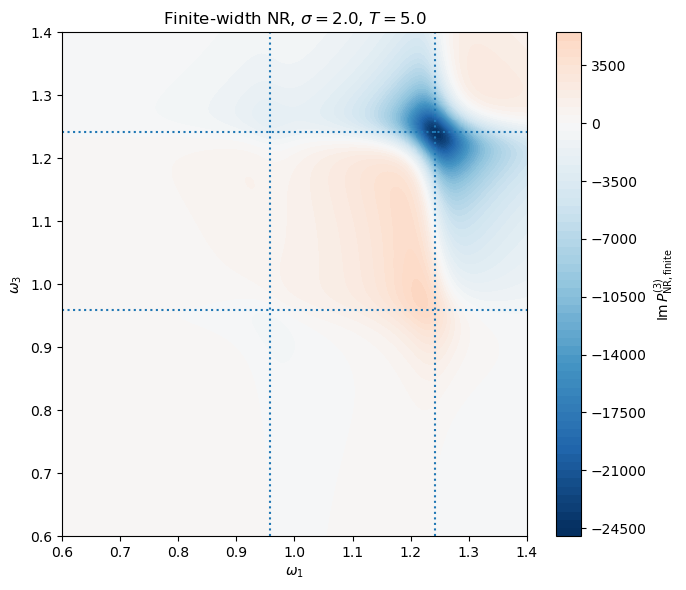

In [26]:
# ------------------------------------------------------------
# Nonrephasing finite-width spectrum
# ------------------------------------------------------------

nr_limit = np.max(
    np.abs(
        np.imag(P_NR_finite_grid)
    )
)

plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_nr,
    omega3_grid,
    np.imag(P_NR_finite_grid),
    levels=60,
    vmin=-nr_limit,
    vmax=nr_limit,
    cmap="RdBu_r",
)

plt.colorbar(
    label=r"$\mathrm{Im}\,P_{\mathrm{NR,finite}}^{(3)}$"
)

plt.axvline(Omega_minus, linestyle=":")
plt.axvline(Omega_plus, linestyle=":")
plt.axhline(Omega_minus, linestyle=":")
plt.axhline(Omega_plus, linestyle=":")

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    rf"Finite-width NR, $\sigma={sigma_1}$, $T={T_wait}$"
)

plt.tight_layout()
plt.show()

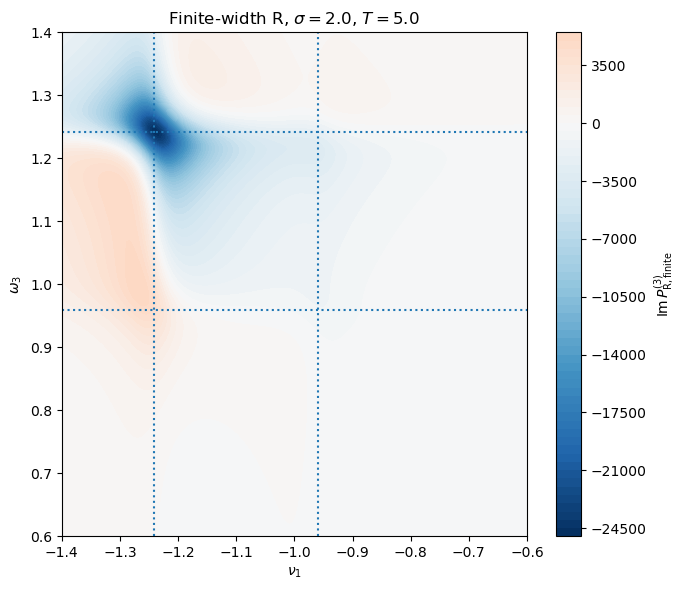

In [27]:
# ------------------------------------------------------------
# Rephasing finite-width spectrum
# ------------------------------------------------------------

r_limit = np.max(
    np.abs(
        np.imag(P_R_finite_grid)
    )
)

plt.figure(figsize=(7, 6))

plt.contourf(
    nu1_r,
    omega3_grid,
    np.imag(P_R_finite_grid),
    levels=60,
    vmin=-r_limit,
    vmax=r_limit,
    cmap="RdBu_r",
)

plt.colorbar(
    label=r"$\mathrm{Im}\,P_{\mathrm{R,finite}}^{(3)}$"
)

plt.axvline(-Omega_minus, linestyle=":")
plt.axvline(-Omega_plus, linestyle=":")
plt.axhline(Omega_minus, linestyle=":")
plt.axhline(Omega_plus, linestyle=":")

plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    rf"Finite-width R, $\sigma={sigma_1}$, $T={T_wait}$"
)

plt.tight_layout()
plt.show()

## 4. Comparison with the RWA descriptions

We now compare the full-\(V\) finite-width response with the conventional
RWA descriptions.

First, we calculate the impulsive RWA molecular responses

$$
M_{\mathrm{NR,RWA}}^{(3)}
=
\left\langle\!\left\langle\mu\right|
G(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\downarrow}
G(\omega_1)
V_{\uparrow}
\left|\rho_{\mathrm{ss}}\right\rangle\!\right\rangle ,
$$

and

$$
M_{\mathrm{R,RWA}}^{(3)}
=
\left\langle\!\left\langle\mu\right|
G(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\uparrow}
G(\nu_1)
V_{\downarrow}
\left|\rho_{\mathrm{ss}}\right\rangle\!\right\rangle .
$$

These contain no finite pulse envelopes.

The corresponding short-pulse RWA polarizations are

$$
P_{\mathrm{NR,short}}^{(3)}
=
E_3^{(+)}(\omega_3)
E_2^{(-)}(-\omega_1)
E_1^{(+)}(\omega_1)
M_{\mathrm{NR,RWA}}^{(3)},
$$

and

$$
P_{\mathrm{R,short}}^{(3)}
=
E_3^{(+)}(\omega_3)
E_2^{(+)}(-\nu_1)
E_1^{(-)}(\nu_1)
M_{\mathrm{R,RWA}}^{(3)}.
$$

The short-pulse RWA polarization is the direct reference for the finite-width
polarization because both include the same finite laser bandwidth.

The difference is that the short-pulse calculation imposes the RWA explicitly
through \(V_{\uparrow}\) and \(V_{\downarrow}\), whereas the finite-width calculation
retains the complete \(V\) and allows the \(F_j\) operators to perform
frequency-dependent dynamical filtering.

In [28]:
# ------------------------------------------------------------
# RWA interaction superoperators
# ------------------------------------------------------------

I_H = model["I4"]

mu_up = (
    model["sigma_a_plus"]
    + model["sigma_b_plus"]
)

mu_down = (
    model["sigma_a_minus"]
    + model["sigma_b_minus"]
)

V_up = (
    1j / hbar
    * (
        np.kron(I_H, mu_up)
        - np.kron(mu_up.T, I_H)
    )
)

V_down = (
    1j / hbar
    * (
        np.kron(I_H, mu_down)
        - np.kron(mu_down.T, I_H)
    )
)

print(
    "||V - (V_up + V_down)|| =",
    np.linalg.norm(V - (V_up + V_down)),
)

||V - (V_up + V_down)|| = 0.0


In [29]:
# ------------------------------------------------------------
# Impulsive RWA nonrephasing
# ------------------------------------------------------------

source_NR_RWA = np.zeros(
    (d**2, len(omega1_nr)),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr):

    x = V_up @ rho_ss_vec
    x = apply_G(omega1, x)
    x = V_down @ x
    x = prop_T @ x
    x = V_up @ x

    source_NR_RWA[:, i] = x


M_NR_RWA_grid = np.zeros(
    (len(omega3_grid), len(omega1_nr)),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_grid):

    X = apply_G(
        omega3,
        source_NR_RWA,
    )

    M_NR_RWA_grid[j, :] = mu_bra @ X


# ------------------------------------------------------------
# Impulsive RWA rephasing
# ------------------------------------------------------------

source_R_RWA = np.zeros(
    (d**2, len(nu1_r)),
    dtype=complex,
)

for i, nu1 in enumerate(nu1_r):

    x = V_down @ rho_ss_vec
    x = apply_G(nu1, x)
    x = V_up @ x
    x = prop_T @ x
    x = V_up @ x

    source_R_RWA[:, i] = x


M_R_RWA_grid = np.zeros(
    (len(omega3_grid), len(nu1_r)),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_grid):

    X = apply_G(
        omega3,
        source_R_RWA,
    )

    M_R_RWA_grid[j, :] = mu_bra @ X


print(
    "NR RWA all finite =",
    np.all(np.isfinite(M_NR_RWA_grid)),
)

print(
    "R RWA all finite  =",
    np.all(np.isfinite(M_R_RWA_grid)),
)

NR RWA all finite = True
R RWA all finite  = True


In [30]:
# ------------------------------------------------------------
# Scalar pulse spectra
# ------------------------------------------------------------

E1_NR = np.array([
    gaussian_spectrum(
        omega,
        +1,
        sigma_1,
        omega_L1,
        E0,
        Phi_1,
    )
    for omega in omega1_nr
])

E2_NR = np.array([
    gaussian_spectrum(
        -omega,
        -1,
        sigma_2,
        omega_L2,
        E0,
        Phi_2,
    )
    for omega in omega1_nr
])

E1_R = np.array([
    gaussian_spectrum(
        nu,
        -1,
        sigma_1,
        omega_L1,
        E0,
        Phi_1,
    )
    for nu in nu1_r
])

E2_R = np.array([
    gaussian_spectrum(
        -nu,
        +1,
        sigma_2,
        omega_L2,
        E0,
        Phi_2,
    )
    for nu in nu1_r
])

E3 = np.array([
    gaussian_spectrum(
        omega,
        +1,
        sigma_3,
        omega_L3,
        E0,
        Phi_3,
    )
    for omega in omega3_grid
])


# ------------------------------------------------------------
# Short-pulse RWA polarizations
# ------------------------------------------------------------

P_NR_short_grid = (
    E3[:, None]
    * (E2_NR * E1_NR)[None, :]
    * M_NR_RWA_grid
)

P_R_short_grid = (
    E3[:, None]
    * (E2_R * E1_R)[None, :]
    * M_R_RWA_grid
)

In [31]:
# ------------------------------------------------------------
# Full complex-grid comparison
# ------------------------------------------------------------

err_NR_short = (
    np.linalg.norm(
        P_NR_finite_grid - P_NR_short_grid
    )
    / np.linalg.norm(P_NR_short_grid)
)

err_R_short = (
    np.linalg.norm(
        P_R_finite_grid - P_R_short_grid
    )
    / np.linalg.norm(P_R_short_grid)
)

print("Finite-width vs short-pulse RWA")
print("--------------------------------")
print("NR relative error =", err_NR_short)
print("R  relative error =", err_R_short)

print()

print("Maximum amplitudes")
print("------------------")
print(
    "max |P_NR finite| =",
    np.max(np.abs(P_NR_finite_grid)),
)
print(
    "max |P_NR short|  =",
    np.max(np.abs(P_NR_short_grid)),
)
print(
    "max |P_R finite|  =",
    np.max(np.abs(P_R_finite_grid)),
)
print(
    "max |P_R short|   =",
    np.max(np.abs(P_R_short_grid)),
)

Finite-width vs short-pulse RWA
--------------------------------
NR relative error = 0.05563087633744551
R  relative error = 0.06008975350332906

Maximum amplitudes
------------------
max |P_NR finite| = 24647.184593776936
max |P_NR short|  = 24311.88901939287
max |P_R finite|  = 25224.62811034353
max |P_R short|   = 24929.24378542706


### 4.1 Impulsive RWA, short-pulse RWA, and finite-width spectra

We compare three levels of description:

1. the impulsive RWA molecular response \(M_{\mathrm{RWA}}^{(3)}\);
2. the short-pulse RWA polarization \(P_{\mathrm{short,RWA}}^{(3)}\);
3. the finite-width full-\(V\) polarization \(P_{\mathrm{finite}}^{(3)}\).

The impulsive molecular response does not contain the laser spectral factors and
therefore does not have the same overall amplitude scale as the two finite-pulse
polarizations.

For visual comparison of spectral structure, each spectrum is therefore normalized
by the maximum absolute value of its imaginary part.

The unnormalized complex spectra are retained for quantitative comparisons.

In [32]:
# ------------------------------------------------------------
# Normalize imaginary parts for shape comparison
# ------------------------------------------------------------

def normalize_imag(Z):
    Z_im = np.imag(Z)
    scale = np.max(np.abs(Z_im))

    if scale == 0:
        return Z_im

    return Z_im / scale


# Nonrephasing
NR_impulsive_norm = normalize_imag(M_NR_RWA_grid)
NR_short_norm = normalize_imag(P_NR_short_grid)
NR_finite_norm = normalize_imag(P_NR_finite_grid)

# Rephasing
R_impulsive_norm = normalize_imag(M_R_RWA_grid)
R_short_norm = normalize_imag(P_R_short_grid)
R_finite_norm = normalize_imag(P_R_finite_grid)

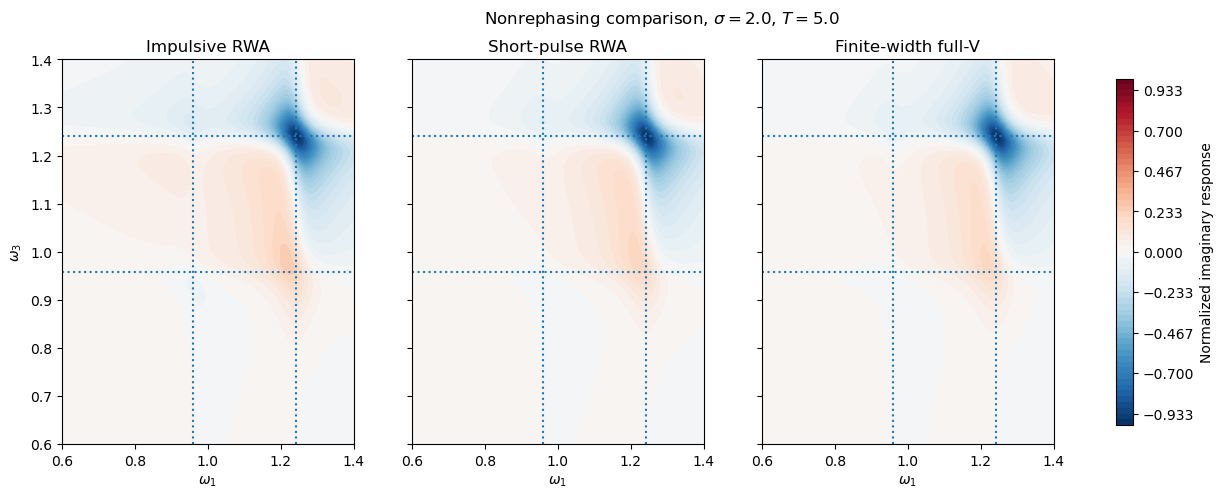

In [33]:
# ------------------------------------------------------------
# Nonrephasing comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

datasets = [
    NR_impulsive_norm,
    NR_short_norm,
    NR_finite_norm,
]

titles = [
    "Impulsive RWA",
    "Short-pulse RWA",
    "Finite-width full-V",
]

for ax, data, title in zip(axes, datasets, titles):

    contour = ax.contourf(
        omega1_nr,
        omega3_grid,
        data,
        levels=np.linspace(-1.0, 1.0, 61),
        vmin=-1.0,
        vmax=1.0,
        cmap="RdBu_r",
    )

    ax.axvline(Omega_minus, linestyle=":")
    ax.axvline(Omega_plus, linestyle=":")

    ax.axhline(Omega_minus, linestyle=":")
    ax.axhline(Omega_plus, linestyle=":")

    ax.set_xlabel(r"$\omega_1$")
    ax.set_title(title)

axes[0].set_ylabel(r"$\omega_3$")

fig.colorbar(
    contour,
    ax=axes,
    label="Normalized imaginary response",
    shrink=0.9,
)

fig.suptitle(
    rf"Nonrephasing comparison, $\sigma={sigma_1}$, $T={T_wait}$"
)

plt.show()

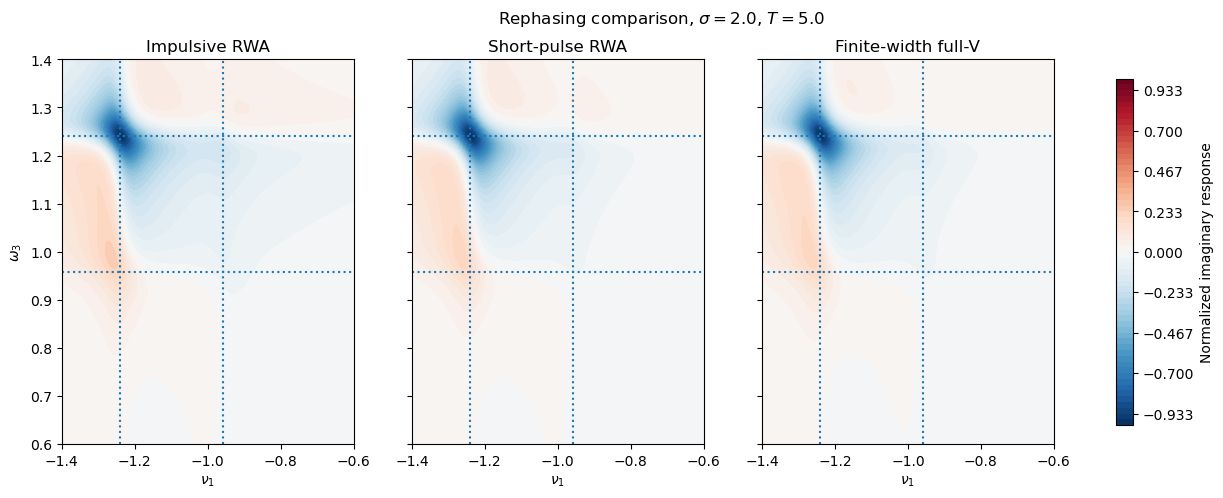

In [34]:
# ------------------------------------------------------------
# Rephasing comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

datasets = [
    R_impulsive_norm,
    R_short_norm,
    R_finite_norm,
]

titles = [
    "Impulsive RWA",
    "Short-pulse RWA",
    "Finite-width full-V",
]

for ax, data, title in zip(axes, datasets, titles):

    contour = ax.contourf(
        nu1_r,
        omega3_grid,
        data,
        levels=np.linspace(-1.0, 1.0, 61),
        vmin=-1.0,
        vmax=1.0,
        cmap="RdBu_r",
    )

    ax.axvline(-Omega_minus, linestyle=":")
    ax.axvline(-Omega_plus, linestyle=":")

    ax.axhline(Omega_minus, linestyle=":")
    ax.axhline(Omega_plus, linestyle=":")

    ax.set_xlabel(r"$\nu_1$")
    ax.set_title(title)

axes[0].set_ylabel(r"$\omega_3$")

fig.colorbar(
    contour,
    ax=axes,
    label="Normalized imaginary response",
    shrink=0.9,
)

fig.suptitle(
    rf"Rephasing comparison, $\sigma={sigma_1}$, $T={T_wait}$"
)

plt.show()

In [35]:
# ------------------------------------------------------------
# Shape comparison with impulsive RWA
# ------------------------------------------------------------

def optimal_complex_scale(reference, target):
    """
    Find alpha minimizing

        ||target - alpha * reference||_2.
    """

    ref = reference.ravel()
    tgt = target.ravel()

    alpha = np.vdot(ref, tgt) / np.vdot(ref, ref)

    residual = (
        np.linalg.norm(tgt - alpha * ref)
        / np.linalg.norm(tgt)
    )

    return alpha, residual


alpha_NR_imp, err_NR_imp_shape = optimal_complex_scale(
    M_NR_RWA_grid,
    P_NR_finite_grid,
)

alpha_R_imp, err_R_imp_shape = optimal_complex_scale(
    M_R_RWA_grid,
    P_R_finite_grid,
)


print("Finite-width vs impulsive RWA shape")
print("------------------------------------")

print("NR:")
print("alpha =", alpha_NR_imp)
print("shape residual =", err_NR_imp_shape)

print()

print("R:")
print("alpha =", alpha_R_imp)
print("shape residual =", err_R_imp_shape)

Finite-width vs impulsive RWA shape
------------------------------------
NR:
alpha = (14.895461456375823+0.26015499063065395j)
shape residual = 0.1443977739173377

R:
alpha = (14.805526754612165-0.32086351018430337j)
shape residual = 0.150523618562213


## 5. Pulse-width dependence and emergent RWA filtering

We now vary the Gaussian pulse width \(\sigma\) and compare the full-\(V\)
finite-width response with the conventional short-pulse RWA response.

For each pulse width we calculate

$$
\epsilon_{\mathrm{NR}}(\sigma)
=
\frac{
\left\|
P_{\mathrm{NR,finite}}^{(3)}(\sigma)
-
P_{\mathrm{NR,short}}^{(3)}(\sigma)
\right\|_2
}{
\left\|
P_{\mathrm{NR,short}}^{(3)}(\sigma)
\right\|_2
},
$$

and similarly for the rephasing response,

$$
\epsilon_{\mathrm{R}}(\sigma)
=
\frac{
\left\|
P_{\mathrm{R,finite}}^{(3)}(\sigma)
-
P_{\mathrm{R,short}}^{(3)}(\sigma)
\right\|_2
}{
\left\|
P_{\mathrm{R,short}}^{(3)}(\sigma)
\right\|_2
}.
$$

The finite-width calculation retains the complete interaction \(V\), whereas
the short-pulse reference explicitly uses the RWA interactions
\(V_{\uparrow}\) and \(V_{\downarrow}\).

For very short pulses, counter-rotating contributions are expected to survive.
As the pulse width increases, the \(F_j\) operators should suppress strongly
mismatched Liouvillian modes and produce an RWA-like response.

For still longer pulses, the molecular evolution occurring across the pulse
envelope can become important, so the finite-width result need not coincide
with the short-pulse approximation even when the RWA itself remains accurate.

Because the finite-width derivation assumes temporally separated pulses, this
scan uses a larger waiting time and restricts the maximum pulse width so that
pulse overlap remains negligible.

In [36]:
# ------------------------------------------------------------
# Pulse-width scan parameters
# ------------------------------------------------------------

T_scan = 20.0
prop_T_scan = expm(L * T_scan)

n_scan = 81

omega1_nr_scan = np.linspace(0.6, 1.4, n_scan)
nu1_r_scan = np.linspace(-1.4, -0.6, n_scan)
omega3_scan = np.linspace(0.6, 1.4, n_scan)

sigma_values = np.array([
    0.10,
    0.15,
    0.20,
    0.30,
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
    2.50,
    3.00,
])

print("T_scan =", T_scan)
print("Grid   =", n_scan, "x", n_scan)
print("Sigma values =", sigma_values)
print()
print("Minimum T/sigma =", T_scan / np.max(sigma_values))

T_scan = 20.0
Grid   = 81 x 81
Sigma values = [0.1  0.15 0.2  0.3  0.5  0.75 1.   1.25 1.5  1.75 2.   2.5  3.  ]

Minimum T/sigma = 6.666666666666667


In [37]:
# ------------------------------------------------------------
# Impulsive RWA molecular responses for the sigma scan
# ------------------------------------------------------------

M_NR_RWA_scan = np.zeros(
    (n_scan, n_scan),
    dtype=complex,
)

M_R_RWA_scan = np.zeros(
    (n_scan, n_scan),
    dtype=complex,
)


# Nonrephasing
source_NR = np.zeros(
    (d**2, n_scan),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    x = V_up @ rho_ss_vec
    x = apply_G(omega1, x)
    x = V_down @ x
    x = prop_T_scan @ x
    x = V_up @ x

    source_NR[:, i] = x

for j, omega3 in enumerate(omega3_scan):

    X = apply_G(
        omega3,
        source_NR,
    )

    M_NR_RWA_scan[j, :] = mu_bra @ X


# Rephasing
source_R = np.zeros(
    (d**2, n_scan),
    dtype=complex,
)

for i, nu1 in enumerate(nu1_r_scan):

    x = V_down @ rho_ss_vec
    x = apply_G(nu1, x)
    x = V_up @ x
    x = prop_T_scan @ x
    x = V_up @ x

    source_R[:, i] = x

for j, omega3 in enumerate(omega3_scan):

    X = apply_G(
        omega3,
        source_R,
    )

    M_R_RWA_scan[j, :] = mu_bra @ X


print("RWA reference grids complete.")

RWA reference grids complete.


In [38]:
def finite_width_grids(
    sigma,
    prop_T_use,
    omega1_nr_axis,
    nu1_r_axis,
    omega3_axis,
):
    """
    Calculate full-V finite-width NR and R spectra
    using F1, F2, and F3 explicitly.
    """

    # ========================================================
    # Nonrephasing (+, -, +)
    # ========================================================

    source_NR = np.zeros(
        (d**2, len(omega1_nr_axis)),
        dtype=complex,
    )

    for i, omega1 in enumerate(omega1_nr_axis):

        F1_op = F1(
            omega1,
            +1,
            sigma,
            omega_L1,
            L,
            I_L,
            E0,
            Phi_1,
        )

        F2_op = F2(
            omega1,
            -1,
            sigma,
            omega_L2,
            L,
            I_L,
            E0,
            Phi_2,
        )

        x = F1_op @ rho_ss_vec
        x = V @ x
        x = apply_G(omega1, x)
        x = V @ x
        x = F2_op @ x

        source_NR[:, i] = x

    P_NR = np.zeros(
        (
            len(omega3_axis),
            len(omega1_nr_axis),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_axis):

        F3_op = F3(
            omega3,
            +1,
            sigma,
            omega_L3,
            L,
            I_L,
            E0,
            Phi_3,
        )

        X = F3_op @ source_NR
        X = prop_T_use @ X
        X = V @ X
        X = apply_G(omega3, X)

        P_NR[j, :] = mu_bra @ X

    # ========================================================
    # Rephasing (-, +, +)
    # ========================================================

    source_R = np.zeros(
        (d**2, len(nu1_r_axis)),
        dtype=complex,
    )

    for i, nu1 in enumerate(nu1_r_axis):

        F1_op = F1(
            nu1,
            -1,
            sigma,
            omega_L1,
            L,
            I_L,
            E0,
            Phi_1,
        )

        F2_op = F2(
            nu1,
            +1,
            sigma,
            omega_L2,
            L,
            I_L,
            E0,
            Phi_2,
        )

        x = F1_op @ rho_ss_vec
        x = V @ x
        x = apply_G(nu1, x)
        x = V @ x
        x = F2_op @ x

        source_R[:, i] = x

    P_R = np.zeros(
        (
            len(omega3_axis),
            len(nu1_r_axis),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_axis):

        F3_op = F3(
            omega3,
            +1,
            sigma,
            omega_L3,
            L,
            I_L,
            E0,
            Phi_3,
        )

        X = F3_op @ source_R
        X = prop_T_use @ X
        X = V @ X
        X = apply_G(omega3, X)

        P_R[j, :] = mu_bra @ X

    return P_NR, P_R

In [39]:
def short_rwa_grids(
    sigma,
    M_NR,
    M_R,
    omega1_nr_axis,
    nu1_r_axis,
    omega3_axis,
):
    """
    Dress the impulsive RWA molecular response with
    scalar Gaussian laser spectra.
    """

    E1_NR = np.array([
        gaussian_spectrum(
            omega,
            +1,
            sigma,
            omega_L1,
            E0,
            Phi_1,
        )
        for omega in omega1_nr_axis
    ])

    E2_NR = np.array([
        gaussian_spectrum(
            -omega,
            -1,
            sigma,
            omega_L2,
            E0,
            Phi_2,
        )
        for omega in omega1_nr_axis
    ])

    E1_R = np.array([
        gaussian_spectrum(
            nu,
            -1,
            sigma,
            omega_L1,
            E0,
            Phi_1,
        )
        for nu in nu1_r_axis
    ])

    E2_R = np.array([
        gaussian_spectrum(
            -nu,
            +1,
            sigma,
            omega_L2,
            E0,
            Phi_2,
        )
        for nu in nu1_r_axis
    ])

    E3 = np.array([
        gaussian_spectrum(
            omega,
            +1,
            sigma,
            omega_L3,
            E0,
            Phi_3,
        )
        for omega in omega3_axis
    ])

    P_NR_short = (
        E3[:, None]
        * (E2_NR * E1_NR)[None, :]
        * M_NR
    )

    P_R_short = (
        E3[:, None]
        * (E2_R * E1_R)[None, :]
        * M_R
    )

    return P_NR_short, P_R_short

In [40]:
# ------------------------------------------------------------
# Sigma scan
# ------------------------------------------------------------

err_NR_sigma = []
err_R_sigma = []

max_NR_finite_sigma = []
max_NR_short_sigma = []

max_R_finite_sigma = []
max_R_short_sigma = []


for sigma in sigma_values:

    print(f"sigma = {sigma:.2f}")

    # Full-V finite-width
    P_NR_fin, P_R_fin = finite_width_grids(
        sigma=sigma,
        prop_T_use=prop_T_scan,
        omega1_nr_axis=omega1_nr_scan,
        nu1_r_axis=nu1_r_scan,
        omega3_axis=omega3_scan,
    )

    # Explicit short-pulse RWA
    P_NR_sh, P_R_sh = short_rwa_grids(
        sigma=sigma,
        M_NR=M_NR_RWA_scan,
        M_R=M_R_RWA_scan,
        omega1_nr_axis=omega1_nr_scan,
        nu1_r_axis=nu1_r_scan,
        omega3_axis=omega3_scan,
    )

    # Complex two-dimensional relative errors
    err_NR = (
        np.linalg.norm(P_NR_fin - P_NR_sh)
        / np.linalg.norm(P_NR_sh)
    )

    err_R = (
        np.linalg.norm(P_R_fin - P_R_sh)
        / np.linalg.norm(P_R_sh)
    )

    err_NR_sigma.append(err_NR)
    err_R_sigma.append(err_R)

    max_NR_finite_sigma.append(
        np.max(np.abs(P_NR_fin))
    )

    max_NR_short_sigma.append(
        np.max(np.abs(P_NR_sh))
    )

    max_R_finite_sigma.append(
        np.max(np.abs(P_R_fin))
    )

    max_R_short_sigma.append(
        np.max(np.abs(P_R_sh))
    )


err_NR_sigma = np.array(err_NR_sigma)
err_R_sigma = np.array(err_R_sigma)

max_NR_finite_sigma = np.array(max_NR_finite_sigma)
max_NR_short_sigma = np.array(max_NR_short_sigma)

max_R_finite_sigma = np.array(max_R_finite_sigma)
max_R_short_sigma = np.array(max_R_short_sigma)

print()
print("Sigma scan complete.")

sigma = 0.10
sigma = 0.15
sigma = 0.20
sigma = 0.30
sigma = 0.50
sigma = 0.75
sigma = 1.00
sigma = 1.25
sigma = 1.50
sigma = 1.75
sigma = 2.00
sigma = 2.50
sigma = 3.00

Sigma scan complete.


In [41]:
print("sigma      NR error      R error")
print("--------------------------------")

for sigma, err_nr, err_r in zip(
    sigma_values,
    err_NR_sigma,
    err_R_sigma,
):
    print(
        f"{sigma:5.2f}      "
        f"{err_nr:10.6f}    "
        f"{err_r:10.6f}"
    )

sigma      NR error      R error
--------------------------------
 0.10        0.450205      0.085837
 0.15        0.422211      0.084566
 0.20        0.386059      0.082915
 0.30        0.299814      0.078910
 0.50        0.141529      0.070933
 0.75        0.065143      0.064923
 1.00        0.057767      0.062508
 1.25        0.056683      0.061634
 1.50        0.057048      0.061681
 1.75        0.058730      0.062740
 2.00        0.061812      0.064960
 2.50        0.072051      0.073080
 3.00        0.086890      0.085808


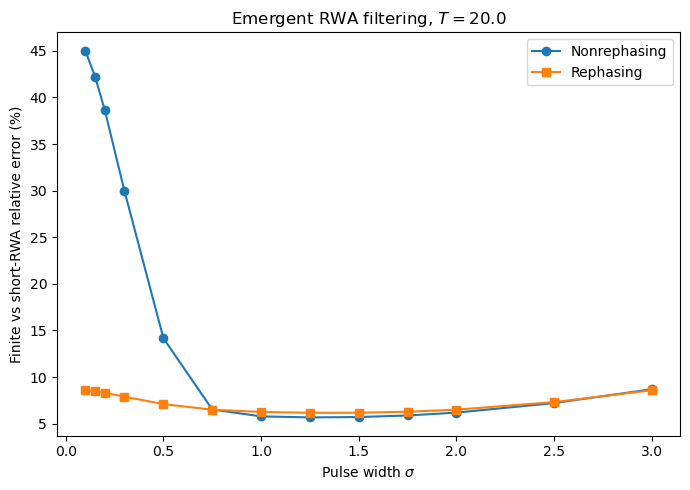

In [42]:
plt.figure(figsize=(7, 5))

plt.plot(
    sigma_values,
    100.0 * err_NR_sigma,
    marker="o",
    label="Nonrephasing",
)

plt.plot(
    sigma_values,
    100.0 * err_R_sigma,
    marker="s",
    label="Rephasing",
)

plt.xlabel(r"Pulse width $\sigma$")
plt.ylabel("Finite vs short-RWA relative error (%)")

plt.title(
    rf"Emergent RWA filtering, $T={T_scan}$"
)

plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Dependence on the numerical resolvent broadening

The causal resolvent is evaluated numerically as

$$
G_\eta(\omega)
=
\left[
(\eta-i\omega)I-\mathcal{L}
\right]^{-1},
$$

where \(\eta>0\) is a numerical Fourier broadening parameter.

The analytical pulse operators \(F_1,F_2,F_3\) are kept unchanged. We now test
whether the residual difference between the finite-width and short-pulse RWA
calculations depends appreciably on \(\eta\).

We fix

$$
\sigma = 1.25,
\qquad
T = 20,
$$

near the minimum of the pulse-width comparison, and vary \(\eta\).

If the approximately \(6\%\) residual remains stable as \(\eta\) decreases, it
cannot be attributed primarily to the artificial resolvent broadening.

In [43]:
def apply_G_eta(
    omega,
    x,
    eta_value,
):
    """
    Apply

        G_eta(omega)
        = [(eta - i*omega) I - L]^{-1}

    with eta supplied explicitly.
    """

    A = (
        (eta_value - 1j * omega) * I_L
        - L
    )

    return np.linalg.solve(A, x)

In [44]:
def finite_width_grids_eta(
    sigma,
    eta_value,
    prop_T_use,
    omega1_nr_axis,
    nu1_r_axis,
    omega3_axis,
):
    """
    Full-V finite-width NR and R spectra using analytical
    F1, F2, F3 and an explicitly selected resolvent eta.
    """

    # ========================================================
    # Nonrephasing (+, -, +)
    # ========================================================

    source_NR = np.zeros(
        (d**2, len(omega1_nr_axis)),
        dtype=complex,
    )

    for i, omega1 in enumerate(omega1_nr_axis):

        F1_op = F1(
            omega1,
            +1,
            sigma,
            omega_L1,
            L,
            I_L,
            E0,
            Phi_1,
        )

        F2_op = F2(
            omega1,
            -1,
            sigma,
            omega_L2,
            L,
            I_L,
            E0,
            Phi_2,
        )

        x = F1_op @ rho_ss_vec
        x = V @ x
        x = apply_G_eta(omega1, x, eta_value)
        x = V @ x
        x = F2_op @ x

        source_NR[:, i] = x

    P_NR = np.zeros(
        (
            len(omega3_axis),
            len(omega1_nr_axis),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_axis):

        F3_op = F3(
            omega3,
            +1,
            sigma,
            omega_L3,
            L,
            I_L,
            E0,
            Phi_3,
        )

        X = F3_op @ source_NR
        X = prop_T_use @ X
        X = V @ X
        X = apply_G_eta(
            omega3,
            X,
            eta_value,
        )

        P_NR[j, :] = mu_bra @ X

    # ========================================================
    # Rephasing (-, +, +)
    # ========================================================

    source_R = np.zeros(
        (d**2, len(nu1_r_axis)),
        dtype=complex,
    )

    for i, nu1 in enumerate(nu1_r_axis):

        F1_op = F1(
            nu1,
            -1,
            sigma,
            omega_L1,
            L,
            I_L,
            E0,
            Phi_1,
        )

        F2_op = F2(
            nu1,
            +1,
            sigma,
            omega_L2,
            L,
            I_L,
            E0,
            Phi_2,
        )

        x = F1_op @ rho_ss_vec
        x = V @ x
        x = apply_G_eta(nu1, x, eta_value)
        x = V @ x
        x = F2_op @ x

        source_R[:, i] = x

    P_R = np.zeros(
        (
            len(omega3_axis),
            len(nu1_r_axis),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_axis):

        F3_op = F3(
            omega3,
            +1,
            sigma,
            omega_L3,
            L,
            I_L,
            E0,
            Phi_3,
        )

        X = F3_op @ source_R
        X = prop_T_use @ X
        X = V @ X
        X = apply_G_eta(
            omega3,
            X,
            eta_value,
        )

        P_R[j, :] = mu_bra @ X

    return P_NR, P_R

In [45]:
def rwa_molecular_grids_eta(
    eta_value,
    prop_T_use,
    omega1_nr_axis,
    nu1_r_axis,
    omega3_axis,
):
    """
    Impulsive RWA molecular NR and R spectra for a selected eta.
    """

    # ========================================================
    # Nonrephasing
    # ========================================================

    source_NR = np.zeros(
        (d**2, len(omega1_nr_axis)),
        dtype=complex,
    )

    for i, omega1 in enumerate(omega1_nr_axis):

        x = V_up @ rho_ss_vec
        x = apply_G_eta(
            omega1,
            x,
            eta_value,
        )
        x = V_down @ x
        x = prop_T_use @ x
        x = V_up @ x

        source_NR[:, i] = x

    M_NR = np.zeros(
        (
            len(omega3_axis),
            len(omega1_nr_axis),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_axis):

        X = apply_G_eta(
            omega3,
            source_NR,
            eta_value,
        )

        M_NR[j, :] = mu_bra @ X

    # ========================================================
    # Rephasing
    # ========================================================

    source_R = np.zeros(
        (d**2, len(nu1_r_axis)),
        dtype=complex,
    )

    for i, nu1 in enumerate(nu1_r_axis):

        x = V_down @ rho_ss_vec
        x = apply_G_eta(
            nu1,
            x,
            eta_value,
        )
        x = V_up @ x
        x = prop_T_use @ x
        x = V_up @ x

        source_R[:, i] = x

    M_R = np.zeros(
        (
            len(omega3_axis),
            len(nu1_r_axis),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_axis):

        X = apply_G_eta(
            omega3,
            source_R,
            eta_value,
        )

        M_R[j, :] = mu_bra @ X

    return M_NR, M_R

In [46]:
sigma_eta = 1.25

eta_values = np.array([
    0.040,
    0.020,
    0.010,
    0.005,
    0.002,
])

err_NR_eta = []
err_R_eta = []


for eta_test in eta_values:

    print(f"eta = {eta_test:.3f}")

    # --------------------------------------------------------
    # RWA molecular response at this eta
    # --------------------------------------------------------

    M_NR_eta, M_R_eta = rwa_molecular_grids_eta(
        eta_value=eta_test,
        prop_T_use=prop_T_scan,
        omega1_nr_axis=omega1_nr_scan,
        nu1_r_axis=nu1_r_scan,
        omega3_axis=omega3_scan,
    )

    # --------------------------------------------------------
    # Short-pulse RWA polarization
    # --------------------------------------------------------

    P_NR_short_eta, P_R_short_eta = short_rwa_grids(
        sigma=sigma_eta,
        M_NR=M_NR_eta,
        M_R=M_R_eta,
        omega1_nr_axis=omega1_nr_scan,
        nu1_r_axis=nu1_r_scan,
        omega3_axis=omega3_scan,
    )

    # --------------------------------------------------------
    # Full-V finite-width response
    # --------------------------------------------------------

    P_NR_fin_eta, P_R_fin_eta = finite_width_grids_eta(
        sigma=sigma_eta,
        eta_value=eta_test,
        prop_T_use=prop_T_scan,
        omega1_nr_axis=omega1_nr_scan,
        nu1_r_axis=nu1_r_scan,
        omega3_axis=omega3_scan,
    )

    # --------------------------------------------------------
    # Complex 2D relative errors
    # --------------------------------------------------------

    err_NR = (
        np.linalg.norm(
            P_NR_fin_eta - P_NR_short_eta
        )
        / np.linalg.norm(P_NR_short_eta)
    )

    err_R = (
        np.linalg.norm(
            P_R_fin_eta - P_R_short_eta
        )
        / np.linalg.norm(P_R_short_eta)
    )

    err_NR_eta.append(err_NR)
    err_R_eta.append(err_R)


err_NR_eta = np.array(err_NR_eta)
err_R_eta = np.array(err_R_eta)

print()
print("eta scan complete.")

eta = 0.040
eta = 0.020
eta = 0.010
eta = 0.005
eta = 0.002

eta scan complete.


In [47]:
print("eta       NR error      R error")
print("--------------------------------")

for eta_test, err_nr, err_r in zip(
    eta_values,
    err_NR_eta,
    err_R_eta,
):
    print(
        f"{eta_test:5.3f}     "
        f"{err_nr:10.6f}    "
        f"{err_r:10.6f}"
    )

eta       NR error      R error
--------------------------------
0.040       0.068296      0.076408
0.020       0.056683      0.061634
0.010       0.050431      0.053929
0.005       0.047126      0.049916
0.002       0.045068      0.047434


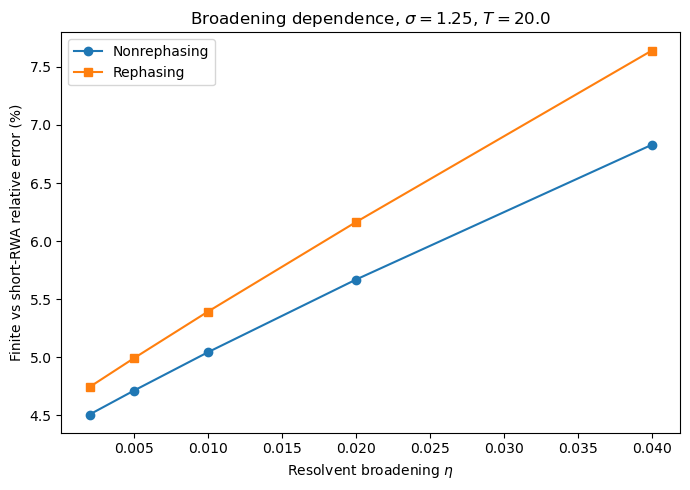

In [48]:
plt.figure(figsize=(7, 5))

plt.plot(
    eta_values,
    100.0 * err_NR_eta,
    marker="o",
    label="Nonrephasing",
)

plt.plot(
    eta_values,
    100.0 * err_R_eta,
    marker="s",
    label="Rephasing",
)

plt.xlabel(r"Resolvent broadening $\eta$")
plt.ylabel("Finite vs short-RWA relative error (%)")

plt.title(
    rf"Broadening dependence, $\sigma={sigma_eta}$, $T={T_scan}$"
)

plt.legend()
plt.tight_layout()
plt.show()

## 6. Explicit finite-pulse time-domain benchmark

The finite-width frequency-domain expression will now be tested against an
independent explicit time-domain propagation.

For a selected field-sign signature
\((s_1,s_2,s_3)\), we propagate the perturbative hierarchy

$$
\frac{d}{dt}|\rho^{(0)}\rangle\rangle
=
\mathcal{L}|\rho^{(0)}\rangle\rangle,
$$

$$
\frac{d}{dt}|\rho^{(1)}\rangle\rangle
=
\mathcal{L}|\rho^{(1)}\rangle\rangle
+
E_1^{(s_1)}(t)
V|\rho^{(0)}\rangle\rangle,
$$

$$
\frac{d}{dt}|\rho^{(2)}\rangle\rangle
=
\mathcal{L}|\rho^{(2)}\rangle\rangle
+
E_2^{(s_2)}(t)
V|\rho^{(1)}\rangle\rangle,
$$

and

$$
\frac{d}{dt}|\rho^{(3)}\rangle\rangle
=
\mathcal{L}|\rho^{(3)}\rangle\rangle
+
E_3^{(s_3)}(t)
V|\rho^{(2)}\rangle\rangle.
$$

The third-order polarization is

$$
P^{(3)}(t)
=
\left\langle\!\left\langle
\mu|\rho^{(3)}(t)
\right\rangle\!\right\rangle.
$$

The complete interaction \(V\) is retained throughout.

The nonrephasing and rephasing contributions are selected only through the
field signatures

$$
(+,-,+)
$$

and

$$
(-,+,+),
$$

respectively.

This provides an independent time-domain benchmark of the analytical
\(F_1F_2F_3\) finite-width frequency-domain formulation.

In [49]:
def pulse_component(
    t,
    tau,
    s,
    sigma,
    omega_L,
    E0=1.0,
    Phi=0.0,
):
    """
    Signed Gaussian field component centered at time tau.
    """

    u = t - tau

    return (
        0.5 * E0
        * np.exp(-u**2 / (2.0 * sigma**2))
        * np.exp(1j * s * Phi)
        * np.exp(-1j * s * omega_L * u)
    )

In [50]:
def finite_pulse_rhs(
    t,
    y,
    tau1,
    tau2,
    tau3,
    s1,
    s2,
    s3,
    sigma,
):
    """
    Explicit perturbative third-order finite-pulse dynamics.

    y contains:
        rho^(0), rho^(1), rho^(2), rho^(3)

    each as a Liouville-space vector.
    """

    nL = d**2

    rho0_t = y[0*nL:1*nL]
    rho1_t = y[1*nL:2*nL]
    rho2_t = y[2*nL:3*nL]
    rho3_t = y[3*nL:4*nL]

    E1_t = pulse_component(
        t,
        tau1,
        s1,
        sigma,
        omega_L1,
        E0,
        Phi_1,
    )

    E2_t = pulse_component(
        t,
        tau2,
        s2,
        sigma,
        omega_L2,
        E0,
        Phi_2,
    )

    E3_t = pulse_component(
        t,
        tau3,
        s3,
        sigma,
        omega_L3,
        E0,
        Phi_3,
    )

    drho0 = L @ rho0_t

    drho1 = (
        L @ rho1_t
        + E1_t * (V @ rho0_t)
    )

    drho2 = (
        L @ rho2_t
        + E2_t * (V @ rho1_t)
    )

    drho3 = (
        L @ rho3_t
        + E3_t * (V @ rho2_t)
    )

    return np.concatenate([
        drho0,
        drho1,
        drho2,
        drho3,
    ])

In [51]:
sigma_ode = 1.25

tau1_test = 0.0
tau2_test = 10.0
tau3_test = tau2_test + T_scan

nL = d**2

y0 = np.zeros(
    4 * nL,
    dtype=complex,
)

y0[0:nL] = rho_ss_vec

t_start = tau1_test - 8.0 * sigma_ode
t_stop = tau3_test + 8.0 * sigma_ode

sol_NR_test = solve_ivp(
    finite_pulse_rhs,
    (t_start, t_stop),
    y0,
    args=(
        tau1_test,
        tau2_test,
        tau3_test,
        +1,
        -1,
        +1,
        sigma_ode,
    ),
    rtol=1e-9,
    atol=1e-11,
)

rho3_final_NR = sol_NR_test.y[
    3*nL:4*nL,
    -1,
]

P3_final_NR = mu_bra @ rho3_final_NR

print("ODE success =", sol_NR_test.success)
print("Number of time steps =", len(sol_NR_test.t))
print("Final NR P^(3) =", P3_final_NR)
print("|P^(3)| =", abs(P3_final_NR))

ODE success = True
Number of time steps = 992
Final NR P^(3) = (0.6320534920224005-4.153059579054791j)
|P^(3)| = 4.200880322498662


### 6.1 Separated-pulse ODE benchmark

The finite-width frequency-domain formulation assumes that the three pulses are
temporally separated.

A direct time-domain pulse simulation must therefore be compared in the same
regime. In particular, the first pulse-center separation is restricted to

$$
t_1 \ge t_{1,\min},
$$

with \(t_{1,\min}\) several pulse widths, so that pulse overlap is negligible.

Because the numerical time-domain transform is then performed over
\([t_{1,\min},\infty)\) rather than \([0,\infty)\), the corresponding
frequency-domain propagator is

$$
G_{\eta}^{(t_{1,\min})}(\omega)
=
e^{(\mathcal{L}+i\omega I-\eta I)t_{1,\min}}
G_\eta(\omega).
$$

Using the same time window in both calculations prevents pulse-overlap effects
from being confused with errors in the finite-width \(F_1F_2F_3\) formulation.

In [52]:
# ------------------------------------------------------------
# Separated-pulse benchmark window
# ------------------------------------------------------------

sigma_ode = 1.25

t1_min = 6.0 * sigma_ode
t1_max = 100.0

dt1 = 0.25

t1_ode = np.arange(
    t1_min,
    t1_max + 0.5 * dt1,
    dt1,
)

print("sigma       =", sigma_ode)
print("t1_min      =", t1_min)
print("t1_min/sigma=", t1_min / sigma_ode)
print("t1 points   =", len(t1_ode))

sigma       = 1.25
t1_min      = 7.5
t1_min/sigma= 6.0
t1 points   = 371


In [53]:
def apply_G_windowed(
    omega,
    x,
    eta_value,
    t_min,
):
    """
    Apply

        integral from t_min to infinity of
        exp[(i*omega - eta)t] exp(L t) dt

    to x.
    """

    Gx = apply_G_eta(
        omega,
        x,
        eta_value,
    )

    shift = expm(
        (
            L
            + (1j * omega - eta_value) * I_L
        )
        * t_min
    )

    return shift @ Gx

### 6.2 Frequency-domain comparison along the main detection resonance

We first compare the explicit finite-pulse ODE with the frequency-domain
theories along a one-dimensional cut through the dominant detection resonance,

$$
\omega_3 = \Omega_+.
$$

The ODE is evaluated as a function of the pulse-center coherence delay \(t_1\).
For each \(t_1\), the third-order polarization is recorded as a function of the
detection delay \(t_3\).

The same damped Fourier convention is then applied,

$$
P^{(3)}(\omega_3,\omega_1)
=
\int dt_1
\int dt_3\,
e^{(i\omega_1-\eta)t_1}
e^{(i\omega_3-\eta)t_3}
P^{(3)}(t_3,t_1).
$$

To ensure an exact numerical comparison, the frequency-domain calculations use
the same finite \(t_1\) and \(t_3\) integration windows as the ODE transform.

The three calculations compared are

$$
P_{\mathrm{ODE}}^{(3)},
\qquad
P_{\mathrm{finite}}^{(3)},
\qquad
P_{\mathrm{short,RWA}}^{(3)}.
$$

In [54]:
# ------------------------------------------------------------
# ODE benchmark grid
# ------------------------------------------------------------

sigma_ode = 1.25
eta_ode = 0.02

t1_min_ode = 6.0 * sigma_ode
t1_max_ode = 80.0
dt1_ode = 0.5

t3_min_ode = 0.0
t3_max_ode = 80.0
dt3_ode = 0.5

t1_ode = np.arange(
    t1_min_ode,
    t1_max_ode + 0.5 * dt1_ode,
    dt1_ode,
)

t3_ode = np.arange(
    t3_min_ode,
    t3_max_ode + 0.5 * dt3_ode,
    dt3_ode,
)

print("sigma =", sigma_ode)
print("eta   =", eta_ode)
print()
print("t1 range =", t1_ode[0], "to", t1_ode[-1])
print("t1 points =", len(t1_ode))
print()
print("t3 range =", t3_ode[0], "to", t3_ode[-1])
print("t3 points =", len(t3_ode))

sigma = 1.25
eta   = 0.02

t1 range = 7.5 to 80.0
t1 points = 146

t3 range = 0.0 to 80.0
t3 points = 161


In [55]:
def finite_pulse_rhs_stationary(
    t,
    y,
    tau1,
    tau2,
    tau3,
    s1,
    s2,
    s3,
    sigma,
):
    """
    Sequential perturbative finite-pulse hierarchy for a
    stationary zeroth-order state.

    y contains rho^(1), rho^(2), rho^(3).
    """

    nL = d**2

    rho1_t = y[0*nL:1*nL]
    rho2_t = y[1*nL:2*nL]
    rho3_t = y[2*nL:3*nL]

    E1_t = pulse_component(
        t,
        tau1,
        s1,
        sigma,
        omega_L1,
        E0,
        Phi_1,
    )

    E2_t = pulse_component(
        t,
        tau2,
        s2,
        sigma,
        omega_L2,
        E0,
        Phi_2,
    )

    E3_t = pulse_component(
        t,
        tau3,
        s3,
        sigma,
        omega_L3,
        E0,
        Phi_3,
    )

    drho1 = (
        L @ rho1_t
        + E1_t * (V @ rho_ss_vec)
    )

    drho2 = (
        L @ rho2_t
        + E2_t * (V @ rho1_t)
    )

    drho3 = (
        L @ rho3_t
        + E3_t * (V @ rho2_t)
    )

    return np.concatenate([
        drho1,
        drho2,
        drho3,
    ])

In [56]:
def ode_time_domain_grid(
    s1,
    s2,
    s3,
    sigma,
    T,
    t1_axis,
    t3_axis,
):
    """
    Explicit finite-pulse third-order polarization

        P^(3)(t3, T, t1)

    for one field-sign signature.
    """

    nL = d**2

    y0 = np.zeros(
        3 * nL,
        dtype=complex,
    )

    P_td = np.zeros(
        (
            len(t3_axis),
            len(t1_axis),
        ),
        dtype=complex,
    )

    tau1 = 0.0

    for i, t1 in enumerate(t1_axis):

        if i % 20 == 0:
            print(
                f"t1 {i + 1}/{len(t1_axis)}"
            )

        tau2 = t1
        tau3 = t1 + T

        t_start = tau1 - 8.0 * sigma
        t_stop = tau3 + t3_axis[-1]

        detection_times = (
            tau3 + t3_axis
        )

        sol = solve_ivp(
            finite_pulse_rhs_stationary,
            (t_start, t_stop),
            y0,
            t_eval=detection_times,
            args=(
                tau1,
                tau2,
                tau3,
                s1,
                s2,
                s3,
                sigma,
            ),
            rtol=1e-8,
            atol=1e-10,
            max_step=0.2,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        rho3 = sol.y[
            2*nL:3*nL,
            :
        ]

        P_td[:, i] = (
            mu_bra @ rho3
        )

    return P_td

In [57]:
# ------------------------------------------------------------
# Explicit finite-pulse NR time-domain response
#
# Signature (+, -, +)
# ------------------------------------------------------------

P_NR_ODE_td = ode_time_domain_grid(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_ode,
    T=T_scan,
    t1_axis=t1_ode,
    t3_axis=t3_ode,
)

print()
print("NR ODE grid complete.")
print("Shape =", P_NR_ODE_td.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_NR_ODE_td)),
)

t1 1/146
t1 21/146
t1 41/146
t1 61/146
t1 81/146
t1 101/146
t1 121/146
t1 141/146

NR ODE grid complete.
Shape = (161, 146)
All finite = True


In [58]:
def trapz_complex(y, x, axis=-1):
    return np.trapezoid(
        y,
        x=x,
        axis=axis,
    )


omega3_cut = Omega_plus

# ------------------------------------------------------------
# First transform over t3
# ------------------------------------------------------------

kernel3 = np.exp(
    (
        1j * omega3_cut
        - eta_ode
    )
    * t3_ode
)

P_NR_ODE_t1 = trapz_complex(
    kernel3[:, None]
    * P_NR_ODE_td,
    t3_ode,
    axis=0,
)


# ------------------------------------------------------------
# Then transform over t1
# ------------------------------------------------------------

P_NR_ODE_cut = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

for i, omega1 in enumerate(
    omega1_nr_scan
):

    kernel1 = np.exp(
        (
            1j * omega1
            - eta_ode
        )
        * t1_ode
    )

    P_NR_ODE_cut[i] = trapz_complex(
        kernel1 * P_NR_ODE_t1,
        t1_ode,
    )


print(
    "ODE cut all finite =",
    np.all(np.isfinite(P_NR_ODE_cut)),
)

ODE cut all finite = True


In [59]:
def apply_G_interval(
    omega,
    x,
    eta_value,
    t_start,
    t_stop,
):
    """
    Apply

        integral[t_start,t_stop]
        exp[(i omega - eta)t] exp(L t) dt

    to x.
    """

    Gx = apply_G_eta(
        omega,
        x,
        eta_value,
    )

    A = (
        L
        + (1j * omega - eta_value)
        * I_L
    )

    left = expm(A * t_start)

    right = expm(A * t_stop)

    return (
        left - right
    ) @ Gx

In [60]:
P_NR_finite_cut = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

F3_cut = F3(
    omega3_cut,
    +1,
    sigma_ode,
    omega_L3,
    L,
    I_L,
    E0,
    Phi_3,
)

for i, omega1 in enumerate(
    omega1_nr_scan
):

    F1_op = F1(
        omega1,
        +1,
        sigma_ode,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        omega1,
        -1,
        sigma_ode,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    x = F1_op @ rho_ss_vec
    x = V @ x

    x = apply_G_interval(
        omega1,
        x,
        eta_ode,
        t1_ode[0],
        t1_ode[-1],
    )

    x = V @ x
    x = F2_op @ x
    x = F3_cut @ x
    x = prop_T_scan @ x
    x = V @ x

    x = apply_G_interval(
        omega3_cut,
        x,
        eta_ode,
        t3_ode[0],
        t3_ode[-1],
    )

    P_NR_finite_cut[i] = (
        mu_bra @ x
    )

In [61]:
P_NR_short_cut = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

E3_cut = gaussian_spectrum(
    omega3_cut,
    +1,
    sigma_ode,
    omega_L3,
    E0,
    Phi_3,
)

for i, omega1 in enumerate(
    omega1_nr_scan
):

    x = V_up @ rho_ss_vec

    x = apply_G_interval(
        omega1,
        x,
        eta_ode,
        t1_ode[0],
        t1_ode[-1],
    )

    x = V_down @ x
    x = prop_T_scan @ x
    x = V_up @ x

    x = apply_G_interval(
        omega3_cut,
        x,
        eta_ode,
        t3_ode[0],
        t3_ode[-1],
    )

    M_cut = mu_bra @ x

    E1 = gaussian_spectrum(
        omega1,
        +1,
        sigma_ode,
        omega_L1,
        E0,
        Phi_1,
    )

    E2 = gaussian_spectrum(
        -omega1,
        -1,
        sigma_ode,
        omega_L2,
        E0,
        Phi_2,
    )

    P_NR_short_cut[i] = (
        E3_cut
        * E2
        * E1
        * M_cut
    )

In [62]:
err_finite_ODE_NR = (
    np.linalg.norm(
        P_NR_finite_cut
        - P_NR_ODE_cut
    )
    / np.linalg.norm(
        P_NR_ODE_cut
    )
)

err_short_ODE_NR = (
    np.linalg.norm(
        P_NR_short_cut
        - P_NR_ODE_cut
    )
    / np.linalg.norm(
        P_NR_ODE_cut
    )
)

print("NR comparison with explicit finite-pulse ODE")
print("---------------------------------------------")

print(
    "Finite-width FD vs ODE =",
    err_finite_ODE_NR,
)

print(
    "Short-pulse RWA vs ODE =",
    err_short_ODE_NR,
)

NR comparison with explicit finite-pulse ODE
---------------------------------------------
Finite-width FD vs ODE = 0.08342210757707105
Short-pulse RWA vs ODE = 0.048958225496200415


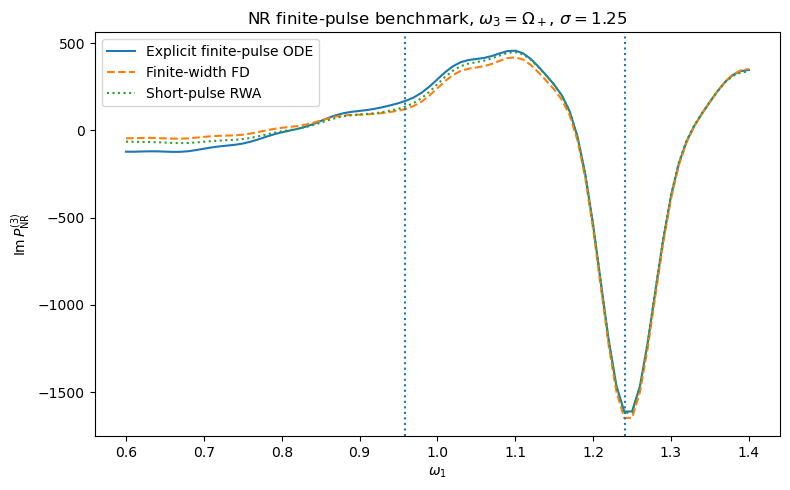

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega1_nr_scan,
    np.imag(P_NR_ODE_cut),
    label="Explicit finite-pulse ODE",
)

plt.plot(
    omega1_nr_scan,
    np.imag(P_NR_finite_cut),
    linestyle="--",
    label="Finite-width FD",
)

plt.plot(
    omega1_nr_scan,
    np.imag(P_NR_short_cut),
    linestyle=":",
    label="Short-pulse RWA",
)

plt.axvline(
    Omega_minus,
    linestyle=":",
)

plt.axvline(
    Omega_plus,
    linestyle=":",
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\mathrm{Im}\,P_{\mathrm{NR}}^{(3)}$")

plt.title(
    rf"NR finite-pulse benchmark, "
    rf"$\omega_3=\Omega_+$, "
    rf"$\sigma={sigma_ode}$"
)

plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Diagnostic A: detection after completion of pulse 3

The first ODE comparison used a detection-time grid beginning at

$$
t_3=0,
$$

where \(t_3\) was measured from the center of pulse 3.

At \(t_3=0\), however, only half of the third Gaussian pulse has occurred.
The explicit ODE therefore contains only the portion of pulse 3 preceding the
detection time.

By contrast, the analytical operator

$$
F_3^{(s_3)}
=
\int_{-\infty}^{\infty}
du_3\,
e^{i\omega_3u_3}
E_3^{(s_3)}(u_3)
e^{\mathcal{L}u_3}
$$

contains the complete pulse-3 integration.

We therefore perform a second diagnostic calculation without changing the
previous benchmark. The new detection window begins six pulse widths after
the center of pulse 3,

$$
t_{3,\min}=6\sigma,
$$

so that pulse 3 is essentially complete before detection begins.

The original calculation is retained above for comparison.

In [64]:
# ------------------------------------------------------------
# Diagnostic A:
# detection begins after pulse 3 is complete
# ------------------------------------------------------------

t3_min_post = 6.0 * sigma_ode
t3_max_post = 80.0
dt3_post = 0.5

t3_post = np.arange(
    t3_min_post,
    t3_max_post + 0.5 * dt3_post,
    dt3_post,
)

print("Original detection window")
print("-------------------------")
print("t3_min =", t3_ode[0])
print("t3_max =", t3_ode[-1])
print("points =", len(t3_ode))

print()

print("Post-pulse detection window")
print("---------------------------")
print("t3_min =", t3_post[0])
print("t3_max =", t3_post[-1])
print("t3_min / sigma =", t3_post[0] / sigma_ode)
print("points =", len(t3_post))

Original detection window
-------------------------
t3_min = 0.0
t3_max = 80.0
points = 161

Post-pulse detection window
---------------------------
t3_min = 7.5
t3_max = 80.0
t3_min / sigma = 6.0
points = 146


In [65]:
# ------------------------------------------------------------
# NR ODE with detection only after pulse 3
# ------------------------------------------------------------

P_NR_ODE_td_post = ode_time_domain_grid(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_ode,
    T=T_scan,
    t1_axis=t1_ode,
    t3_axis=t3_post,
)

print()
print("Post-pulse NR ODE grid complete.")
print("Shape =", P_NR_ODE_td_post.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_NR_ODE_td_post)),
)

t1 1/146
t1 21/146
t1 41/146
t1 61/146
t1 81/146
t1 101/146
t1 121/146
t1 141/146

Post-pulse NR ODE grid complete.
Shape = (146, 146)
All finite = True


In [66]:
# ------------------------------------------------------------
# Transform the post-pulse ODE result
# ------------------------------------------------------------

omega3_cut_post = Omega_plus

kernel3_post = np.exp(
    (
        1j * omega3_cut_post
        - eta_ode
    )
    * t3_post
)

P_NR_ODE_t1_post = np.trapezoid(
    kernel3_post[:, None]
    * P_NR_ODE_td_post,
    x=t3_post,
    axis=0,
)


P_NR_ODE_cut_post = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    kernel1 = np.exp(
        (
            1j * omega1
            - eta_ode
        )
        * t1_ode
    )

    P_NR_ODE_cut_post[i] = np.trapezoid(
        kernel1 * P_NR_ODE_t1_post,
        x=t1_ode,
    )

print(
    "Post-pulse ODE cut all finite =",
    np.all(np.isfinite(P_NR_ODE_cut_post)),
)

Post-pulse ODE cut all finite = True


In [67]:
# ------------------------------------------------------------
# Finite-width FD using the post-pulse detection window
# ------------------------------------------------------------

P_NR_finite_cut_post = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

F3_cut_post = F3(
    omega3_cut_post,
    +1,
    sigma_ode,
    omega_L3,
    L,
    I_L,
    E0,
    Phi_3,
)

for i, omega1 in enumerate(omega1_nr_scan):

    F1_op = F1(
        omega1,
        +1,
        sigma_ode,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        omega1,
        -1,
        sigma_ode,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    x = F1_op @ rho_ss_vec
    x = V @ x

    x = apply_G_interval(
        omega1,
        x,
        eta_ode,
        t1_ode[0],
        t1_ode[-1],
    )

    x = V @ x
    x = F2_op @ x
    x = F3_cut_post @ x
    x = prop_T_scan @ x
    x = V @ x

    x = apply_G_interval(
        omega3_cut_post,
        x,
        eta_ode,
        t3_post[0],
        t3_post[-1],
    )

    P_NR_finite_cut_post[i] = mu_bra @ x

In [68]:
# ------------------------------------------------------------
# Short-pulse RWA using the post-pulse detection window
# ------------------------------------------------------------

P_NR_short_cut_post = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

E3_cut_post = gaussian_spectrum(
    omega3_cut_post,
    +1,
    sigma_ode,
    omega_L3,
    E0,
    Phi_3,
)

for i, omega1 in enumerate(omega1_nr_scan):

    x = V_up @ rho_ss_vec

    x = apply_G_interval(
        omega1,
        x,
        eta_ode,
        t1_ode[0],
        t1_ode[-1],
    )

    x = V_down @ x
    x = prop_T_scan @ x
    x = V_up @ x

    x = apply_G_interval(
        omega3_cut_post,
        x,
        eta_ode,
        t3_post[0],
        t3_post[-1],
    )

    M_cut_post = mu_bra @ x

    E1 = gaussian_spectrum(
        omega1,
        +1,
        sigma_ode,
        omega_L1,
        E0,
        Phi_1,
    )

    E2 = gaussian_spectrum(
        -omega1,
        -1,
        sigma_ode,
        omega_L2,
        E0,
        Phi_2,
    )

    P_NR_short_cut_post[i] = (
        E3_cut_post
        * E2
        * E1
        * M_cut_post
    )

In [69]:
# ------------------------------------------------------------
# Diagnostic comparison: original vs post-pulse detection
# ------------------------------------------------------------

err_finite_ODE_NR_post = (
    np.linalg.norm(
        P_NR_finite_cut_post
        - P_NR_ODE_cut_post
    )
    / np.linalg.norm(P_NR_ODE_cut_post)
)

err_short_ODE_NR_post = (
    np.linalg.norm(
        P_NR_short_cut_post
        - P_NR_ODE_cut_post
    )
    / np.linalg.norm(P_NR_ODE_cut_post)
)

print("ORIGINAL BENCHMARK")
print("------------------")
print(
    "Finite-width FD vs ODE =",
    err_finite_ODE_NR,
)
print(
    "Short-pulse RWA vs ODE =",
    err_short_ODE_NR,
)

print()

print("POST-PULSE DETECTION BENCHMARK")
print("------------------------------")
print(
    "Finite-width FD vs ODE =",
    err_finite_ODE_NR_post,
)
print(
    "Short-pulse RWA vs ODE =",
    err_short_ODE_NR_post,
)

ORIGINAL BENCHMARK
------------------
Finite-width FD vs ODE = 0.08342210757707105
Short-pulse RWA vs ODE = 0.048958225496200415

POST-PULSE DETECTION BENCHMARK
------------------------------
Finite-width FD vs ODE = 0.08206312763486903
Short-pulse RWA vs ODE = 0.052208508629166504


In [70]:
def comparison_diagnostics(model, reference):

    raw_error = (
        np.linalg.norm(model - reference)
        / np.linalg.norm(reference)
    )

    alpha = (
        np.vdot(model, reference)
        / np.vdot(model, model)
    )

    shape_error = (
        np.linalg.norm(
            reference - alpha * model
        )
        / np.linalg.norm(reference)
    )

    return raw_error, alpha, shape_error


raw_fin_post, alpha_fin_post, shape_fin_post = (
    comparison_diagnostics(
        P_NR_finite_cut_post,
        P_NR_ODE_cut_post,
    )
)

raw_short_post, alpha_short_post, shape_short_post = (
    comparison_diagnostics(
        P_NR_short_cut_post,
        P_NR_ODE_cut_post,
    )
)

print("Finite-width FD")
print("----------------")
print("raw error   =", raw_fin_post)
print("alpha       =", alpha_fin_post)
print("shape error =", shape_fin_post)

print()

print("Short-pulse RWA")
print("----------------")
print("raw error   =", raw_short_post)
print("alpha       =", alpha_short_post)
print("shape error =", shape_short_post)

Finite-width FD
----------------
raw error   = 0.08206312763486903
alpha       = (1.0038936841654234+0.0010729984871332824j)
shape error = 0.08196511370413706

Short-pulse RWA
----------------
raw error   = 0.052208508629166504
alpha       = (1.019215471667286+0.001299162103287058j)
shape error = 0.048677583654463764


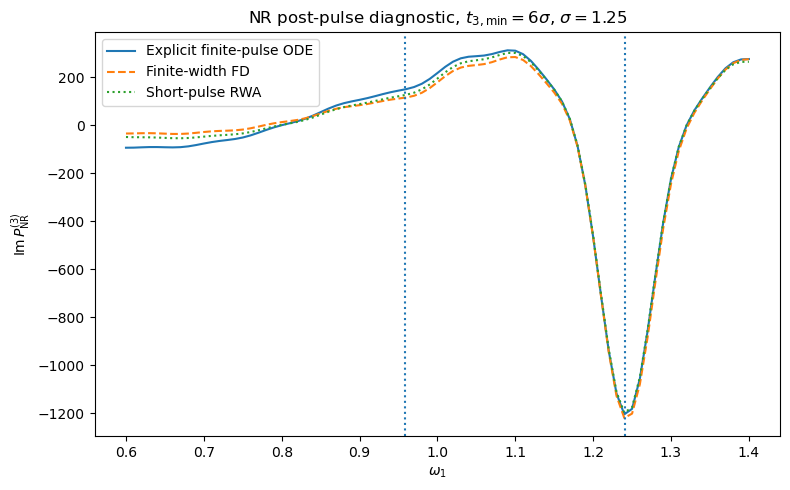

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega1_nr_scan,
    np.imag(P_NR_ODE_cut_post),
    label="Explicit finite-pulse ODE",
)

plt.plot(
    omega1_nr_scan,
    np.imag(P_NR_finite_cut_post),
    linestyle="--",
    label="Finite-width FD",
)

plt.plot(
    omega1_nr_scan,
    np.imag(P_NR_short_cut_post),
    linestyle=":",
    label="Short-pulse RWA",
)

plt.axvline(Omega_minus, linestyle=":")
plt.axvline(Omega_plus, linestyle=":")

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\mathrm{Im}\,P_{\mathrm{NR}}^{(3)}$")

plt.title(
    rf"NR post-pulse diagnostic, "
    rf"$t_{{3,\min}}=6\sigma$, "
    rf"$\sigma={sigma_ode}$"
)

plt.legend()
plt.tight_layout()
plt.show()

### 6.4 Full two-dimensional ODE comparison

The previous comparison examined a one-dimensional cut at

$$
\omega_3=\Omega_+.
$$

A one-dimensional cut does not necessarily represent the global error over the
complete two-dimensional spectrum.

We therefore transform the already calculated explicit finite-pulse ODE response

$$
P_{\mathrm{ODE}}^{(3)}(t_3,T,t_1)
$$

over both coherence-time axes and compare the complete complex two-dimensional
spectrum with

1. the finite-width full-\(V\) frequency-domain result, and
2. the short-pulse RWA result.

No additional ODE propagation is required for this test.

In [72]:
# ------------------------------------------------------------
# Full 2D transform of the existing post-pulse ODE grid
# ------------------------------------------------------------

K1_NR = np.exp(
    (
        1j * omega1_nr_scan[:, None]
        - eta_ode
    )
    * t1_ode[None, :]
)

K3_NR = np.exp(
    (
        1j * omega3_scan[:, None]
        - eta_ode
    )
    * t3_post[None, :]
)

# First integrate over t1
P_NR_ODE_after_t1 = np.trapezoid(
    K1_NR[None, :, :]
    * P_NR_ODE_td_post[:, None, :],
    x=t1_ode,
    axis=2,
)

# Shape:
# (Nt3, Nomega1)

# Then integrate over t3
P_NR_ODE_2D_post = np.trapezoid(
    K3_NR[:, :, None]
    * P_NR_ODE_after_t1[None, :, :],
    x=t3_post,
    axis=1,
)

print("ODE 2D shape =", P_NR_ODE_2D_post.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_NR_ODE_2D_post)),
)

ODE 2D shape = (81, 81)
All finite = True


In [73]:
# ------------------------------------------------------------
# Full 2D finite-width FD using the same t1 and t3 windows
# ------------------------------------------------------------

source_NR_finite_post = np.zeros(
    (d**2, len(omega1_nr_scan)),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    F1_op = F1(
        omega1,
        +1,
        sigma_ode,
        omega_L1,
        L,
        I_L,
        E0,
        Phi_1,
    )

    F2_op = F2(
        omega1,
        -1,
        sigma_ode,
        omega_L2,
        L,
        I_L,
        E0,
        Phi_2,
    )

    x = F1_op @ rho_ss_vec
    x = V @ x

    x = apply_G_interval(
        omega1,
        x,
        eta_ode,
        t1_ode[0],
        t1_ode[-1],
    )

    x = V @ x
    x = F2_op @ x

    source_NR_finite_post[:, i] = x


P_NR_finite_2D_post = np.zeros(
    (
        len(omega3_scan),
        len(omega1_nr_scan),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_scan):

    F3_op = F3(
        omega3,
        +1,
        sigma_ode,
        omega_L3,
        L,
        I_L,
        E0,
        Phi_3,
    )

    X = F3_op @ source_NR_finite_post
    X = prop_T_scan @ X
    X = V @ X

    X = apply_G_interval(
        omega3,
        X,
        eta_ode,
        t3_post[0],
        t3_post[-1],
    )

    P_NR_finite_2D_post[j, :] = mu_bra @ X

In [74]:
# ------------------------------------------------------------
# Full 2D short-pulse RWA using the same windows
# ------------------------------------------------------------

source_NR_short_post = np.zeros(
    (d**2, len(omega1_nr_scan)),
    dtype=complex,
)

E1_NR_post = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

E2_NR_post = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    x = V_up @ rho_ss_vec

    x = apply_G_interval(
        omega1,
        x,
        eta_ode,
        t1_ode[0],
        t1_ode[-1],
    )

    x = V_down @ x
    x = prop_T_scan @ x
    x = V_up @ x

    source_NR_short_post[:, i] = x

    E1_NR_post[i] = gaussian_spectrum(
        omega1,
        +1,
        sigma_ode,
        omega_L1,
        E0,
        Phi_1,
    )

    E2_NR_post[i] = gaussian_spectrum(
        -omega1,
        -1,
        sigma_ode,
        omega_L2,
        E0,
        Phi_2,
    )


P_NR_short_2D_post = np.zeros(
    (
        len(omega3_scan),
        len(omega1_nr_scan),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_scan):

    X = apply_G_interval(
        omega3,
        source_NR_short_post,
        eta_ode,
        t3_post[0],
        t3_post[-1],
    )

    M_row = mu_bra @ X

    E3 = gaussian_spectrum(
        omega3,
        +1,
        sigma_ode,
        omega_L3,
        E0,
        Phi_3,
    )

    P_NR_short_2D_post[j, :] = (
        E3
        * E2_NR_post
        * E1_NR_post
        * M_row
    )

In [75]:
# ------------------------------------------------------------
# Full complex 2D errors against explicit ODE
# ------------------------------------------------------------

err_NR_finite_ODE_2D = (
    np.linalg.norm(
        P_NR_finite_2D_post
        - P_NR_ODE_2D_post
    )
    / np.linalg.norm(P_NR_ODE_2D_post)
)

err_NR_short_ODE_2D = (
    np.linalg.norm(
        P_NR_short_2D_post
        - P_NR_ODE_2D_post
    )
    / np.linalg.norm(P_NR_ODE_2D_post)
)

print("FULL 2D NR BENCHMARK")
print("--------------------")
print(
    "Finite-width FD vs ODE =",
    err_NR_finite_ODE_2D,
)
print(
    "Short-pulse RWA vs ODE =",
    err_NR_short_ODE_2D,
)

FULL 2D NR BENCHMARK
--------------------
Finite-width FD vs ODE = 0.09139662549174427
Short-pulse RWA vs ODE = 0.06633959925825847


In [76]:
raw_fin_2D, alpha_fin_2D, shape_fin_2D = (
    comparison_diagnostics(
        P_NR_finite_2D_post,
        P_NR_ODE_2D_post,
    )
)

raw_short_2D, alpha_short_2D, shape_short_2D = (
    comparison_diagnostics(
        P_NR_short_2D_post,
        P_NR_ODE_2D_post,
    )
)

print()
print("Finite-width FD")
print("----------------")
print("raw error   =", raw_fin_2D)
print("alpha       =", alpha_fin_2D)
print("shape error =", shape_fin_2D)

print()

print("Short-pulse RWA")
print("----------------")
print("raw error   =", raw_short_2D)
print("alpha       =", alpha_short_2D)
print("shape error =", shape_short_2D)


Finite-width FD
----------------
raw error   = 0.09139662549174427
alpha       = (1.0001805552786387-0.008509192724544831j)
shape error = 0.09100294076756076

Short-pulse RWA
----------------
raw error   = 0.06633959925825847
alpha       = (1.031204818043691-0.0016588051163329044j)
shape error = 0.05904115273725297


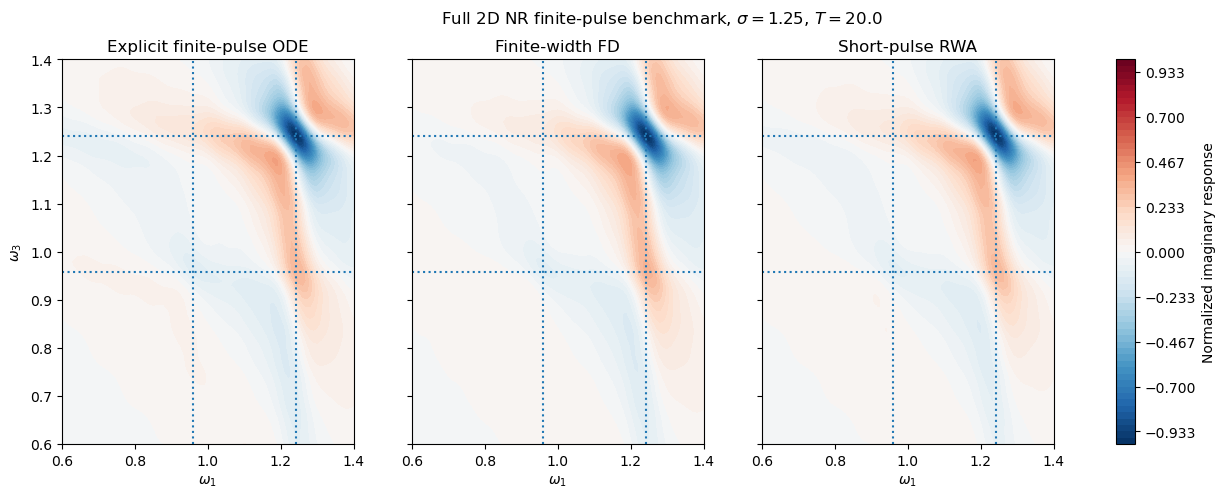

In [77]:
# ------------------------------------------------------------
# Full 2D ODE / finite-FD / short-RWA comparison
# ------------------------------------------------------------

def normalized_imag(Z):
    Z_im = np.imag(Z)
    return Z_im / np.max(np.abs(Z_im))


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

datasets = [
    normalized_imag(P_NR_ODE_2D_post),
    normalized_imag(P_NR_finite_2D_post),
    normalized_imag(P_NR_short_2D_post),
]

titles = [
    "Explicit finite-pulse ODE",
    "Finite-width FD",
    "Short-pulse RWA",
]

for ax, data, title in zip(
    axes,
    datasets,
    titles,
):

    contour = ax.contourf(
        omega1_nr_scan,
        omega3_scan,
        data,
        levels=np.linspace(-1, 1, 61),
        vmin=-1,
        vmax=1,
        cmap="RdBu_r",
    )

    ax.axvline(Omega_minus, linestyle=":")
    ax.axvline(Omega_plus, linestyle=":")
    ax.axhline(Omega_minus, linestyle=":")
    ax.axhline(Omega_plus, linestyle=":")

    ax.set_xlabel(r"$\omega_1$")
    ax.set_title(title)

axes[0].set_ylabel(r"$\omega_3$")

fig.colorbar(
    contour,
    ax=axes,
    label="Normalized imaginary response",
)

fig.suptitle(
    rf"Full 2D NR finite-pulse benchmark, "
    rf"$\sigma={sigma_ode}$, $T={T_scan}$"
)

plt.show()

### 6.5 Diagnostic B: transform convention consistent with the \(F_1F_2F_3\) derivation

The previous ODE comparisons used truncated positive pulse-center delay windows and
attempted to reproduce those windows by replacing the resolvents with truncated
propagator integrals.

For finite-width pulses this is not equivalent to the derivation of the analytical
\(F_j\) expression.

If the interaction times are written as

$$
t_j = \tau_j + u_j,
$$

then the actual first coherence interval is

$$
t_1^{\mathrm{actual}}
=
(\tau_2-\tau_1)+u_2-u_1,
$$

and the actual detection interval after the third interaction is

$$
t_3^{\mathrm{actual}}
=
(t-\tau_3)-u_3.
$$

Changing variables in the Fourier transforms generates the pulse-offset factors

$$
e^{+i\omega_1u_1},
\qquad
e^{-i\omega_1u_2},
\qquad
e^{+i\omega_3u_3},
$$

which are precisely the factors appearing in the definitions of
\(F_1\), \(F_2\), and \(F_3\).

We therefore perform a new ODE benchmark in which the pulse-center delay and
detection axes extend sufficiently far to negative and positive values that the
causal signal itself determines the effective integration domain.

This benchmark also incorporates the finite numerical Fourier broadening
\(\eta\) consistently into the analytical pulse operators.

In [78]:
# ------------------------------------------------------------
# Finite-eta pulse operators for numerical ODE comparison only
# ------------------------------------------------------------

def F1_eta(
    omega1,
    s,
    sigma,
    omega_L,
    eta_value,
    L=L,
    I_L=I_L,
    E0=1.0,
    Phi=0.0,
):
    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    A = (
        L
        - eta_value * I_L
        + 1j * (omega1 - s * omega_L) * I_L
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


def F2_eta(
    omega1,
    s,
    sigma,
    omega_L,
    eta_value,
    L=L,
    I_L=I_L,
    E0=1.0,
    Phi=0.0,
):
    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    A = (
        L
        - eta_value * I_L
        + 1j * (omega1 + s * omega_L) * I_L
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )


def F3_eta(
    omega3,
    s,
    sigma,
    omega_L,
    eta_value,
    L=L,
    I_L=I_L,
    E0=1.0,
    Phi=0.0,
):
    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    A = (
        L
        - eta_value * I_L
        + 1j * (omega3 - s * omega_L) * I_L
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * expm(0.5 * sigma**2 * (A @ A))
    )

In [79]:
def gaussian_spectrum_eta(
    detuning,
    sigma,
    E0=1.0,
    phase_factor=1.0,
    eta_value=0.02,
):
    """
    Gaussian integral with finite numerical Fourier damping.
    """

    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    z = (
        -eta_value
        + 1j * detuning
    )

    return (
        C
        * phase_factor
        * np.exp(
            0.5 * sigma**2 * z**2
        )
    )

In [80]:
# ------------------------------------------------------------
# Diagnostic-B time axes
# ------------------------------------------------------------

sigma_bilat = 1.25
eta_bilat = 0.02
T_bilat = 20.0

dt_bilat = 0.5

t1_bilat = np.arange(
    -8.0 * sigma_bilat,
    80.0 + 0.5 * dt_bilat,
    dt_bilat,
)

t3_bilat = np.arange(
    -8.0 * sigma_bilat,
    80.0 + 0.5 * dt_bilat,
    dt_bilat,
)

print("t1 range =", t1_bilat[0], "to", t1_bilat[-1])
print("t3 range =", t3_bilat[0], "to", t3_bilat[-1])
print("t1 points =", len(t1_bilat))
print("t3 points =", len(t3_bilat))

t1 range = -10.0 to 80.0
t3 range = -10.0 to 80.0
t1 points = 181
t3 points = 181


In [81]:
# ------------------------------------------------------------
# NR ODE on the transform domain corresponding to Eq. 122
# ------------------------------------------------------------

P_NR_ODE_td_bilat = ode_time_domain_grid(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_bilat,
    t3_axis=t3_bilat,
)

print()
print("Bilateral-like NR ODE grid complete.")
print("Shape =", P_NR_ODE_td_bilat.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_NR_ODE_td_bilat)),
)

t1 1/181
t1 21/181
t1 41/181
t1 61/181
t1 81/181
t1 101/181
t1 121/181
t1 141/181
t1 161/181
t1 181/181

Bilateral-like NR ODE grid complete.
Shape = (181, 181)
All finite = True


In [82]:
# ------------------------------------------------------------
# Full 2D transform
# ------------------------------------------------------------

K1_bilat = np.exp(
    (
        1j * omega1_nr_scan[:, None]
        - eta_bilat
    )
    * t1_bilat[None, :]
)

K3_bilat = np.exp(
    (
        1j * omega3_scan[:, None]
        - eta_bilat
    )
    * t3_bilat[None, :]
)


P_NR_ODE_after_t1_bilat = np.trapezoid(
    K1_bilat[None, :, :]
    * P_NR_ODE_td_bilat[:, None, :],
    x=t1_bilat,
    axis=2,
)


P_NR_ODE_2D_bilat = np.trapezoid(
    K3_bilat[:, :, None]
    * P_NR_ODE_after_t1_bilat[None, :, :],
    x=t3_bilat,
    axis=1,
)


print("ODE 2D shape =", P_NR_ODE_2D_bilat.shape)

ODE 2D shape = (81, 81)


In [83]:
# ------------------------------------------------------------
# Finite-width FD consistent with the damped ODE transform
# ------------------------------------------------------------

source_NR_FD_bilat = np.zeros(
    (d**2, len(omega1_nr_scan)),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    F1_op = F1_eta(
        omega1,
        +1,
        sigma_bilat,
        omega_L1,
        eta_bilat,
        E0=E0,
        Phi=Phi_1,
    )

    F2_op = F2_eta(
        omega1,
        -1,
        sigma_bilat,
        omega_L2,
        eta_bilat,
        E0=E0,
        Phi=Phi_2,
    )

    x = F1_op @ rho_ss_vec
    x = V @ x

    x = apply_G_eta(
        omega1,
        x,
        eta_bilat,
    )

    x = V @ x
    x = F2_op @ x

    source_NR_FD_bilat[:, i] = x


P_NR_FD_2D_bilat = np.zeros(
    (
        len(omega3_scan),
        len(omega1_nr_scan),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_scan):

    F3_op = F3_eta(
        omega3,
        +1,
        sigma_bilat,
        omega_L3,
        eta_bilat,
        E0=E0,
        Phi=Phi_3,
    )

    X = F3_op @ source_NR_FD_bilat
    X = prop_T_scan @ X
    X = V @ X

    X = apply_G_eta(
        omega3,
        X,
        eta_bilat,
    )

    P_NR_FD_2D_bilat[j, :] = (
        mu_bra @ X
    )

In [84]:
err_NR_FD_ODE_bilat = (
    np.linalg.norm(
        P_NR_FD_2D_bilat
        - P_NR_ODE_2D_bilat
    )
    / np.linalg.norm(
        P_NR_ODE_2D_bilat
    )
)

raw_bilat, alpha_bilat, shape_bilat = (
    comparison_diagnostics(
        P_NR_FD_2D_bilat,
        P_NR_ODE_2D_bilat,
    )
)

print("CONSISTENT-TRANSFORM NR TEST")
print("----------------------------")
print("Finite-width FD vs ODE =", err_NR_FD_ODE_bilat)
print("alpha                  =", alpha_bilat)
print("shape error            =", shape_bilat)

CONSISTENT-TRANSFORM NR TEST
----------------------------
Finite-width FD vs ODE = 0.02907268135894981
alpha                  = (0.9989245105338258+0.0002703142920791631j)
shape error            = 0.029051496429213577


### 6.6 Consistent-transform comparison with the short-pulse RWA

The consistent-transform benchmark reduced the full-\(V\) finite-width
frequency-domain discrepancy with the explicit finite-pulse ODE to approximately
\(3\%\).

We now evaluate the short-pulse RWA polarization using exactly the same
finite-\(\eta\) Fourier convention.

This provides the direct comparison

$$
P_{\mathrm{ODE}}^{(3)}
\quad\text{vs.}\quad
P_{\mathrm{finite}}^{(3)}
\quad\text{vs.}\quad
P_{\mathrm{short,RWA}}^{(3)}.
$$

The finite-width calculation retains the complete interaction \(V\), whereas
the short-pulse calculation explicitly imposes the RWA through
\(V_{\uparrow}\) and \(V_{\downarrow}\).

In [85]:
# ------------------------------------------------------------
# Scalar Gaussian factors consistent with finite eta
# ------------------------------------------------------------

def E1_eta(
    omega1,
    s,
    sigma,
    omega_L,
    eta_value,
    E0=1.0,
    Phi=0.0,
):
    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    z = (
        -eta_value
        + 1j * (omega1 - s * omega_L)
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * np.exp(0.5 * sigma**2 * z**2)
    )


def E2_eta(
    omega1,
    s,
    sigma,
    omega_L,
    eta_value,
    E0=1.0,
    Phi=0.0,
):
    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    z = (
        -eta_value
        + 1j * (omega1 + s * omega_L)
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * np.exp(0.5 * sigma**2 * z**2)
    )


def E3_eta(
    omega3,
    s,
    sigma,
    omega_L,
    eta_value,
    E0=1.0,
    Phi=0.0,
):
    C = 0.5 * E0 * np.sqrt(2.0 * np.pi) * sigma

    z = (
        -eta_value
        + 1j * (omega3 - s * omega_L)
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * np.exp(0.5 * sigma**2 * z**2)
    )

In [86]:
# ------------------------------------------------------------
# Short-pulse RWA under the same consistent transform
#
# NR signature: (+, -, +)
# ------------------------------------------------------------

source_NR_short_bilat = np.zeros(
    (d**2, len(omega1_nr_scan)),
    dtype=complex,
)

pulse12_NR_bilat = np.zeros(
    len(omega1_nr_scan),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    x = V_up @ rho_ss_vec

    x = apply_G_eta(
        omega1,
        x,
        eta_bilat,
    )

    x = V_down @ x
    x = prop_T_scan @ x
    x = V_up @ x

    source_NR_short_bilat[:, i] = x

    E1_value = E1_eta(
        omega1,
        +1,
        sigma_bilat,
        omega_L1,
        eta_bilat,
        E0,
        Phi_1,
    )

    E2_value = E2_eta(
        omega1,
        -1,
        sigma_bilat,
        omega_L2,
        eta_bilat,
        E0,
        Phi_2,
    )

    pulse12_NR_bilat[i] = (
        E1_value * E2_value
    )


P_NR_short_2D_bilat = np.zeros(
    (
        len(omega3_scan),
        len(omega1_nr_scan),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_scan):

    X = apply_G_eta(
        omega3,
        source_NR_short_bilat,
        eta_bilat,
    )

    M_row = mu_bra @ X

    E3_value = E3_eta(
        omega3,
        +1,
        sigma_bilat,
        omega_L3,
        eta_bilat,
        E0,
        Phi_3,
    )

    P_NR_short_2D_bilat[j, :] = (
        E3_value
        * pulse12_NR_bilat
        * M_row
    )

In [87]:
# ------------------------------------------------------------
# Consistent-transform errors
# ------------------------------------------------------------

err_NR_finite_consistent = (
    np.linalg.norm(
        P_NR_FD_2D_bilat
        - P_NR_ODE_2D_bilat
    )
    / np.linalg.norm(P_NR_ODE_2D_bilat)
)

err_NR_short_consistent = (
    np.linalg.norm(
        P_NR_short_2D_bilat
        - P_NR_ODE_2D_bilat
    )
    / np.linalg.norm(P_NR_ODE_2D_bilat)
)


raw_fin_cons, alpha_fin_cons, shape_fin_cons = (
    comparison_diagnostics(
        P_NR_FD_2D_bilat,
        P_NR_ODE_2D_bilat,
    )
)

raw_short_cons, alpha_short_cons, shape_short_cons = (
    comparison_diagnostics(
        P_NR_short_2D_bilat,
        P_NR_ODE_2D_bilat,
    )
)


print("CONSISTENT-TRANSFORM FULL 2D NR BENCHMARK")
print("-----------------------------------------")

print()
print("Finite-width FD")
print("----------------")
print("raw error   =", raw_fin_cons)
print("alpha       =", alpha_fin_cons)
print("shape error =", shape_fin_cons)

print()

print("Short-pulse RWA")
print("----------------")
print("raw error   =", raw_short_cons)
print("alpha       =", alpha_short_cons)
print("shape error =", shape_short_cons)

CONSISTENT-TRANSFORM FULL 2D NR BENCHMARK
-----------------------------------------

Finite-width FD
----------------
raw error   = 0.02907268135894981
alpha       = (0.9989245105338258+0.0002703142920791631j)
shape error = 0.029051496429213577

Short-pulse RWA
----------------
raw error   = 0.0634754520848864
alpha       = (1.0093615052739955+0.018488392007722808j)
shape error = 0.060077167999982174


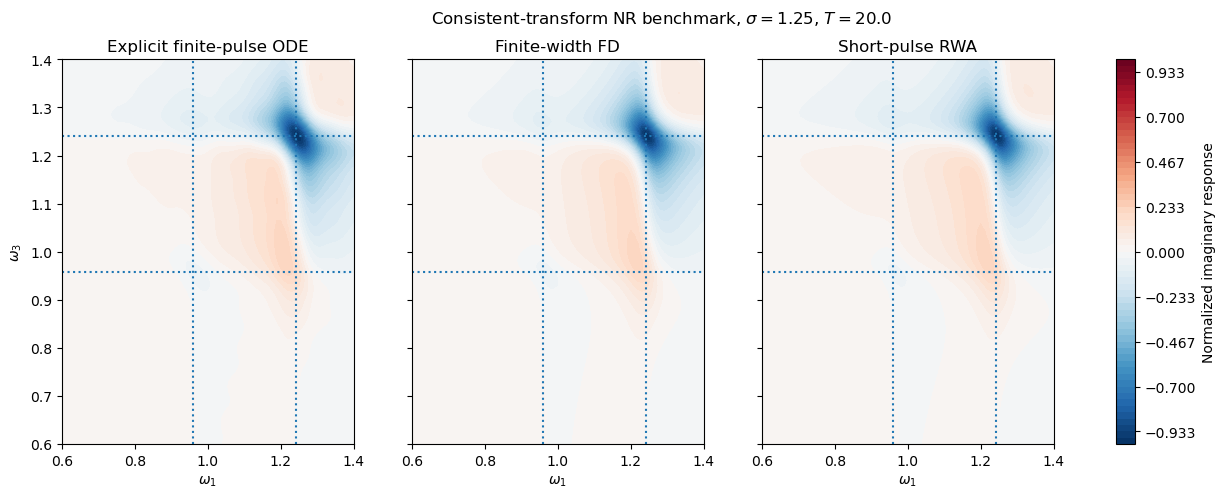

In [88]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

datasets = [
    normalized_imag(P_NR_ODE_2D_bilat),
    normalized_imag(P_NR_FD_2D_bilat),
    normalized_imag(P_NR_short_2D_bilat),
]

titles = [
    "Explicit finite-pulse ODE",
    "Finite-width FD",
    "Short-pulse RWA",
]

for ax, data, title in zip(
    axes,
    datasets,
    titles,
):

    contour = ax.contourf(
        omega1_nr_scan,
        omega3_scan,
        data,
        levels=np.linspace(-1, 1, 61),
        vmin=-1,
        vmax=1,
        cmap="RdBu_r",
    )

    ax.axvline(Omega_minus, linestyle=":")
    ax.axvline(Omega_plus, linestyle=":")

    ax.axhline(Omega_minus, linestyle=":")
    ax.axhline(Omega_plus, linestyle=":")

    ax.set_xlabel(r"$\omega_1$")
    ax.set_title(title)

axes[0].set_ylabel(r"$\omega_3$")

fig.colorbar(
    contour,
    ax=axes,
    label="Normalized imaginary response",
)

fig.suptitle(
    rf"Consistent-transform NR benchmark, "
    rf"$\sigma={sigma_bilat}$, $T={T_bilat}$"
)

plt.show()

### 6.7 Four-level comparison

We now compare four descriptions of the same nonrephasing spectroscopy problem:

1. explicit finite-pulse ODE propagation;
2. finite-width frequency-domain response using \(F_1F_2F_3\) and the full \(V\);
3. short-pulse RWA response using scalar laser spectra;
4. impulsive RWA molecular response.

The impulsive RWA response is the conventional pathway-resolved molecular
response evaluated by methods such as QuDPy. It contains no finite laser
spectral factors.

Because the impulsive molecular response and the finite-pulse polarizations
have different overall amplitude scales, the four spectra are normalized
independently for visual comparison of their spectral structure.

In [89]:
# ------------------------------------------------------------
# Impulsive RWA molecular response
#
# NR sequence:
#     V_up -> G1 -> V_down -> exp(LT) -> V_up -> G3
# ------------------------------------------------------------

M_NR_impulsive_bilat = np.zeros(
    (
        len(omega3_scan),
        len(omega1_nr_scan),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_scan):

    X = apply_G_eta(
        omega3,
        source_NR_short_bilat,
        eta_bilat,
    )

    M_NR_impulsive_bilat[j, :] = mu_bra @ X


print(
    "Impulsive RWA all finite =",
    np.all(np.isfinite(M_NR_impulsive_bilat)),
)

Impulsive RWA all finite = True


In [91]:
# ------------------------------------------------------------
# Impulsive-RWA spectral-shape comparison with ODE
# ------------------------------------------------------------

raw_imp, alpha_imp, shape_imp = comparison_diagnostics(
    M_NR_impulsive_bilat,
    P_NR_ODE_2D_bilat,
)

print("Impulsive RWA vs finite-pulse ODE")
print("----------------------------------")
print("raw error   =", raw_imp)
print("alpha       =", alpha_imp)
print("shape error =", shape_imp)

Impulsive RWA vs finite-pulse ODE
----------------------------------
raw error   = 0.7385909185287869
alpha       = (3.7782779539713465+0.07916432225493134j)
shape error = 0.10016468241942679


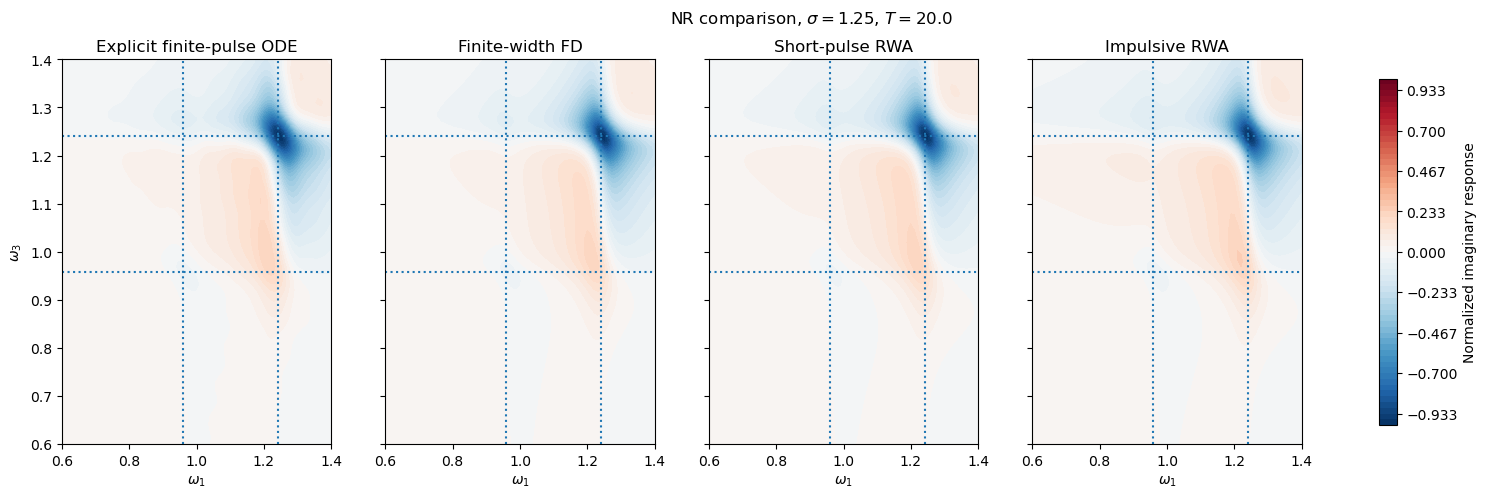

In [90]:
# ------------------------------------------------------------
# Four-level NR comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5),
    sharex=True,
    sharey=True,
)

datasets = [
    normalized_imag(P_NR_ODE_2D_bilat),
    normalized_imag(P_NR_FD_2D_bilat),
    normalized_imag(P_NR_short_2D_bilat),
    normalized_imag(M_NR_impulsive_bilat),
]

titles = [
    "Explicit finite-pulse ODE",
    "Finite-width FD",
    "Short-pulse RWA",
    "Impulsive RWA",
]

for ax, data, title in zip(
    axes,
    datasets,
    titles,
):

    contour = ax.contourf(
        omega1_nr_scan,
        omega3_scan,
        data,
        levels=np.linspace(-1.0, 1.0, 61),
        vmin=-1.0,
        vmax=1.0,
        cmap="RdBu_r",
    )

    ax.axvline(Omega_minus, linestyle=":")
    ax.axvline(Omega_plus, linestyle=":")

    ax.axhline(Omega_minus, linestyle=":")
    ax.axhline(Omega_plus, linestyle=":")

    ax.set_xlabel(r"$\omega_1$")
    ax.set_title(title)

axes[0].set_ylabel(r"$\omega_3$")

fig.colorbar(
    contour,
    ax=axes,
    label="Normalized imaginary response",
    shrink=0.9,
)

fig.suptitle(
    rf"NR comparison, "
    rf"$\sigma={sigma_bilat}$, "
    rf"$T={T_bilat}$"
)

plt.show()

In [92]:
# ------------------------------------------------------------
# Four-model error summary
#
# Reference: explicit finite-pulse ODE
#
# All values below are spectral-shape errors after allowing
# one optimal global complex scaling factor.
# ------------------------------------------------------------

error_ODE = 0.0
error_finite_FD = shape_fin_cons
error_short_RWA = shape_short_cons
error_impulsive_RWA = shape_imp

print("FOUR-MODEL NR ERROR COMPARISON")
print("------------------------------")
print("Reference: explicit finite-pulse ODE")
print()
print(
    f"Explicit finite-pulse ODE : "
    f"{100.0 * error_ODE:8.4f} %"
)
print(
    f"Finite-width FD           : "
    f"{100.0 * error_finite_FD:8.4f} %"
)
print(
    f"Short-pulse RWA           : "
    f"{100.0 * error_short_RWA:8.4f} %"
)
print(
    f"Impulsive RWA             : "
    f"{100.0 * error_impulsive_RWA:8.4f} %"
)

FOUR-MODEL NR ERROR COMPARISON
------------------------------
Reference: explicit finite-pulse ODE

Explicit finite-pulse ODE :   0.0000 %
Finite-width FD           :   2.9051 %
Short-pulse RWA           :   6.0077 %
Impulsive RWA             :  10.0165 %


In [93]:
print()
print("DIRECT COMPLEX ERRORS")
print("---------------------")
print(
    f"Finite-width FD vs ODE : "
    f"{100.0 * err_NR_finite_consistent:8.4f} %"
)
print(
    f"Short-pulse RWA vs ODE : "
    f"{100.0 * err_NR_short_consistent:8.4f} %"
)
print()
print(
    "Impulsive RWA raw error is not directly comparable "
    "because it contains no laser spectral prefactors."
)


DIRECT COMPLEX ERRORS
---------------------
Finite-width FD vs ODE :   2.9073 %
Short-pulse RWA vs ODE :   6.3475 %

Impulsive RWA raw error is not directly comparable because it contains no laser spectral prefactors.


### 6.8 Consistent-transform rephasing benchmark

We now repeat the complete benchmark for the rephasing branch.

The selected field signature is

$$
(s_1,s_2,s_3)=(-,+,+),
$$

and the signed first-coherence frequency satisfies

$$
\nu_1<0.
$$

The four calculations are

1. explicit finite-pulse ODE propagation;
2. finite-width frequency-domain response using \(F_1F_2F_3\) and the full \(V\);
3. short-pulse RWA response;
4. impulsive RWA molecular response.

The ODE and frequency-domain calculations use the same transform convention
and finite numerical broadening parameter.

In [94]:
# ------------------------------------------------------------
# Rephasing ODE
#
# Signature:
#     (-, +, +)
# ------------------------------------------------------------

P_R_ODE_td_bilat = ode_time_domain_grid(
    s1=-1,
    s2=+1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_bilat,
    t3_axis=t3_bilat,
)

print()
print("Rephasing ODE grid complete.")
print("Shape =", P_R_ODE_td_bilat.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_R_ODE_td_bilat)),
)

t1 1/181
t1 21/181
t1 41/181
t1 61/181
t1 81/181
t1 101/181
t1 121/181
t1 141/181
t1 161/181
t1 181/181

Rephasing ODE grid complete.
Shape = (181, 181)
All finite = True


In [95]:
# ------------------------------------------------------------
# Full 2D transform of the rephasing ODE response
# ------------------------------------------------------------

K1_R_bilat = np.exp(
    (
        1j * nu1_r_scan[:, None]
        - eta_bilat
    )
    * t1_bilat[None, :]
)

K3_R_bilat = np.exp(
    (
        1j * omega3_scan[:, None]
        - eta_bilat
    )
    * t3_bilat[None, :]
)


# First transform over t1
P_R_ODE_after_t1_bilat = np.trapezoid(
    K1_R_bilat[None, :, :]
    * P_R_ODE_td_bilat[:, None, :],
    x=t1_bilat,
    axis=2,
)


# Then transform over t3
P_R_ODE_2D_bilat = np.trapezoid(
    K3_R_bilat[:, :, None]
    * P_R_ODE_after_t1_bilat[None, :, :],
    x=t3_bilat,
    axis=1,
)


print("R ODE 2D shape =", P_R_ODE_2D_bilat.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_R_ODE_2D_bilat)),
)

R ODE 2D shape = (81, 81)
All finite = True


In [96]:
# ------------------------------------------------------------
# Finite-width FD rephasing response
#
# Signature:
#     (-, +, +)
# ------------------------------------------------------------

source_R_FD_bilat = np.zeros(
    (d**2, len(nu1_r_scan)),
    dtype=complex,
)


for i, nu1 in enumerate(nu1_r_scan):

    F1_op = F1_eta(
        nu1,
        -1,
        sigma_bilat,
        omega_L1,
        eta_bilat,
        E0=E0,
        Phi=Phi_1,
    )

    F2_op = F2_eta(
        nu1,
        +1,
        sigma_bilat,
        omega_L2,
        eta_bilat,
        E0=E0,
        Phi=Phi_2,
    )

    x = F1_op @ rho_ss_vec
    x = V @ x

    x = apply_G_eta(
        nu1,
        x,
        eta_bilat,
    )

    x = V @ x
    x = F2_op @ x

    source_R_FD_bilat[:, i] = x


P_R_FD_2D_bilat = np.zeros(
    (
        len(omega3_scan),
        len(nu1_r_scan),
    ),
    dtype=complex,
)


for j, omega3 in enumerate(omega3_scan):

    F3_op = F3_eta(
        omega3,
        +1,
        sigma_bilat,
        omega_L3,
        eta_bilat,
        E0=E0,
        Phi=Phi_3,
    )

    X = F3_op @ source_R_FD_bilat
    X = prop_T_scan @ X
    X = V @ X

    X = apply_G_eta(
        omega3,
        X,
        eta_bilat,
    )

    P_R_FD_2D_bilat[j, :] = (
        mu_bra @ X
    )


print(
    "Finite-width R all finite =",
    np.all(np.isfinite(P_R_FD_2D_bilat)),
)

Finite-width R all finite = True


In [97]:
# ------------------------------------------------------------
# Short-pulse and impulsive RWA rephasing responses
# ------------------------------------------------------------

source_R_short_bilat = np.zeros(
    (d**2, len(nu1_r_scan)),
    dtype=complex,
)

pulse12_R_bilat = np.zeros(
    len(nu1_r_scan),
    dtype=complex,
)


for i, nu1 in enumerate(nu1_r_scan):

    # Impulsive RWA molecular sequence
    x = V_down @ rho_ss_vec

    x = apply_G_eta(
        nu1,
        x,
        eta_bilat,
    )

    x = V_up @ x
    x = prop_T_scan @ x
    x = V_up @ x

    source_R_short_bilat[:, i] = x

    # Scalar pulse factors
    E1_value = E1_eta(
        nu1,
        -1,
        sigma_bilat,
        omega_L1,
        eta_bilat,
        E0,
        Phi_1,
    )

    E2_value = E2_eta(
        nu1,
        +1,
        sigma_bilat,
        omega_L2,
        eta_bilat,
        E0,
        Phi_2,
    )

    pulse12_R_bilat[i] = (
        E1_value * E2_value
    )


P_R_short_2D_bilat = np.zeros(
    (
        len(omega3_scan),
        len(nu1_r_scan),
    ),
    dtype=complex,
)

M_R_impulsive_bilat = np.zeros(
    (
        len(omega3_scan),
        len(nu1_r_scan),
    ),
    dtype=complex,
)


for j, omega3 in enumerate(omega3_scan):

    X = apply_G_eta(
        omega3,
        source_R_short_bilat,
        eta_bilat,
    )

    M_row = mu_bra @ X

    # Bare impulsive RWA response
    M_R_impulsive_bilat[j, :] = M_row

    # Pulse-3 scalar factor
    E3_value = E3_eta(
        omega3,
        +1,
        sigma_bilat,
        omega_L3,
        eta_bilat,
        E0,
        Phi_3,
    )

    # Short-pulse RWA polarization
    P_R_short_2D_bilat[j, :] = (
        E3_value
        * pulse12_R_bilat
        * M_row
    )


print(
    "Short R all finite =",
    np.all(np.isfinite(P_R_short_2D_bilat)),
)

print(
    "Impulsive R all finite =",
    np.all(np.isfinite(M_R_impulsive_bilat)),
)

Short R all finite = True
Impulsive R all finite = True


In [98]:
# ------------------------------------------------------------
# Rephasing error diagnostics
# ------------------------------------------------------------

raw_R_fin, alpha_R_fin, shape_R_fin = (
    comparison_diagnostics(
        P_R_FD_2D_bilat,
        P_R_ODE_2D_bilat,
    )
)

raw_R_short, alpha_R_short, shape_R_short = (
    comparison_diagnostics(
        P_R_short_2D_bilat,
        P_R_ODE_2D_bilat,
    )
)

raw_R_imp, alpha_R_imp, shape_R_imp = (
    comparison_diagnostics(
        M_R_impulsive_bilat,
        P_R_ODE_2D_bilat,
    )
)


print("FOUR-MODEL R ERROR COMPARISON")
print("-----------------------------")
print("Reference: explicit finite-pulse ODE")
print()

print(
    f"Explicit finite-pulse ODE : "
    f"{0.0:8.4f} %"
)

print(
    f"Finite-width FD           : "
    f"{100.0 * shape_R_fin:8.4f} %"
)

print(
    f"Short-pulse RWA           : "
    f"{100.0 * shape_R_short:8.4f} %"
)

print(
    f"Impulsive RWA             : "
    f"{100.0 * shape_R_imp:8.4f} %"
)


print()
print("DIRECT COMPLEX ERRORS")
print("---------------------")

print(
    f"Finite-width FD vs ODE : "
    f"{100.0 * raw_R_fin:8.4f} %"
)

print(
    f"Short-pulse RWA vs ODE : "
    f"{100.0 * raw_R_short:8.4f} %"
)


print()
print("GLOBAL COMPLEX SCALE FACTORS")
print("----------------------------")
print("Finite FD alpha =", alpha_R_fin)
print("Short RWA alpha =", alpha_R_short)
print("Impulsive alpha =", alpha_R_imp)

FOUR-MODEL R ERROR COMPARISON
-----------------------------
Reference: explicit finite-pulse ODE

Explicit finite-pulse ODE :   0.0000 %
Finite-width FD           :   2.8259 %
Short-pulse RWA           :   6.2077 %
Impulsive RWA             :  10.2141 %

DIRECT COMPLEX ERRORS
---------------------
Finite-width FD vs ODE :   2.8278 %
Short-pulse RWA vs ODE :   6.7728 %

GLOBAL COMPLEX SCALE FACTORS
----------------------------
Finite FD alpha = (0.998972353611139-4.196222106791394e-05j)
Short RWA alpha = (1.0059338475753783-0.026655134631707968j)
Impulsive alpha = (3.7587097345228244-0.10018763034511036j)


In [99]:
# ------------------------------------------------------------
# Figure output directory
# ------------------------------------------------------------

figure_dir = (
    repo_root
    / "figures"
    / "04_finite_pulse_validation"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print("Figures will be saved to:")
print(figure_dir)

Figures will be saved to:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation


In [100]:
def plot_four_model_comparison(
    x_axis,
    omega3_axis,
    ode_data,
    finite_data,
    short_data,
    impulsive_data,
    x_label,
    branch,
    x_lines,
    sigma,
    T,
    save_stem,
):
    """
    Plot and save the four-model comparison.
    """

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
        sharex=True,
        sharey=True,
    )

    datasets = [
        normalized_imag(ode_data),
        normalized_imag(finite_data),
        normalized_imag(short_data),
        normalized_imag(impulsive_data),
    ]

    titles = [
        "Explicit finite-pulse ODE",
        "Finite-width FD",
        "Short-pulse RWA",
        "Impulsive RWA",
    ]

    for ax, data, title in zip(
        axes,
        datasets,
        titles,
    ):

        contour = ax.contourf(
            x_axis,
            omega3_axis,
            data,
            levels=np.linspace(-1.0, 1.0, 61),
            vmin=-1.0,
            vmax=1.0,
            cmap="RdBu_r",
        )

        for x_line in x_lines:
            ax.axvline(
                x_line,
                linestyle=":",
            )

        ax.axhline(
            Omega_minus,
            linestyle=":",
        )

        ax.axhline(
            Omega_plus,
            linestyle=":",
        )

        ax.set_xlabel(x_label)
        ax.set_title(title)

    axes[0].set_ylabel(r"$\omega_3$")

    fig.colorbar(
        contour,
        ax=axes,
        label="Normalized imaginary response",
        shrink=0.9,
    )

    fig.suptitle(
        rf"{branch} comparison, "
        rf"$\sigma={sigma}$, "
        rf"$T={T}$"
    )

    # --------------------------------------------------------
    # Save both publication and quick-view versions
    # --------------------------------------------------------

    png_path = figure_dir / f"{save_stem}.png"
    pdf_path = figure_dir / f"{save_stem}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved:")
    print(png_path)
    print(pdf_path)

    plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_four_model_sigma1p25_T20.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_four_model_sigma1p25_T20.pdf


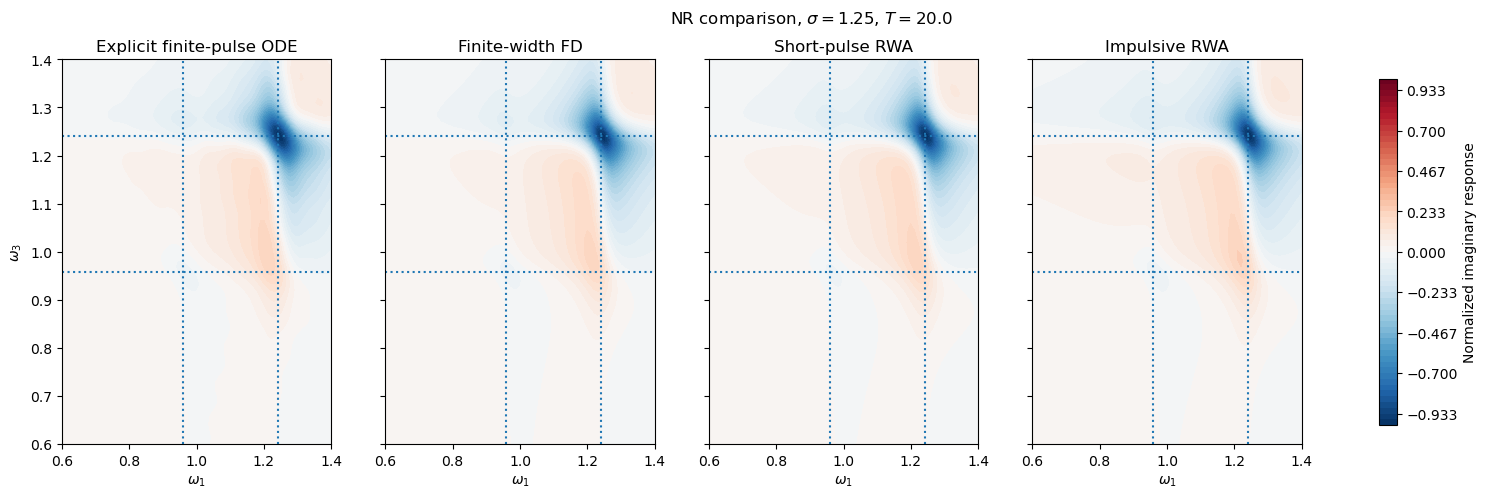

In [101]:
plot_four_model_comparison(
    x_axis=omega1_nr_scan,
    omega3_axis=omega3_scan,
    ode_data=P_NR_ODE_2D_bilat,
    finite_data=P_NR_FD_2D_bilat,
    short_data=P_NR_short_2D_bilat,
    impulsive_data=M_NR_impulsive_bilat,
    x_label=r"$\omega_1$",
    branch="NR",
    x_lines=[
        Omega_minus,
        Omega_plus,
    ],
    sigma=sigma_bilat,
    T=T_bilat,
    save_stem="NR_four_model_sigma1p25_T20",
)

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/R_four_model_sigma1p25_T20.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/R_four_model_sigma1p25_T20.pdf


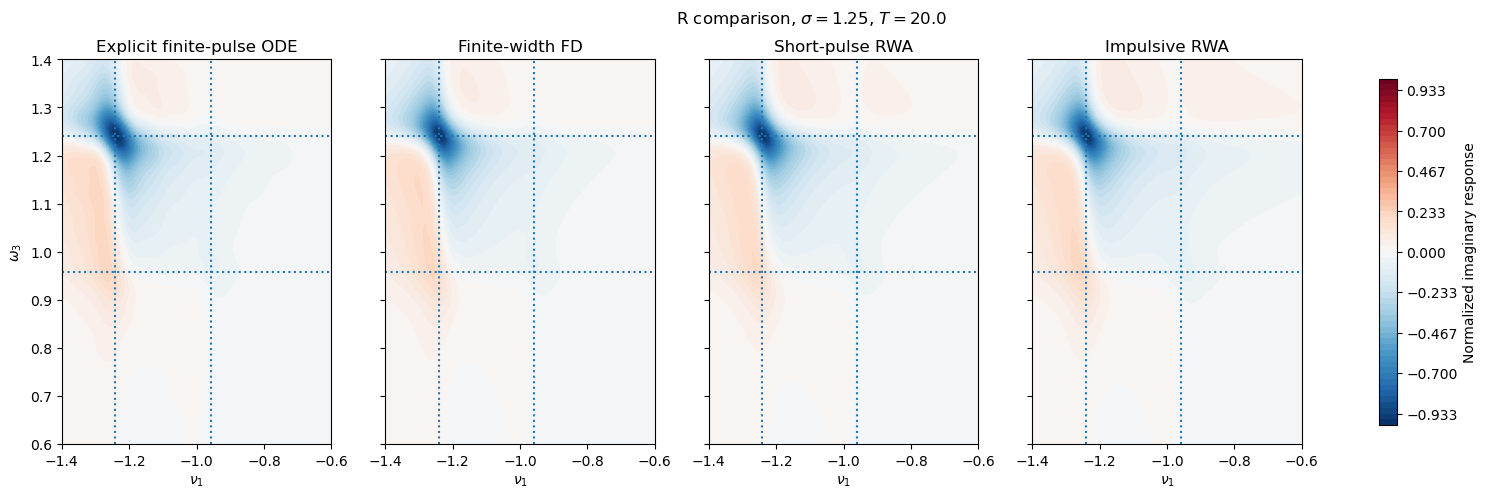

In [102]:
plot_four_model_comparison(
    x_axis=nu1_r_scan,
    omega3_axis=omega3_scan,
    ode_data=P_R_ODE_2D_bilat,
    finite_data=P_R_FD_2D_bilat,
    short_data=P_R_short_2D_bilat,
    impulsive_data=M_R_impulsive_bilat,
    x_label=r"$\nu_1$",
    branch="R",
    x_lines=[
        -Omega_minus,
        -Omega_plus,
    ],
    sigma=sigma_bilat,
    T=T_bilat,
    save_stem="R_four_model_sigma1p25_T20",
)

In [103]:
# ------------------------------------------------------------
# Final four-model summary at sigma = 1.25, T = 20
# ------------------------------------------------------------

print("FINITE-PULSE VALIDATION SUMMARY")
print("================================")
print()
print(f"sigma = {sigma_bilat}")
print(f"T     = {T_bilat}")
print(f"eta   = {eta_bilat}")
print()

print("                    NR error       R error")
print("------------------------------------------------")
print(
    f"Finite-width FD     "
    f"{100.0 * shape_fin_cons:8.4f} %     "
    f"{100.0 * shape_R_fin:8.4f} %"
)
print(
    f"Short-pulse RWA     "
    f"{100.0 * shape_short_cons:8.4f} %     "
    f"{100.0 * shape_R_short:8.4f} %"
)
print(
    f"Impulsive RWA       "
    f"{100.0 * shape_imp:8.4f} %     "
    f"{100.0 * shape_R_imp:8.4f} %"
)

FINITE-PULSE VALIDATION SUMMARY

sigma = 1.25
T     = 20.0
eta   = 0.02

                    NR error       R error
------------------------------------------------
Finite-width FD       2.9051 %       2.8259 %
Short-pulse RWA       6.0077 %       6.2077 %
Impulsive RWA        10.0165 %      10.2141 %


## 7. Convergence of the explicit finite-pulse benchmark

The consistent-transform comparison gives residual finite-width FD errors of
approximately \(2.9\%\) for both the nonrephasing and rephasing branches.

Before interpreting this residual as a limitation of the analytical
finite-width formulation, we test the numerical convergence of the explicit
time-domain benchmark.

Two numerical effects are examined separately:

1. the temporal spacing used in the ODE/Fourier calculation;
2. the maximum coherence-time window.

The analytical frequency-domain result is unchanged during these tests.

If the ODE spectrum converges toward the finite-width frequency-domain result
as the temporal discretization is refined and the propagation window is
extended, the remaining discrepancy can be identified as numerical
time-domain/Fourier error.

In [104]:
def transform_NR_ODE_2D(
    P_td,
    t1_axis,
    t3_axis,
    eta_value,
):
    """
    Transform P(t3,t1) directly onto the existing
    NR frequency grid.
    """

    K1 = np.exp(
        (
            1j * omega1_nr_scan[:, None]
            - eta_value
        )
        * t1_axis[None, :]
    )

    K3 = np.exp(
        (
            1j * omega3_scan[:, None]
            - eta_value
        )
        * t3_axis[None, :]
    )

    after_t1 = np.trapezoid(
        K1[None, :, :]
        * P_td[:, None, :],
        x=t1_axis,
        axis=2,
    )

    P_2D = np.trapezoid(
        K3[:, :, None]
        * after_t1[None, :, :],
        x=t3_axis,
        axis=1,
    )

    return P_2D

In [105]:
# ------------------------------------------------------------
# Convergence test A: finer time spacing
# ------------------------------------------------------------

dt_fine = 0.25
tmax_fine = 80.0

t1_fine = np.arange(
    -8.0 * sigma_bilat,
    tmax_fine + 0.5 * dt_fine,
    dt_fine,
)

t3_fine = np.arange(
    -8.0 * sigma_bilat,
    tmax_fine + 0.5 * dt_fine,
    dt_fine,
)

print("Fine-grid test")
print("--------------")
print("dt =", dt_fine)
print("tmax =", tmax_fine)
print("t1 points =", len(t1_fine))
print("t3 points =", len(t3_fine))

Fine-grid test
--------------
dt = 0.25
tmax = 80.0
t1 points = 361
t3 points = 361


In [106]:
P_NR_ODE_td_fine = ode_time_domain_grid(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_fine,
    t3_axis=t3_fine,
)

t1 1/361
t1 21/361
t1 41/361
t1 61/361
t1 81/361
t1 101/361
t1 121/361
t1 141/361
t1 161/361
t1 181/361
t1 201/361
t1 221/361
t1 241/361
t1 261/361
t1 281/361
t1 301/361
t1 321/361
t1 341/361
t1 361/361


In [107]:
P_NR_ODE_2D_fine = transform_NR_ODE_2D(
    P_td=P_NR_ODE_td_fine,
    t1_axis=t1_fine,
    t3_axis=t3_fine,
    eta_value=eta_bilat,
)

In [108]:
err_NR_FD_fine = (
    np.linalg.norm(
        P_NR_FD_2D_bilat
        - P_NR_ODE_2D_fine
    )
    / np.linalg.norm(P_NR_ODE_2D_fine)
)

_, alpha_NR_FD_fine, shape_NR_FD_fine = (
    comparison_diagnostics(
        P_NR_FD_2D_bilat,
        P_NR_ODE_2D_fine,
    )
)

print("TIMESTEP CONVERGENCE")
print("--------------------")
print(
    f"dt = 0.50 : "
    f"{100.0 * shape_fin_cons:.4f} %"
)
print(
    f"dt = 0.25 : "
    f"{100.0 * shape_NR_FD_fine:.4f} %"
)
print()
print("alpha =", alpha_NR_FD_fine)

TIMESTEP CONVERGENCE
--------------------
dt = 0.50 : 2.9051 %
dt = 0.25 : 2.9056 %

alpha = (0.998924469068654+0.00027038505328191387j)


In [109]:
# ------------------------------------------------------------
# Convergence test B: longer Fourier window
# ------------------------------------------------------------

dt_long = 0.5
tmax_long = 120.0

t1_long = np.arange(
    -8.0 * sigma_bilat,
    tmax_long + 0.5 * dt_long,
    dt_long,
)

t3_long = np.arange(
    -8.0 * sigma_bilat,
    tmax_long + 0.5 * dt_long,
    dt_long,
)

print("Long-window test")
print("----------------")
print("dt =", dt_long)
print("tmax =", tmax_long)
print("t1 points =", len(t1_long))
print("t3 points =", len(t3_long))

Long-window test
----------------
dt = 0.5
tmax = 120.0
t1 points = 261
t3 points = 261


In [110]:
P_NR_ODE_td_long = ode_time_domain_grid(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_long,
    t3_axis=t3_long,
)

t1 1/261
t1 21/261
t1 41/261
t1 61/261
t1 81/261
t1 101/261
t1 121/261
t1 141/261
t1 161/261
t1 181/261
t1 201/261
t1 221/261
t1 241/261
t1 261/261


In [111]:
P_NR_ODE_2D_long = transform_NR_ODE_2D(
    P_td=P_NR_ODE_td_long,
    t1_axis=t1_long,
    t3_axis=t3_long,
    eta_value=eta_bilat,
)

In [112]:
err_NR_FD_long = (
    np.linalg.norm(
        P_NR_FD_2D_bilat
        - P_NR_ODE_2D_long
    )
    / np.linalg.norm(P_NR_ODE_2D_long)
)

_, alpha_NR_FD_long, shape_NR_FD_long = (
    comparison_diagnostics(
        P_NR_FD_2D_bilat,
        P_NR_ODE_2D_long,
    )
)

print("WINDOW CONVERGENCE")
print("------------------")
print(
    f"tmax = 80  : "
    f"{100.0 * shape_fin_cons:.4f} %"
)
print(
    f"tmax = 120 : "
    f"{100.0 * shape_NR_FD_long:.4f} %"
)
print()
print("alpha =", alpha_NR_FD_long)

WINDOW CONVERGENCE
------------------
tmax = 80  : 2.9051 %
tmax = 120 : 0.4144 %

alpha = (0.9999612380963968+2.229110841590578e-05j)


In [113]:
# ------------------------------------------------------------
# Convergence test C: extend the ODE/Fourier window further
# ------------------------------------------------------------

tmax_values_extra = [160.0, 200.0]

shape_NR_window_extra = []
alpha_NR_window_extra = []

for tmax_test in tmax_values_extra:

    dt_test = 0.5

    t1_test = np.arange(
        -8.0 * sigma_bilat,
        tmax_test + 0.5 * dt_test,
        dt_test,
    )

    t3_test = np.arange(
        -8.0 * sigma_bilat,
        tmax_test + 0.5 * dt_test,
        dt_test,
    )

    print()
    print(f"Running tmax = {tmax_test}")

    P_NR_td_test = ode_time_domain_grid(
        s1=+1,
        s2=-1,
        s3=+1,
        sigma=sigma_bilat,
        T=T_bilat,
        t1_axis=t1_test,
        t3_axis=t3_test,
    )

    P_NR_2D_test = transform_NR_ODE_2D(
        P_td=P_NR_td_test,
        t1_axis=t1_test,
        t3_axis=t3_test,
        eta_value=eta_bilat,
    )

    _, alpha_test, shape_test = comparison_diagnostics(
        P_NR_FD_2D_bilat,
        P_NR_2D_test,
    )

    shape_NR_window_extra.append(shape_test)
    alpha_NR_window_extra.append(alpha_test)

    print(
        f"Finite-width FD shape error = "
        f"{100.0 * shape_test:.6f} %"
    )
    print("alpha =", alpha_test)


Running tmax = 160.0
t1 1/341
t1 21/341
t1 41/341
t1 61/341
t1 81/341
t1 101/341
t1 121/341
t1 141/341
t1 161/341
t1 181/341
t1 201/341
t1 221/341
t1 241/341
t1 261/341
t1 281/341
t1 301/341
t1 321/341
t1 341/341
Finite-width FD shape error = 0.058625 %
alpha = (0.9999967510005184+1.7727994080188193e-06j)

Running tmax = 200.0
t1 1/421
t1 21/421
t1 41/421
t1 61/421
t1 81/421
t1 101/421
t1 121/421
t1 141/421
t1 161/421
t1 181/421
t1 201/421
t1 221/421
t1 241/421
t1 261/421
t1 281/421
t1 301/421
t1 321/421
t1 341/421
t1 361/421
t1 381/421
t1 401/421
t1 421/421
Finite-width FD shape error = 0.008326 %
alpha = (0.999999516051636+9.588355520342731e-08j)


In [115]:
print("NR WINDOW CONVERGENCE")
print("---------------------")
print(f"tmax =  80 : {100.0 * shape_fin_cons:.6f} %")
print(f"tmax = 120 : {100.0 * shape_NR_FD_long:.6f} %")

for tmax_test, shape_test in zip(
    tmax_values_extra,
    shape_NR_window_extra,
):
    print(
        f"tmax = {tmax_test:3.0f} : "
        f"{100.0 * shape_test:.6f} %"
    )

NR WINDOW CONVERGENCE
---------------------
tmax =  80 : 2.905150 %
tmax = 120 : 0.414418 %
tmax = 160 : 0.058625 %
tmax = 200 : 0.008326 %


In [116]:
# ------------------------------------------------------------
# Four-model NR comparison using the better-converged ODE
# reference at tmax = 120
# ------------------------------------------------------------

_, _, shape_NR_FD_120 = comparison_diagnostics(
    P_NR_FD_2D_bilat,
    P_NR_ODE_2D_long,
)

_, _, shape_NR_short_120 = comparison_diagnostics(
    P_NR_short_2D_bilat,
    P_NR_ODE_2D_long,
)

_, _, shape_NR_imp_120 = comparison_diagnostics(
    M_NR_impulsive_bilat,
    P_NR_ODE_2D_long,
)

print("FOUR-MODEL NR COMPARISON — tmax = 120")
print("--------------------------------------")
print("Explicit finite-pulse ODE :   0.0000 %")
print(
    f"Finite-width FD           : "
    f"{100.0 * shape_NR_FD_120:8.4f} %"
)
print(
    f"Short-pulse RWA           : "
    f"{100.0 * shape_NR_short_120:8.4f} %"
)
print(
    f"Impulsive RWA             : "
    f"{100.0 * shape_NR_imp_120:8.4f} %"
)

FOUR-MODEL NR COMPARISON — tmax = 120
--------------------------------------
Explicit finite-pulse ODE :   0.0000 %
Finite-width FD           :   0.4144 %
Short-pulse RWA           :   5.2855 %
Impulsive RWA             :   9.6045 %


### 7.1 Rephasing convergence with an extended Fourier window

The nonrephasing benchmark showed that the residual discrepancy between the
finite-width frequency-domain calculation and the explicit ODE is dominated
by truncation of the time-domain Fourier window rather than by the temporal
sampling interval.

We therefore repeat the rephasing benchmark using

$$
\Delta t = 0.5,
\qquad
t_{\max}=120,
$$

while leaving the analytical frequency-domain calculations unchanged.

In [117]:
def transform_R_ODE_2D(
    P_td,
    t1_axis,
    t3_axis,
    eta_value,
):
    """
    Transform the rephasing time-domain response onto
    (omega3, nu1), using the existing frequency grids.
    """

    K1 = np.exp(
        (
            1j * nu1_r_scan[:, None]
            - eta_value
        )
        * t1_axis[None, :]
    )

    K3 = np.exp(
        (
            1j * omega3_scan[:, None]
            - eta_value
        )
        * t3_axis[None, :]
    )

    after_t1 = np.trapezoid(
        K1[None, :, :]
        * P_td[:, None, :],
        x=t1_axis,
        axis=2,
    )

    P_2D = np.trapezoid(
        K3[:, :, None]
        * after_t1[None, :, :],
        x=t3_axis,
        axis=1,
    )

    return P_2D

In [118]:
# ------------------------------------------------------------
# Rephasing ODE with tmax = 120
# ------------------------------------------------------------

P_R_ODE_td_long = ode_time_domain_grid(
    s1=-1,
    s2=+1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_long,
    t3_axis=t3_long,
)

print()
print("Long-window R ODE complete.")
print("Shape =", P_R_ODE_td_long.shape)
print(
    "All finite =",
    np.all(np.isfinite(P_R_ODE_td_long)),
)

t1 1/261
t1 21/261
t1 41/261
t1 61/261
t1 81/261
t1 101/261
t1 121/261
t1 141/261
t1 161/261
t1 181/261
t1 201/261
t1 221/261
t1 241/261
t1 261/261

Long-window R ODE complete.
Shape = (261, 261)
All finite = True


In [119]:
P_R_ODE_2D_long = transform_R_ODE_2D(
    P_td=P_R_ODE_td_long,
    t1_axis=t1_long,
    t3_axis=t3_long,
    eta_value=eta_bilat,
)

print("R 2D shape =", P_R_ODE_2D_long.shape)

R 2D shape = (81, 81)


In [124]:
# ------------------------------------------------------------
# Four-model R comparison with converged ODE reference
# ------------------------------------------------------------

_, alpha_R_FD_120, shape_R_FD_120 = (
    comparison_diagnostics(
        P_R_FD_2D_bilat,
        P_R_ODE_2D_long,
    )
)

_, alpha_R_short_120, shape_R_short_120 = (
    comparison_diagnostics(
        P_R_short_2D_bilat,
        P_R_ODE_2D_long,
    )
)

_, alpha_R_imp_120, shape_R_imp_120 = (
    comparison_diagnostics(
        M_R_impulsive_bilat,
        P_R_ODE_2D_long,
    )
)


print("FOUR-MODEL R COMPARISON — tmax = 120")
print("-------------------------------------")
print("Explicit finite-pulse ODE :   0.0000 %")

print(
    f"Finite-width FD           : "
    f"{100.0 * shape_R_FD_120:8.4f} %"
)

print(
    f"Short-pulse RWA           : "
    f"{100.0 * shape_R_short_120:8.4f} %"
)

print(
    f"Impulsive RWA             : "
    f"{100.0 * shape_R_imp_120:8.4f} %"
)

print()
print("Finite FD alpha =", alpha_R_FD_120)
print("Short RWA alpha =", alpha_R_short_120)
print("Impulsive alpha =", alpha_R_imp_120)

FOUR-MODEL R COMPARISON — tmax = 120
-------------------------------------
Explicit finite-pulse ODE :   0.0000 %
Finite-width FD           :   0.4026 %
Short-pulse RWA           :   5.5484 %
Impulsive RWA             :   9.8363 %

Finite FD alpha = (0.9999612782932669-3.2366577058183635e-06j)
Short RWA alpha = (1.0069281834922095-0.02664421849174362j)
Impulsive alpha = (3.7624013358972115-0.10014285444549033j)


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_four_model_sigma1p25_T20_tmax120.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_four_model_sigma1p25_T20_tmax120.pdf


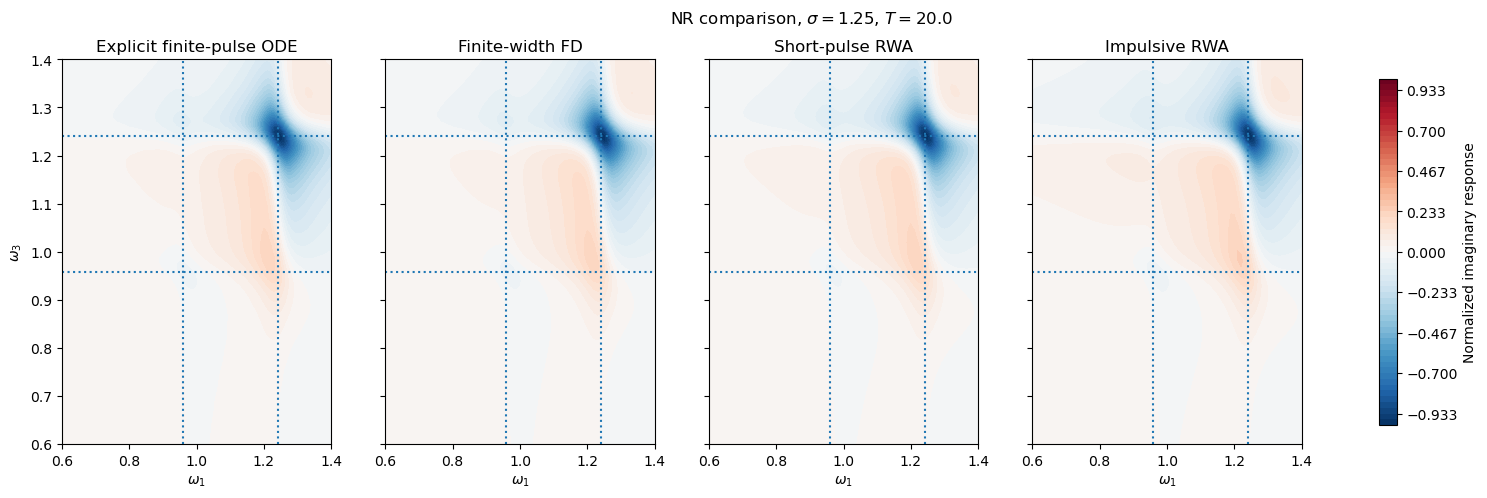

In [125]:
plot_four_model_comparison(
    x_axis=omega1_nr_scan,
    omega3_axis=omega3_scan,
    ode_data=P_NR_ODE_2D_long,
    finite_data=P_NR_FD_2D_bilat,
    short_data=P_NR_short_2D_bilat,
    impulsive_data=M_NR_impulsive_bilat,
    x_label=r"$\omega_1$",
    branch="NR",
    x_lines=[
        Omega_minus,
        Omega_plus,
    ],
    sigma=sigma_bilat,
    T=T_bilat,
    save_stem="NR_four_model_sigma1p25_T20_tmax120",
)

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/R_four_model_sigma1p25_T20_tmax120.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/R_four_model_sigma1p25_T20_tmax120.pdf


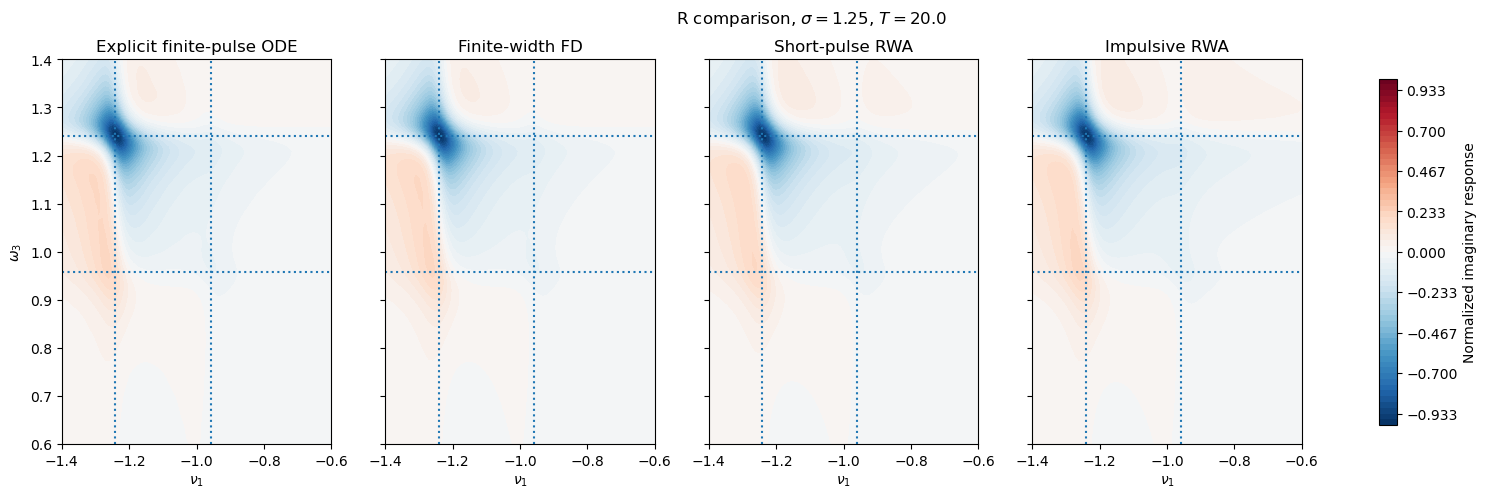

In [126]:
plot_four_model_comparison(
    x_axis=nu1_r_scan,
    omega3_axis=omega3_scan,
    ode_data=P_R_ODE_2D_long,
    finite_data=P_R_FD_2D_bilat,
    short_data=P_R_short_2D_bilat,
    impulsive_data=M_R_impulsive_bilat,
    x_label=r"$\nu_1$",
    branch="R",
    x_lines=[
        -Omega_minus,
        -Omega_plus,
    ],
    sigma=sigma_bilat,
    T=T_bilat,
    save_stem="R_four_model_sigma1p25_T20_tmax120",
)

### 7.2 Long-time convergence of the finite-pulse ODE benchmark

The finite-width frequency-domain response agrees with the explicit finite-pulse
ODE to approximately \(0.4\%\) when the time-domain Fourier window is extended
to \(t_{\max}=120\).

The temporal-step test showed no significant dependence on reducing
\(\Delta t\) from \(0.5\) to \(0.25\), indicating that the dominant numerical
error originates from finite truncation of the Fourier window.

We therefore extend the nonrephasing benchmark once more to

$$
t_{\max}=160
$$

while retaining

$$
\Delta t=0.5.
$$

If the finite-width FD/ODE discrepancy continues to decrease, this establishes
convergence of the explicit time-domain benchmark toward the analytical
frequency-domain result.

In [127]:
# ------------------------------------------------------------
# NR convergence at tmax = 160
# ------------------------------------------------------------

dt_160 = 0.5
tmax_160 = 160.0

t1_160 = np.arange(
    -8.0 * sigma_bilat,
    tmax_160 + 0.5 * dt_160,
    dt_160,
)

t3_160 = np.arange(
    -8.0 * sigma_bilat,
    tmax_160 + 0.5 * dt_160,
    dt_160,
)

print("tmax =", tmax_160)
print("dt   =", dt_160)
print("t1 points =", len(t1_160))
print("t3 points =", len(t3_160))

tmax = 160.0
dt   = 0.5
t1 points = 341
t3 points = 341


In [128]:
P_NR_ODE_td_160 = ode_time_domain_grid(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_160,
    t3_axis=t3_160,
)

t1 1/341
t1 21/341
t1 41/341
t1 61/341
t1 81/341
t1 101/341
t1 121/341
t1 141/341
t1 161/341
t1 181/341
t1 201/341
t1 221/341
t1 241/341
t1 261/341
t1 281/341
t1 301/341
t1 321/341
t1 341/341


In [129]:
P_NR_ODE_2D_160 = transform_NR_ODE_2D(
    P_td=P_NR_ODE_td_160,
    t1_axis=t1_160,
    t3_axis=t3_160,
    eta_value=eta_bilat,
)

In [130]:
_, alpha_NR_FD_160, shape_NR_FD_160 = (
    comparison_diagnostics(
        P_NR_FD_2D_bilat,
        P_NR_ODE_2D_160,
    )
)

_, alpha_NR_short_160, shape_NR_short_160 = (
    comparison_diagnostics(
        P_NR_short_2D_bilat,
        P_NR_ODE_2D_160,
    )
)

_, alpha_NR_imp_160, shape_NR_imp_160 = (
    comparison_diagnostics(
        M_NR_impulsive_bilat,
        P_NR_ODE_2D_160,
    )
)


print("FOUR-MODEL NR COMPARISON — tmax = 160")
print("--------------------------------------")
print("Explicit finite-pulse ODE :   0.0000 %")

print(
    f"Finite-width FD           : "
    f"{100.0 * shape_NR_FD_160:8.4f} %"
)

print(
    f"Short-pulse RWA           : "
    f"{100.0 * shape_NR_short_160:8.4f} %"
)

print(
    f"Impulsive RWA             : "
    f"{100.0 * shape_NR_imp_160:8.4f} %"
)

print()
print("Finite FD alpha =", alpha_NR_FD_160)

FOUR-MODEL NR COMPARISON — tmax = 160
--------------------------------------
Explicit finite-pulse ODE :   0.0000 %
Finite-width FD           :   0.0586 %
Short-pulse RWA           :   5.2707 %
Impulsive RWA             :   9.5959 %

Finite FD alpha = (0.9999967510005184+1.7727994080188193e-06j)


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_ODE_window_convergence_sigma1p25_T20.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_ODE_window_convergence_sigma1p25_T20.pdf


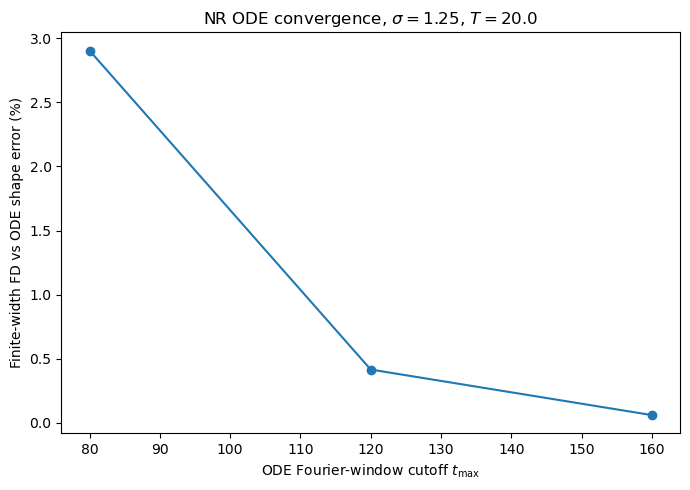

In [131]:
# ------------------------------------------------------------
# ODE Fourier-window convergence
# ------------------------------------------------------------

tmax_convergence = np.array([
    80.0,
    120.0,
    160.0,
])

fd_error_convergence = 100.0 * np.array([
    shape_fin_cons,
    shape_NR_FD_120,
    shape_NR_FD_160,
])

plt.figure(figsize=(7, 5))

plt.plot(
    tmax_convergence,
    fd_error_convergence,
    marker="o",
)

plt.xlabel(r"ODE Fourier-window cutoff $t_{\max}$")
plt.ylabel("Finite-width FD vs ODE shape error (%)")

plt.title(
    rf"NR ODE convergence, "
    rf"$\sigma={sigma_bilat}$, "
    rf"$T={T_bilat}$"
)

plt.tight_layout()

png_path = (
    figure_dir
    / "NR_ODE_window_convergence_sigma1p25_T20.png"
)

pdf_path = (
    figure_dir
    / "NR_ODE_window_convergence_sigma1p25_T20.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

In [134]:
# ------------------------------------------------------------
# R convergence at tmax = 160
# ------------------------------------------------------------

P_R_ODE_td_160 = ode_time_domain_grid(
    s1=-1,
    s2=+1,
    s3=+1,
    sigma=sigma_bilat,
    T=T_bilat,
    t1_axis=t1_160,
    t3_axis=t3_160,
)

P_R_ODE_2D_160 = transform_R_ODE_2D(
    P_td=P_R_ODE_td_160,
    t1_axis=t1_160,
    t3_axis=t3_160,
    eta_value=eta_bilat,
)

t1 1/341
t1 21/341
t1 41/341
t1 61/341
t1 81/341
t1 101/341
t1 121/341
t1 141/341
t1 161/341
t1 181/341
t1 201/341
t1 221/341
t1 241/341
t1 261/341
t1 281/341
t1 301/341
t1 321/341
t1 341/341


In [135]:
_, alpha_R_FD_160, shape_R_FD_160 = (
    comparison_diagnostics(
        P_R_FD_2D_bilat,
        P_R_ODE_2D_160,
    )
)

_, alpha_R_short_160, shape_R_short_160 = (
    comparison_diagnostics(
        P_R_short_2D_bilat,
        P_R_ODE_2D_160,
    )
)

_, alpha_R_imp_160, shape_R_imp_160 = (
    comparison_diagnostics(
        M_R_impulsive_bilat,
        P_R_ODE_2D_160,
    )
)

print("FOUR-MODEL R COMPARISON — tmax = 160")
print("--------------------------------------")
print("Explicit finite-pulse ODE :   0.0000 %")
print(
    f"Finite-width FD           : "
    f"{100 * shape_R_FD_160:8.4f} %"
)
print(
    f"Short-pulse RWA           : "
    f"{100 * shape_R_short_160:8.4f} %"
)
print(
    f"Impulsive RWA             : "
    f"{100 * shape_R_imp_160:8.4f} %"
)

print()
print("Finite FD alpha =", alpha_R_FD_160)

FOUR-MODEL R COMPARISON — tmax = 160
--------------------------------------
Explicit finite-pulse ODE :   0.0000 %
Finite-width FD           :   0.0582 %
Short-pulse RWA           :   5.5351 %
Impulsive RWA             :   9.8284 %

Finite FD alpha = (0.9999967088350513-2.3691271500728138e-07j)


In [136]:
print("FINAL CONVERGED VALIDATION — tmax = 160")
print("======================================")
print()
print("                       NR             R")
print("------------------------------------------------")
print(
    f"Finite-width FD      "
    f"{100*shape_NR_FD_160:8.4f} %    "
    f"{100*shape_R_FD_160:8.4f} %"
)
print(
    f"Short-pulse RWA      "
    f"{100*shape_NR_short_160:8.4f} %    "
    f"{100*shape_R_short_160:8.4f} %"
)
print(
    f"Impulsive RWA        "
    f"{100*shape_NR_imp_160:8.4f} %    "
    f"{100*shape_R_imp_160:8.4f} %"
)

FINAL CONVERGED VALIDATION — tmax = 160

                       NR             R
------------------------------------------------
Finite-width FD        0.0586 %      0.0582 %
Short-pulse RWA        5.2707 %      5.5351 %
Impulsive RWA          9.5959 %      9.8284 %


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_four_model_sigma1p25_T20_tmax160.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_four_model_sigma1p25_T20_tmax160.pdf


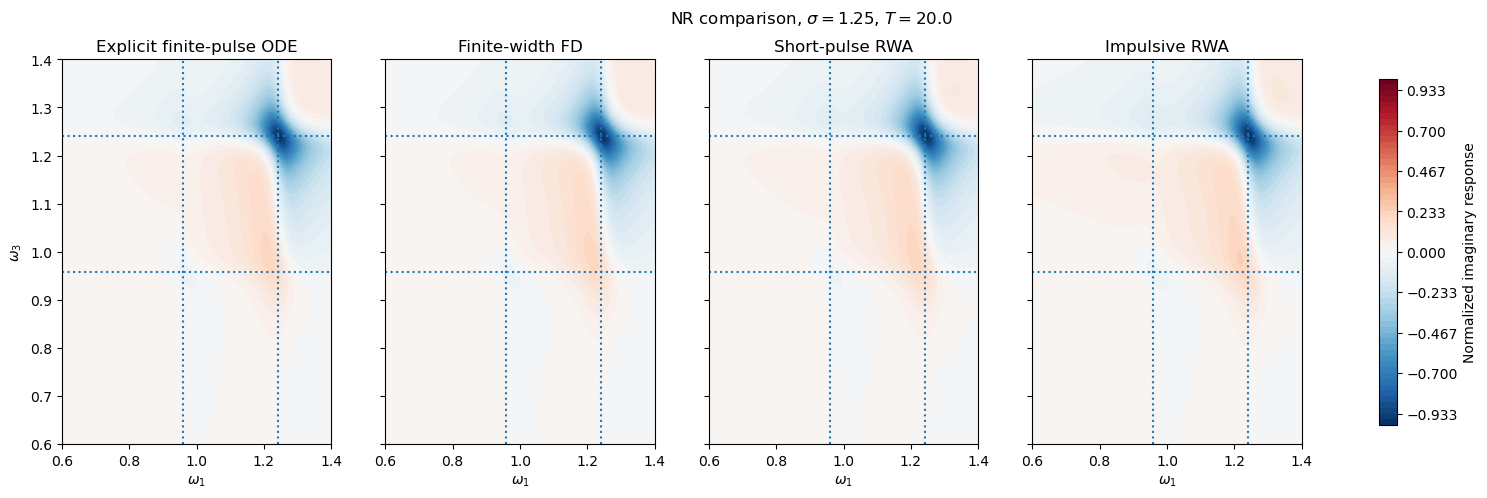

In [137]:
plot_four_model_comparison(
    x_axis=omega1_nr_scan,
    omega3_axis=omega3_scan,
    ode_data=P_NR_ODE_2D_160,
    finite_data=P_NR_FD_2D_bilat,
    short_data=P_NR_short_2D_bilat,
    impulsive_data=M_NR_impulsive_bilat,
    x_label=r"$\omega_1$",
    branch="NR",
    x_lines=[Omega_minus, Omega_plus],
    sigma=sigma_bilat,
    T=T_bilat,
    save_stem="NR_four_model_sigma1p25_T20_tmax160",
)

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/R_four_model_sigma1p25_T20_tmax160.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/R_four_model_sigma1p25_T20_tmax160.pdf


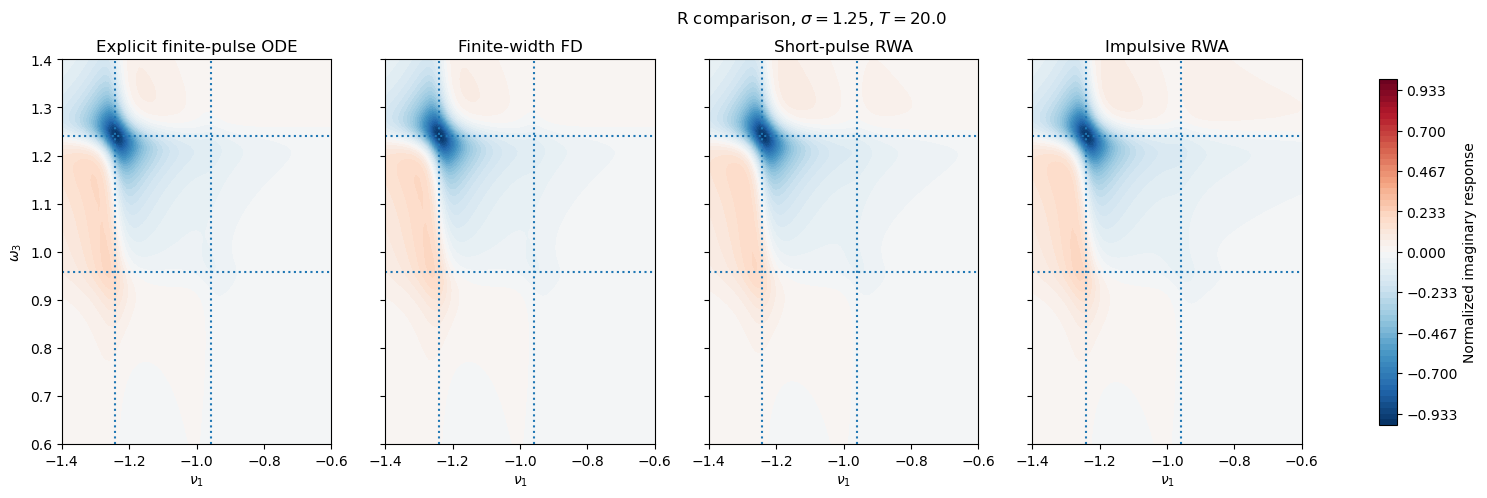

In [138]:
plot_four_model_comparison(
    x_axis=nu1_r_scan,
    omega3_axis=omega3_scan,
    ode_data=P_R_ODE_2D_160,
    finite_data=P_R_FD_2D_bilat,
    short_data=P_R_short_2D_bilat,
    impulsive_data=M_R_impulsive_bilat,
    x_label=r"$\nu_1$",
    branch="R",
    x_lines=[-Omega_minus, -Omega_plus],
    sigma=sigma_bilat,
    T=T_bilat,
    save_stem="R_four_model_sigma1p25_T20_tmax160",
)

## 8. Accuracy as a function of pulse width

The previous calculations establish that the analytical finite-width
frequency-domain response converges to the explicit finite-pulse ODE result.

For \(\sigma=1.25\), the converged spectral-shape errors are

$$
\begin{array}{c|cc}
& \mathrm{NR} & \mathrm{R}\\
\hline
\mathrm{Finite\ width\ FD} & 0.0586\% & 0.0582\%\\
\mathrm{Short\ pulse\ RWA} & 5.2707\% & 5.5351\%\\
\mathrm{Impulsive\ RWA} & 9.5959\% & 9.8284\%.
\end{array}
$$

We now vary the pulse width \(\sigma\) and use the explicit finite-pulse ODE
as the reference.

The goal is to determine three regimes:

1. the ultrashort-pulse regime, where counter-rotating contributions are not
   strongly filtered;
2. an intermediate regime where the finite-pulse operators dynamically produce
   RWA-like pathway selection;
3. the finite-width regime where molecular evolution across the pulse becomes
   important and the short-pulse approximation loses accuracy.

For each \(\sigma\), we compare

$$
P_{\mathrm{finite,FD}}^{(3)},
\qquad
P_{\mathrm{short,RWA}}^{(3)},
\qquad
M_{\mathrm{impulsive,RWA}}^{(3)}
$$

against the explicit finite-pulse ODE spectrum.

In [139]:
def ode_time_domain_grid_controlled(
    s1,
    s2,
    s3,
    sigma,
    T,
    t1_axis,
    t3_axis,
    max_step,
):
    """
    Explicit finite-pulse third-order ODE response with
    selectable internal integration step.
    """

    nL = d**2

    y0 = np.zeros(
        3 * nL,
        dtype=complex,
    )

    P_td = np.zeros(
        (
            len(t3_axis),
            len(t1_axis),
        ),
        dtype=complex,
    )

    tau1 = 0.0

    for i, t1 in enumerate(t1_axis):

        if i % 40 == 0:
            print(
                f"  t1 {i + 1}/{len(t1_axis)}"
            )

        tau2 = t1
        tau3 = t1 + T

        detection_times = (
            tau3 + t3_axis
        )

        # Start sufficiently early for every relevant pulse/time.
        t_start = (
            min(
                tau1,
                tau2,
                tau3,
                detection_times[0],
            )
            - 8.0 * sigma
        )

        t_stop = max(
            detection_times[-1],
            tau3 + 8.0 * sigma,
        )

        sol = solve_ivp(
            finite_pulse_rhs_stationary,
            (t_start, t_stop),
            y0,
            t_eval=detection_times,
            args=(
                tau1,
                tau2,
                tau3,
                s1,
                s2,
                s3,
                sigma,
            ),
            rtol=1e-8,
            atol=1e-10,
            max_step=max_step,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        rho3 = sol.y[
            2*nL:3*nL,
            :
        ]

        P_td[:, i] = (
            mu_bra @ rho3
        )

    return P_td

In [140]:
def finite_NR_FD_sigma(
    sigma,
    eta_value=eta_bilat,
):
    """
    Full-V finite-width NR frequency-domain spectrum
    for a selected pulse width.
    """

    source = np.zeros(
        (d**2, len(omega1_nr_scan)),
        dtype=complex,
    )

    for i, omega1 in enumerate(omega1_nr_scan):

        F1_op = F1_eta(
            omega1,
            +1,
            sigma,
            omega_L1,
            eta_value,
            E0=E0,
            Phi=Phi_1,
        )

        F2_op = F2_eta(
            omega1,
            -1,
            sigma,
            omega_L2,
            eta_value,
            E0=E0,
            Phi=Phi_2,
        )

        x = F1_op @ rho_ss_vec
        x = V @ x

        x = apply_G_eta(
            omega1,
            x,
            eta_value,
        )

        x = V @ x
        x = F2_op @ x

        source[:, i] = x

    P = np.zeros(
        (
            len(omega3_scan),
            len(omega1_nr_scan),
        ),
        dtype=complex,
    )

    for j, omega3 in enumerate(omega3_scan):

        F3_op = F3_eta(
            omega3,
            +1,
            sigma,
            omega_L3,
            eta_value,
            E0=E0,
            Phi=Phi_3,
        )

        X = F3_op @ source
        X = prop_T_scan @ X
        X = V @ X

        X = apply_G_eta(
            omega3,
            X,
            eta_value,
        )

        P[j, :] = mu_bra @ X

    return P

In [141]:
def short_NR_RWA_sigma(
    sigma,
    eta_value=eta_bilat,
):
    """
    Short-pulse NR RWA spectrum for a selected pulse width.
    """

    E1_values = np.array([
        E1_eta(
            omega1,
            +1,
            sigma,
            omega_L1,
            eta_value,
            E0,
            Phi_1,
        )
        for omega1 in omega1_nr_scan
    ])

    E2_values = np.array([
        E2_eta(
            omega1,
            -1,
            sigma,
            omega_L2,
            eta_value,
            E0,
            Phi_2,
        )
        for omega1 in omega1_nr_scan
    ])

    E3_values = np.array([
        E3_eta(
            omega3,
            +1,
            sigma,
            omega_L3,
            eta_value,
            E0,
            Phi_3,
        )
        for omega3 in omega3_scan
    ])

    return (
        E3_values[:, None]
        * (E2_values * E1_values)[None, :]
        * M_NR_impulsive_bilat
    )

In [142]:
sigma_ODE_scan = np.array([
    0.50,
    0.75,
    1.25,
    2.00,
    3.00,
])

tmax_sigma_scan = 120.0
dt_sigma_scan = 0.5

print("Pulse widths =", sigma_ODE_scan)
print("tmax =", tmax_sigma_scan)
print("dt   =", dt_sigma_scan)

Pulse widths = [0.5  0.75 1.25 2.   3.  ]
tmax = 120.0
dt   = 0.5


In [143]:
# ------------------------------------------------------------
# ODE-referenced pulse-width scan
# ------------------------------------------------------------

err_FD_sigma_ODE = []
err_short_sigma_ODE = []
err_imp_sigma_ODE = []

raw_FD_sigma_ODE = []
raw_short_sigma_ODE = []


for sigma_test in sigma_ODE_scan:

    print()
    print("=" * 60)
    print(f"sigma = {sigma_test}")
    print("=" * 60)

    # --------------------------------------------------------
    # Time axes
    # --------------------------------------------------------

    t1_sigma = np.arange(
        -8.0 * sigma_test,
        tmax_sigma_scan + 0.5 * dt_sigma_scan,
        dt_sigma_scan,
    )

    t3_sigma = np.arange(
        -8.0 * sigma_test,
        tmax_sigma_scan + 0.5 * dt_sigma_scan,
        dt_sigma_scan,
    )

    # Resolve the physical pulse itself accurately.
    max_step_sigma = min(
        0.2,
        sigma_test / 5.0,
    )

    print("t1 points =", len(t1_sigma))
    print("t3 points =", len(t3_sigma))
    print("ODE max_step =", max_step_sigma)

    # --------------------------------------------------------
    # Explicit finite-pulse ODE
    # --------------------------------------------------------

    P_NR_td_sigma = ode_time_domain_grid_controlled(
        s1=+1,
        s2=-1,
        s3=+1,
        sigma=sigma_test,
        T=T_bilat,
        t1_axis=t1_sigma,
        t3_axis=t3_sigma,
        max_step=max_step_sigma,
    )

    P_NR_ODE_sigma = transform_NR_ODE_2D(
        P_td=P_NR_td_sigma,
        t1_axis=t1_sigma,
        t3_axis=t3_sigma,
        eta_value=eta_bilat,
    )

    # --------------------------------------------------------
    # Analytical finite-width FD
    # --------------------------------------------------------

    P_NR_FD_sigma = finite_NR_FD_sigma(
        sigma_test,
        eta_bilat,
    )

    # --------------------------------------------------------
    # Short-pulse RWA
    # --------------------------------------------------------

    P_NR_short_sigma = short_NR_RWA_sigma(
        sigma_test,
        eta_bilat,
    )

    # --------------------------------------------------------
    # Errors against ODE
    # --------------------------------------------------------

    raw_FD, _, shape_FD = comparison_diagnostics(
        P_NR_FD_sigma,
        P_NR_ODE_sigma,
    )

    raw_short, _, shape_short = comparison_diagnostics(
        P_NR_short_sigma,
        P_NR_ODE_sigma,
    )

    _, _, shape_imp = comparison_diagnostics(
        M_NR_impulsive_bilat,
        P_NR_ODE_sigma,
    )

    err_FD_sigma_ODE.append(shape_FD)
    err_short_sigma_ODE.append(shape_short)
    err_imp_sigma_ODE.append(shape_imp)

    raw_FD_sigma_ODE.append(raw_FD)
    raw_short_sigma_ODE.append(raw_short)

    print()
    print(
        "Finite FD shape error =",
        100.0 * shape_FD,
        "%"
    )

    print(
        "Short RWA shape error =",
        100.0 * shape_short,
        "%"
    )

    print(
        "Impulsive shape error =",
        100.0 * shape_imp,
        "%"
    )


err_FD_sigma_ODE = np.array(err_FD_sigma_ODE)
err_short_sigma_ODE = np.array(err_short_sigma_ODE)
err_imp_sigma_ODE = np.array(err_imp_sigma_ODE)

raw_FD_sigma_ODE = np.array(raw_FD_sigma_ODE)
raw_short_sigma_ODE = np.array(raw_short_sigma_ODE)


sigma = 0.5
t1 points = 249
t3 points = 249
ODE max_step = 0.1
  t1 1/249
  t1 41/249
  t1 81/249
  t1 121/249
  t1 161/249
  t1 201/249
  t1 241/249

Finite FD shape error = 0.4075154586114377 %
Short RWA shape error = 6.441031432159354 %
Impulsive shape error = 6.996930181565439 %

sigma = 0.75
t1 points = 253
t3 points = 253
ODE max_step = 0.15
  t1 1/253
  t1 41/253
  t1 81/253
  t1 121/253
  t1 161/253
  t1 201/253
  t1 241/253

Finite FD shape error = 0.41163383061946346 %
Short RWA shape error = 5.6529578181059374 %
Impulsive shape error = 7.2237484419888895 %

sigma = 1.25
t1 points = 261
t3 points = 261
ODE max_step = 0.2
  t1 1/261
  t1 41/261
  t1 81/261
  t1 121/261
  t1 161/261
  t1 201/261
  t1 241/261

Finite FD shape error = 0.4144184053545716 %
Short RWA shape error = 5.285485514553039 %
Impulsive shape error = 9.604512117197789 %

sigma = 2.0
t1 points = 273
t3 points = 273
ODE max_step = 0.2
  t1 1/273
  t1 41/273
  t1 81/273
  t1 121/273
  t1 161/273
  t1 201/273
 

In [144]:
print("NR ODE-REFERENCED PULSE-WIDTH SCAN")
print("----------------------------------")
print()
print(
    "sigma       Finite FD      Short RWA      Impulsive RWA"
)
print(
    "-------------------------------------------------------"
)

for sigma, e_fd, e_short, e_imp in zip(
    sigma_ODE_scan,
    err_FD_sigma_ODE,
    err_short_sigma_ODE,
    err_imp_sigma_ODE,
):
    print(
        f"{sigma:5.2f}       "
        f"{100*e_fd:8.4f} %      "
        f"{100*e_short:8.4f} %      "
        f"{100*e_imp:8.4f} %"
    )

NR ODE-REFERENCED PULSE-WIDTH SCAN
----------------------------------

sigma       Finite FD      Short RWA      Impulsive RWA
-------------------------------------------------------
 0.50         0.4075 %        6.4410 %        6.9969 %
 0.75         0.4116 %        5.6530 %        7.2237 %
 1.25         0.4144 %        5.2855 %        9.6045 %
 2.00         0.4177 %        5.2635 %       14.7256 %
 3.00         0.4220 %        6.5722 %       22.1223 %


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_error_vs_sigma_ODE_reference.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_error_vs_sigma_ODE_reference.pdf


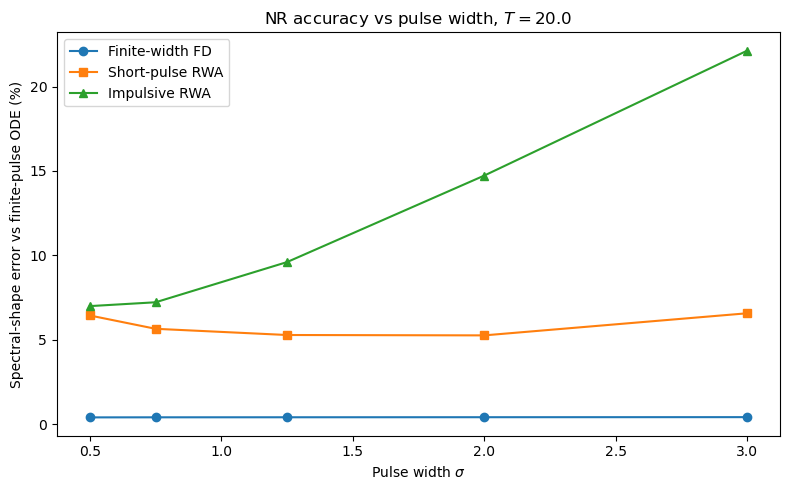

In [145]:
plt.figure(figsize=(8, 5))

plt.plot(
    sigma_ODE_scan,
    100.0 * err_FD_sigma_ODE,
    marker="o",
    label="Finite-width FD",
)

plt.plot(
    sigma_ODE_scan,
    100.0 * err_short_sigma_ODE,
    marker="s",
    label="Short-pulse RWA",
)

plt.plot(
    sigma_ODE_scan,
    100.0 * err_imp_sigma_ODE,
    marker="^",
    label="Impulsive RWA",
)

plt.xlabel(r"Pulse width $\sigma$")
plt.ylabel("Spectral-shape error vs finite-pulse ODE (%)")

plt.title(
    rf"NR accuracy vs pulse width, $T={T_bilat}$"
)

plt.legend()
plt.tight_layout()

png_path = (
    figure_dir
    / "NR_error_vs_sigma_ODE_reference.png"
)

pdf_path = (
    figure_dir
    / "NR_error_vs_sigma_ODE_reference.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

### 8.1 The true impulsive limit of the full-\(V\) finite-width theory

The impulsive RWA response is not the \(\sigma\rightarrow0\) limit of the
finite-width full-\(V\) formulation.

For Gaussian pulses,

$$
F_j^{(s)}
\xrightarrow[\sigma\rightarrow0]{}
C_j e^{is\Phi_j} I,
$$

where

$$
C_j=\frac{E_0}{2}\sqrt{2\pi}\sigma.
$$

Therefore the finite-width response approaches the impulsive full-\(V\)
molecular response,

$$
M_{\mathrm{full},\mathrm{imp}}^{(3)}
=
\left\langle\!\left\langle
\mu
\left|
G(\omega_3)
V e^{\mathcal LT}
V G(\omega_1)
V
\right|
\rho_{\mathrm{ss}}
\right\rangle\!\right\rangle .
$$

By contrast, the short-pulse RWA response approaches the impulsive RWA
response as the pulse bandwidth becomes infinitely broad.

Thus there are two distinct impulsive limits:

$$
\mathrm{Finite\ width\ full\!-\!V}
\rightarrow
\mathrm{Impulsive\ full\!-\!V},
$$

and

$$
\mathrm{Short\ pulse\ RWA}
\rightarrow
\mathrm{Impulsive\ RWA}.
$$

In [146]:
# ------------------------------------------------------------
# Impulsive full-V NR molecular response
# ------------------------------------------------------------

source_NR_imp_fullV = np.zeros(
    (d**2, len(omega1_nr_scan)),
    dtype=complex,
)

for i, omega1 in enumerate(omega1_nr_scan):

    x = V @ rho_ss_vec

    x = apply_G_eta(
        omega1,
        x,
        eta_bilat,
    )

    x = V @ x
    x = prop_T_scan @ x
    x = V @ x

    source_NR_imp_fullV[:, i] = x


M_NR_impulsive_fullV = np.zeros(
    (
        len(omega3_scan),
        len(omega1_nr_scan),
    ),
    dtype=complex,
)

for j, omega3 in enumerate(omega3_scan):

    X = apply_G_eta(
        omega3,
        source_NR_imp_fullV,
        eta_bilat,
    )

    M_NR_impulsive_fullV[j, :] = mu_bra @ X


print(
    "Impulsive full-V all finite =",
    np.all(np.isfinite(M_NR_impulsive_fullV)),
)

Impulsive full-V all finite = True


In [147]:
sigma_impulsive_limit = np.array([
    0.50,
    0.30,
    0.20,
    0.10,
    0.05,
])

err_finite_to_fullV_imp = []
err_short_to_RWA_imp = []


for sigma_test in sigma_impulsive_limit:

    # Finite-width full-V
    P_fin = finite_NR_FD_sigma(
        sigma_test,
        eta_bilat,
    )

    # Short-pulse RWA
    P_short = short_NR_RWA_sigma(
        sigma_test,
        eta_bilat,
    )

    # Compare shape, so the sigma^3 pulse-area factor
    # does not matter.
    _, _, err_fin = comparison_diagnostics(
        P_fin,
        M_NR_impulsive_fullV,
    )

    _, _, err_short = comparison_diagnostics(
        P_short,
        M_NR_impulsive_bilat,
    )

    err_finite_to_fullV_imp.append(err_fin)
    err_short_to_RWA_imp.append(err_short)


err_finite_to_fullV_imp = np.array(
    err_finite_to_fullV_imp
)

err_short_to_RWA_imp = np.array(
    err_short_to_RWA_imp
)

In [148]:
print("IMPULSIVE-LIMIT TEST")
print("--------------------")
print()
print(
    "sigma      Finite FD -> full-V imp.    "
    "Short RWA -> RWA imp."
)
print(
    "--------------------------------------------------------"
)

for sigma, e_full, e_rwa in zip(
    sigma_impulsive_limit,
    err_finite_to_fullV_imp,
    err_short_to_RWA_imp,
):
    print(
        f"{sigma:5.2f}            "
        f"{100*e_full:8.4f} %            "
        f"{100*e_rwa:8.4f} %"
    )

IMPULSIVE-LIMIT TEST
--------------------

sigma      Finite FD -> full-V imp.    Short RWA -> RWA imp.
--------------------------------------------------------
 0.50             10.0675 %              1.0492 %
 0.30              4.8316 %              0.3844 %
 0.20              2.3395 %              0.1718 %
 0.10              0.6143 %              0.0431 %
 0.05              0.1554 %              0.0108 %


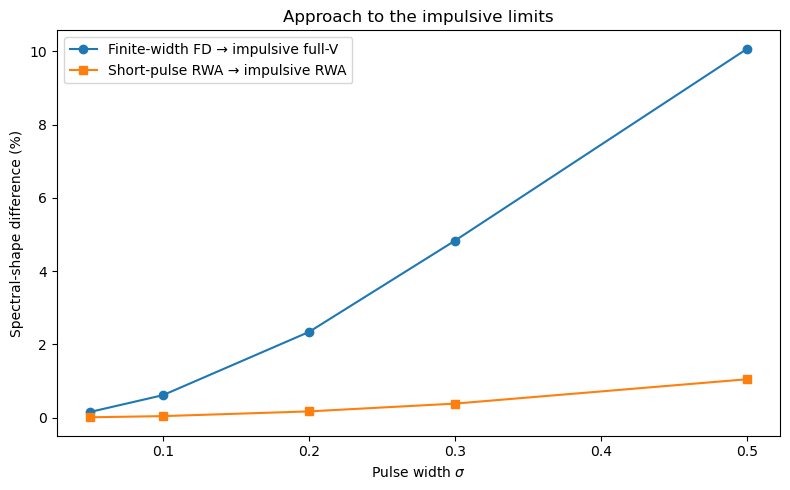

In [149]:
plt.figure(figsize=(8, 5))

plt.plot(
    sigma_impulsive_limit,
    100.0 * err_finite_to_fullV_imp,
    marker="o",
    label="Finite-width FD → impulsive full-V",
)

plt.plot(
    sigma_impulsive_limit,
    100.0 * err_short_to_RWA_imp,
    marker="s",
    label="Short-pulse RWA → impulsive RWA",
)

plt.xlabel(r"Pulse width $\sigma$")
plt.ylabel("Spectral-shape difference (%)")

plt.title("Approach to the impulsive limits")

plt.legend()
plt.tight_layout()
plt.show()

### 8.2 Timescale map for the three pulse-width regimes

The impulsive approximation and the rotating-wave approximation are controlled by
different timescales.

For the counter-rotating terms, the relevant mismatch is approximately

$$
\Delta_{\mathrm{CR}}
\simeq
\Omega_+ + \omega_L.
$$

The dimensionless quantity

$$
\chi_{\mathrm{CR}}
=
\Delta_{\mathrm{CR}}\sigma
$$

measures how much rapidly oscillating counter-rotating phase accumulates across the
pulse. RWA-like filtering requires

$$
\chi_{\mathrm{CR}}\gg1.
$$

Slow molecular evolution during the pulse can be characterized approximately by

$$
\chi_J = J\sigma,
\qquad
\chi_\gamma = \gamma\sigma.
$$

The impulsive approximation requires these quantities to remain much smaller than
one.

This gives three qualitative regimes:

1. **Ultrashort / non-RWA:** the pulse is too short to suppress counter-rotating terms.
2. **Impulsive-RWA window:** counter-rotating terms are filtered while slow molecular
   evolution remains weak during the pulse.
3. **Finite-pulse regime:** molecular evolution across the pulse becomes increasingly
   important, and the finite-width \(F_j\) operators are required.

The boundaries shown below are heuristic crossover scales rather than exact validity
limits.

In [150]:
# ------------------------------------------------------------
# Characteristic pulse-width scales
# ------------------------------------------------------------

Delta_CR = Omega_plus + omega_L1

gamma_scale = max(
    gamma_a,
    gamma_b,
)

sigma_CR_natural = 1.0 / Delta_CR
sigma_J_natural = 1.0 / abs(J)
sigma_gamma_natural = 1.0 / gamma_scale

print("Characteristic scales")
print("---------------------")
print("Delta_CR =", Delta_CR)
print()
print("1 / Delta_CR =", sigma_CR_natural)
print("1 / J        =", sigma_J_natural)
print("1 / gamma    =", sigma_gamma_natural)

Characteristic scales
---------------------
Delta_CR = 2.482842712474619

1 / Delta_CR = 0.40276413603474387
1 / J        = 10.0
1 / gamma    = 20.0


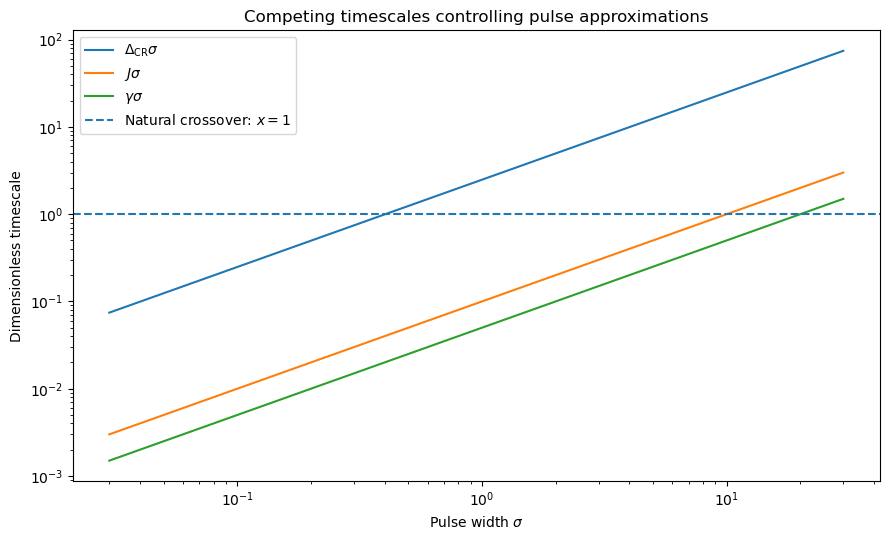

In [151]:
# ------------------------------------------------------------
# Dimensionless timescale map
# ------------------------------------------------------------

sigma_regime = np.logspace(
    np.log10(0.03),
    np.log10(30.0),
    500,
)

chi_CR = Delta_CR * sigma_regime
chi_J = abs(J) * sigma_regime
chi_gamma = gamma_scale * sigma_regime


plt.figure(figsize=(9, 5.5))

plt.plot(
    sigma_regime,
    chi_CR,
    label=r"$\Delta_{\mathrm{CR}}\sigma$",
)

plt.plot(
    sigma_regime,
    chi_J,
    label=r"$J\sigma$",
)

plt.plot(
    sigma_regime,
    chi_gamma,
    label=r"$\gamma\sigma$",
)

plt.axhline(
    1.0,
    linestyle="--",
    label=r"Natural crossover: $x=1$",
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Pulse width $\sigma$")
plt.ylabel("Dimensionless timescale")

plt.title("Competing timescales controlling pulse approximations")

plt.legend()
plt.tight_layout()
plt.show()

In [152]:
# ------------------------------------------------------------
# Heuristic regime boundaries
# ------------------------------------------------------------

rwa_threshold = 3.0
impulsive_threshold = 0.30

slow_scale = max(
    abs(J),
    gamma_scale,
)

sigma_RWA_boundary = (
    rwa_threshold / Delta_CR
)

sigma_finite_boundary = (
    impulsive_threshold / slow_scale
)

print("Heuristic regime boundaries")
print("----------------------------")
print(
    "RWA filtering boundary       =",
    sigma_RWA_boundary,
)
print(
    "Finite-pulse boundary        =",
    sigma_finite_boundary,
)

print()
print(
    "At RWA boundary: Delta_CR*sigma =",
    Delta_CR * sigma_RWA_boundary,
)

print(
    "At finite boundary: slow*sigma =",
    slow_scale * sigma_finite_boundary,
)

Heuristic regime boundaries
----------------------------
RWA filtering boundary       = 1.2082924081042317
Finite-pulse boundary        = 2.9999999999999996

At RWA boundary: Delta_CR*sigma = 3.0
At finite boundary: slow*sigma = 0.3


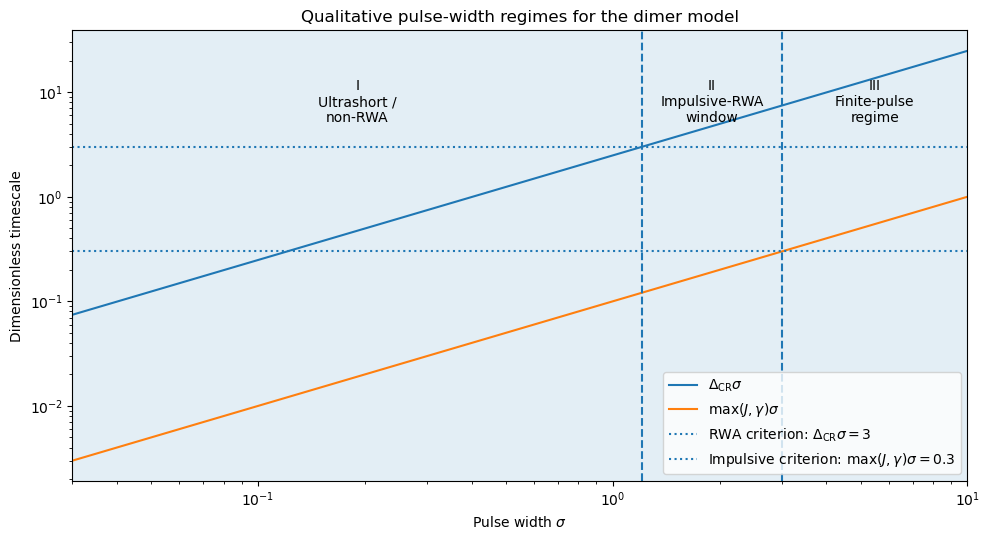

In [153]:
# ------------------------------------------------------------
# Three-regime pulse-width map
# ------------------------------------------------------------

sigma_min_plot = 0.03
sigma_max_plot = 10.0

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

# ------------------------------------------------------------
# Regime shading
# ------------------------------------------------------------

ax.axvspan(
    sigma_min_plot,
    sigma_RWA_boundary,
    alpha=0.12,
)

ax.axvspan(
    sigma_RWA_boundary,
    sigma_finite_boundary,
    alpha=0.12,
)

ax.axvspan(
    sigma_finite_boundary,
    sigma_max_plot,
    alpha=0.12,
)

# ------------------------------------------------------------
# Dimensionless conditions
# ------------------------------------------------------------

sigma_map = np.logspace(
    np.log10(sigma_min_plot),
    np.log10(sigma_max_plot),
    500,
)

ax.plot(
    sigma_map,
    Delta_CR * sigma_map,
    label=r"$\Delta_{\mathrm{CR}}\sigma$",
)

ax.plot(
    sigma_map,
    slow_scale * sigma_map,
    label=r"$\max(J,\gamma)\sigma$",
)

ax.axhline(
    rwa_threshold,
    linestyle=":",
    label=r"RWA criterion: $\Delta_{\mathrm{CR}}\sigma=3$",
)

ax.axhline(
    impulsive_threshold,
    linestyle=":",
    label=r"Impulsive criterion: $\max(J,\gamma)\sigma=0.3$",
)

ax.axvline(
    sigma_RWA_boundary,
    linestyle="--",
)

ax.axvline(
    sigma_finite_boundary,
    linestyle="--",
)

# ------------------------------------------------------------
# Regime labels
# ------------------------------------------------------------

ax.text(
    np.sqrt(
        sigma_min_plot
        * sigma_RWA_boundary
    ),
    8.0,
    "I\nUltrashort /\nnon-RWA",
    ha="center",
    va="center",
)

ax.text(
    np.sqrt(
        sigma_RWA_boundary
        * sigma_finite_boundary
    ),
    8.0,
    "II\nImpulsive-RWA\nwindow",
    ha="center",
    va="center",
)

ax.text(
    np.sqrt(
        sigma_finite_boundary
        * sigma_max_plot
    ),
    8.0,
    "III\nFinite-pulse\nregime",
    ha="center",
    va="center",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(
    sigma_min_plot,
    sigma_max_plot,
)

ax.set_xlabel(r"Pulse width $\sigma$")
ax.set_ylabel("Dimensionless timescale")

ax.set_title(
    "Qualitative pulse-width regimes for the dimer model"
)

ax.legend(
    loc="lower right",
)

plt.tight_layout()
plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_three_regimes_existing_ODE_scan.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_three_regimes_existing_ODE_scan.pdf


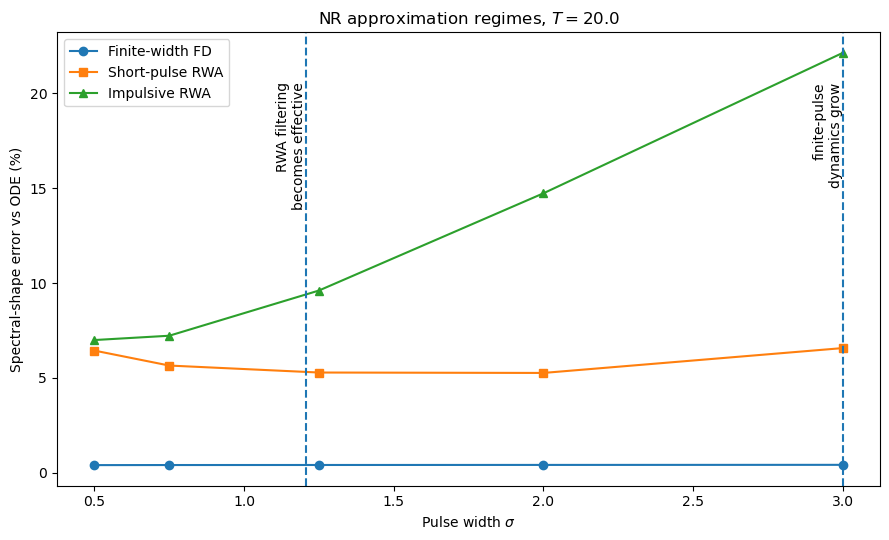

In [154]:
# ------------------------------------------------------------
# Existing numerical errors with theoretical regime markers
# ------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

plt.plot(
    sigma_ODE_scan,
    100.0 * err_FD_sigma_ODE,
    marker="o",
    label="Finite-width FD",
)

plt.plot(
    sigma_ODE_scan,
    100.0 * err_short_sigma_ODE,
    marker="s",
    label="Short-pulse RWA",
)

plt.plot(
    sigma_ODE_scan,
    100.0 * err_imp_sigma_ODE,
    marker="^",
    label="Impulsive RWA",
)

# ------------------------------------------------------------
# Heuristic regime boundaries
# ------------------------------------------------------------

plt.axvline(
    sigma_RWA_boundary,
    linestyle="--",
)

plt.axvline(
    sigma_finite_boundary,
    linestyle="--",
)

ymax = max(
    100.0 * np.max(err_imp_sigma_ODE),
    1.0,
)

plt.text(
    sigma_RWA_boundary,
    0.93 * ymax,
    "RWA filtering\nbecomes effective",
    rotation=90,
    va="top",
    ha="right",
)

plt.text(
    sigma_finite_boundary,
    0.93 * ymax,
    "finite-pulse\ndynamics grow",
    rotation=90,
    va="top",
    ha="right",
)

plt.xlabel(r"Pulse width $\sigma$")
plt.ylabel("Spectral-shape error vs ODE (%)")

plt.title(
    rf"NR approximation regimes, $T={T_bilat}$"
)

plt.legend()
plt.tight_layout()

png_path = (
    figure_dir
    / "NR_three_regimes_existing_ODE_scan.png"
)

pdf_path = (
    figure_dir
    / "NR_three_regimes_existing_ODE_scan.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

### 8.3 Extended breakdown scan

We now extend the ODE-referenced pulse-width scan toward both the
ultrashort and long-pulse limits.

Only three approximate descriptions are compared:

$$
P_{\mathrm{finite,FD}},
\qquad
P_{\mathrm{short,RWA}},
\qquad
P_{\mathrm{impulsive,RWA}}.
$$

The explicit finite-pulse full-\(V\) ODE is the reference.

At small pulse width, disagreement of the RWA-based models is expected
because counter-rotating contributions are insufficiently suppressed.

At large pulse width, the impulsive and short-pulse approximations are
expected to fail because molecular evolution during the pulse becomes
important.

For sufficiently large pulse widths at fixed waiting time \(T\), the
pulses themselves eventually overlap. This lies outside the
separated-pulse assumption underlying the current finite-width
frequency-domain factorization and provides a distinct test of its
domain of validity.

In [155]:
# ------------------------------------------------------------
# Extended sigma points
# ------------------------------------------------------------

sigma_extension = np.array([
    0.10,
    0.20,
    0.30,
    4.00,
    6.00,
    8.00,
    10.00,
])

tmax_extension = 120.0

print("New sigma values")
print("----------------")
print()

for sigma in sigma_extension:
    print(
        f"sigma = {sigma:5.2f}   "
        f"T/sigma = {T_bilat/sigma:7.3f}"
    )

New sigma values
----------------

sigma =  0.10   T/sigma = 200.000
sigma =  0.20   T/sigma = 100.000
sigma =  0.30   T/sigma =  66.667
sigma =  4.00   T/sigma =   5.000
sigma =  6.00   T/sigma =   3.333
sigma =  8.00   T/sigma =   2.500
sigma = 10.00   T/sigma =   2.000


In [156]:
def run_NR_extended_sigma_point(
    sigma_test,
):
    """
    Compute NR ODE-reference errors for one pulse width.
    """

    # --------------------------------------------------------
    # Fourier-transform time sampling
    # --------------------------------------------------------

    if sigma_test <= 0.30:
        dt_transform = 0.25
    else:
        dt_transform = 0.50

    # --------------------------------------------------------
    # ODE internal step
    #
    # Small enough to resolve narrow Gaussian pulses.
    # --------------------------------------------------------

    max_step_sigma = min(
        0.20,
        sigma_test / 5.0,
    )

    t1_sigma = np.arange(
        -8.0 * sigma_test,
        tmax_extension + 0.5 * dt_transform,
        dt_transform,
    )

    t3_sigma = np.arange(
        -8.0 * sigma_test,
        tmax_extension + 0.5 * dt_transform,
        dt_transform,
    )

    print()
    print("=" * 60)
    print(f"sigma = {sigma_test}")
    print(f"T/sigma = {T_bilat/sigma_test}")
    print(f"dt_transform = {dt_transform}")
    print(f"ODE max_step = {max_step_sigma}")
    print(f"t1 points = {len(t1_sigma)}")
    print(f"t3 points = {len(t3_sigma)}")
    print("=" * 60)

    # --------------------------------------------------------
    # Full-V finite-pulse ODE
    # --------------------------------------------------------

    P_NR_td = ode_time_domain_grid_controlled(
        s1=+1,
        s2=-1,
        s3=+1,
        sigma=sigma_test,
        T=T_bilat,
        t1_axis=t1_sigma,
        t3_axis=t3_sigma,
        max_step=max_step_sigma,
    )

    P_NR_ODE = transform_NR_ODE_2D(
        P_td=P_NR_td,
        t1_axis=t1_sigma,
        t3_axis=t3_sigma,
        eta_value=eta_bilat,
    )

    # --------------------------------------------------------
    # Finite-width full-V frequency domain
    # --------------------------------------------------------

    P_NR_FD = finite_NR_FD_sigma(
        sigma_test,
        eta_bilat,
    )

    # --------------------------------------------------------
    # Short-pulse RWA
    # --------------------------------------------------------

    P_NR_short = short_NR_RWA_sigma(
        sigma_test,
        eta_bilat,
    )

    # --------------------------------------------------------
    # Errors vs ODE
    # --------------------------------------------------------

    _, alpha_FD, err_FD = comparison_diagnostics(
        P_NR_FD,
        P_NR_ODE,
    )

    _, alpha_short, err_short = comparison_diagnostics(
        P_NR_short,
        P_NR_ODE,
    )

    _, alpha_imp, err_imp = comparison_diagnostics(
        M_NR_impulsive_bilat,
        P_NR_ODE,
    )

    print()
    print(
        f"Finite-width FD : {100*err_FD:8.4f} %"
    )
    print(
        f"Short-pulse RWA : {100*err_short:8.4f} %"
    )
    print(
        f"Impulsive RWA   : {100*err_imp:8.4f} %"
    )

    return {
        "sigma": sigma_test,
        "T_over_sigma": T_bilat / sigma_test,
        "dt": dt_transform,
        "err_FD": err_FD,
        "err_short": err_short,
        "err_imp": err_imp,
        "alpha_FD": alpha_FD,
        "alpha_short": alpha_short,
        "alpha_imp": alpha_imp,
    }

In [157]:
extended_results = []

for sigma_test in sigma_extension:

    result = run_NR_extended_sigma_point(
        sigma_test,
    )

    extended_results.append(result)


sigma = 0.1
T/sigma = 200.0
dt_transform = 0.25
ODE max_step = 0.02
t1 points = 484
t3 points = 484
  t1 1/484
  t1 41/484
  t1 81/484
  t1 121/484
  t1 161/484
  t1 201/484
  t1 241/484
  t1 281/484
  t1 321/484
  t1 361/484
  t1 401/484
  t1 441/484
  t1 481/484

Finite-width FD :   0.3990 %
Short-pulse RWA :  12.8826 %
Impulsive RWA   :  12.8862 %

sigma = 0.2
T/sigma = 100.0
dt_transform = 0.25
ODE max_step = 0.04
t1 points = 487
t3 points = 487
  t1 1/487
  t1 41/487
  t1 81/487
  t1 121/487
  t1 161/487
  t1 201/487
  t1 241/487
  t1 281/487
  t1 321/487
  t1 361/487
  t1 401/487
  t1 441/487
  t1 481/487

Finite-width FD :   0.4018 %
Short-pulse RWA :  11.4660 %
Impulsive RWA   :  11.4896 %

sigma = 0.3
T/sigma = 66.66666666666667
dt_transform = 0.25
ODE max_step = 0.06
t1 points = 491
t3 points = 491
  t1 1/491
  t1 41/491
  t1 81/491
  t1 121/491
  t1 161/491
  t1 201/491
  t1 241/491
  t1 281/491
  t1 321/491
  t1 361/491
  t1 401/491
  t1 441/491
  t1 481/491

Finite-width 

In [158]:
# ------------------------------------------------------------
# Existing data
# ------------------------------------------------------------

sigma_existing = np.array(
    sigma_ODE_scan,
    dtype=float,
)

FD_existing = np.array(
    err_FD_sigma_ODE,
    dtype=float,
)

short_existing = np.array(
    err_short_sigma_ODE,
    dtype=float,
)

imp_existing = np.array(
    err_imp_sigma_ODE,
    dtype=float,
)

# ------------------------------------------------------------
# New data
# ------------------------------------------------------------

sigma_new = np.array([
    r["sigma"]
    for r in extended_results
])

FD_new = np.array([
    r["err_FD"]
    for r in extended_results
])

short_new = np.array([
    r["err_short"]
    for r in extended_results
])

imp_new = np.array([
    r["err_imp"]
    for r in extended_results
])

# ------------------------------------------------------------
# Merge and sort
# ------------------------------------------------------------

sigma_extended_all = np.concatenate([
    sigma_existing,
    sigma_new,
])

err_FD_extended_all = np.concatenate([
    FD_existing,
    FD_new,
])

err_short_extended_all = np.concatenate([
    short_existing,
    short_new,
])

err_imp_extended_all = np.concatenate([
    imp_existing,
    imp_new,
])

order = np.argsort(
    sigma_extended_all
)

sigma_extended_all = (
    sigma_extended_all[order]
)

err_FD_extended_all = (
    err_FD_extended_all[order]
)

err_short_extended_all = (
    err_short_extended_all[order]
)

err_imp_extended_all = (
    err_imp_extended_all[order]
)

In [159]:
print("EXTENDED NR BREAKDOWN SCAN")
print("--------------------------")
print()
print(
    " sigma    T/sigma    Finite FD    "
    "Short RWA    Impulsive RWA"
)
print(
    "--------------------------------------------------------------"
)

for sigma, e_fd, e_short, e_imp in zip(
    sigma_extended_all,
    err_FD_extended_all,
    err_short_extended_all,
    err_imp_extended_all,
):

    print(
        f"{sigma:6.2f}   "
        f"{T_bilat/sigma:7.2f}      "
        f"{100*e_fd:8.3f}%    "
        f"{100*e_short:8.3f}%    "
        f"{100*e_imp:8.3f}%"
    )

EXTENDED NR BREAKDOWN SCAN
--------------------------

 sigma    T/sigma    Finite FD    Short RWA    Impulsive RWA
--------------------------------------------------------------
  0.10    200.00         0.399%      12.883%      12.886%
  0.20    100.00         0.402%      11.466%      11.490%
  0.30     66.67         0.400%       9.540%       9.630%
  0.50     40.00         0.408%       6.441%       6.997%
  0.75     26.67         0.412%       5.653%       7.224%
  1.25     16.00         0.414%       5.285%       9.605%
  2.00     10.00         0.418%       5.263%      14.726%
  3.00      6.67         0.422%       6.572%      22.122%
  4.00      5.00         0.432%       9.036%      29.421%
  6.00      3.33         3.209%      13.546%      42.503%
  8.00      2.50        12.833%      14.275%      51.593%
 10.00      2.00        26.333%      13.395%      57.889%


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_extended_breakdown_vs_sigma.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_extended_breakdown_vs_sigma.pdf


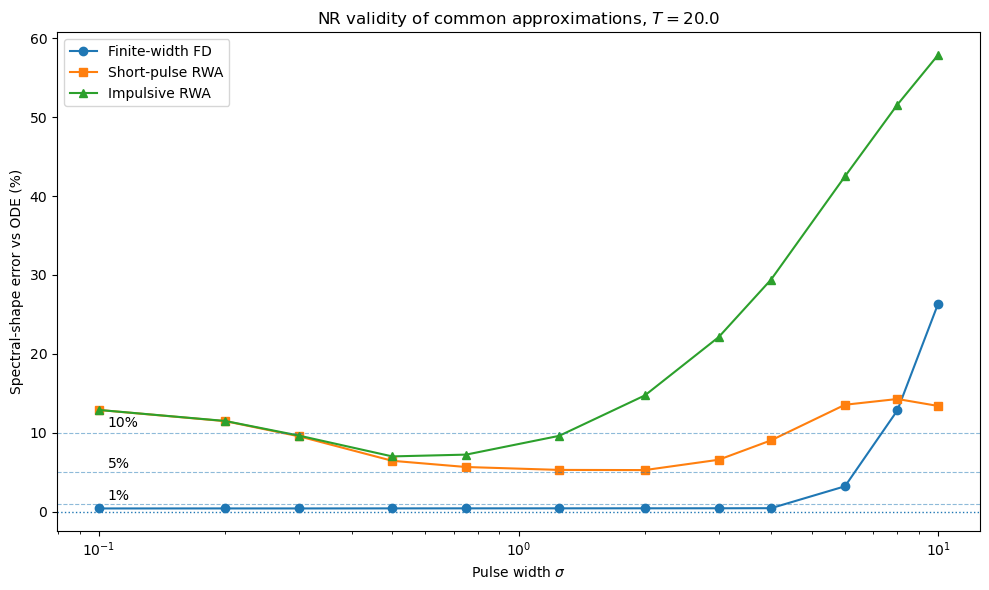

In [160]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    sigma_extended_all,
    100.0 * err_FD_extended_all,
    marker="o",
    label="Finite-width FD",
)

ax.plot(
    sigma_extended_all,
    100.0 * err_short_extended_all,
    marker="s",
    label="Short-pulse RWA",
)

ax.plot(
    sigma_extended_all,
    100.0 * err_imp_extended_all,
    marker="^",
    label="Impulsive RWA",
)

# ODE itself is the zero-error reference.
ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1,
)

# Useful visual error guides.
for level in [1.0, 5.0, 10.0]:
    ax.axhline(
        level,
        linestyle="--",
        linewidth=0.8,
        alpha=0.5,
    )

    ax.text(
        sigma_extended_all[0] * 1.05,
        level * 1.03,
        f"{level:.0f}%",
        va="bottom",
    )

ax.set_xscale("log")

ax.set_xlabel(
    r"Pulse width $\sigma$"
)

ax.set_ylabel(
    "Spectral-shape error vs ODE (%)"
)

ax.set_title(
    rf"NR validity of common approximations, "
    rf"$T={T_bilat}$"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "NR_extended_breakdown_vs_sigma.png"
)

pdf_path = (
    figure_dir
    / "NR_extended_breakdown_vs_sigma.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

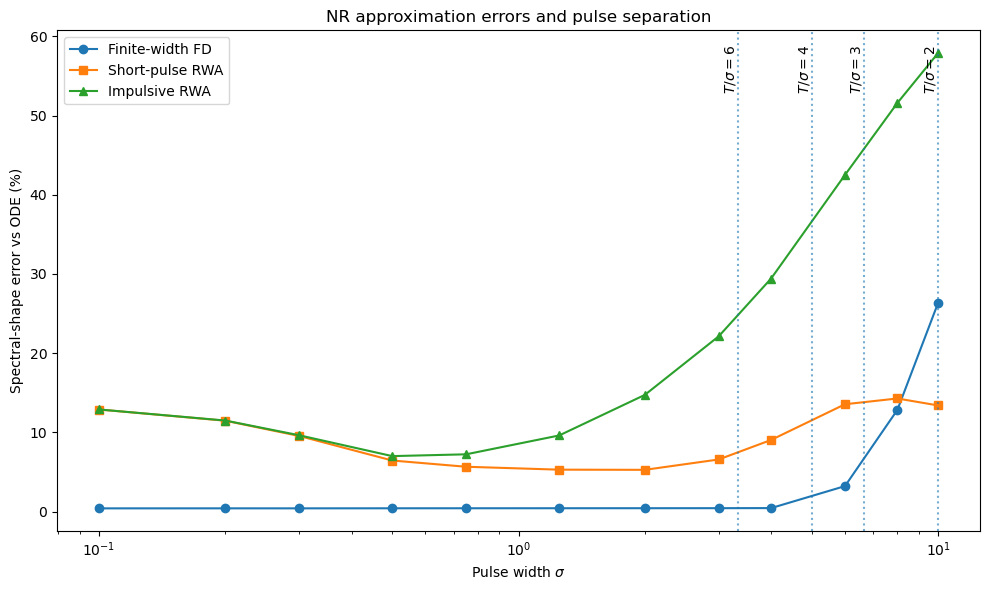

In [161]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    sigma_extended_all,
    100.0 * err_FD_extended_all,
    marker="o",
    label="Finite-width FD",
)

ax.plot(
    sigma_extended_all,
    100.0 * err_short_extended_all,
    marker="s",
    label="Short-pulse RWA",
)

ax.plot(
    sigma_extended_all,
    100.0 * err_imp_extended_all,
    marker="^",
    label="Impulsive RWA",
)

separation_ratios = [
    6,
    4,
    3,
    2,
]

for ratio in separation_ratios:

    sigma_sep = T_bilat / ratio

    ax.axvline(
        sigma_sep,
        linestyle=":",
        alpha=0.6,
    )

    ax.text(
        sigma_sep,
        0.97,
        rf"$T/\sigma={ratio}$",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
    )

ax.set_xscale("log")

ax.set_xlabel(
    r"Pulse width $\sigma$"
)

ax.set_ylabel(
    "Spectral-shape error vs ODE (%)"
)

ax.set_title(
    "NR approximation errors and pulse separation"
)

ax.legend()

plt.tight_layout()

plt.show()

In [162]:
sigma_overlap_extension = np.array([
    12.0,
    15.0,
    20.0,
])

for sigma in sigma_overlap_extension:
    print(
        f"sigma = {sigma:5.1f}   "
        f"T/sigma = {T_bilat/sigma:6.3f}"
    )

sigma =  12.0   T/sigma =  1.667
sigma =  15.0   T/sigma =  1.333
sigma =  20.0   T/sigma =  1.000


In [163]:
def run_NR_overlap_stress_point(
    sigma_test,
):
    """
    Large-sigma overlap stress test.

    IMPORTANT:
    This is outside the well-separated-pulse regime when T/sigma
    becomes small. Results should not be interpreted as a formal
    validation of the separated-pulse FD expression.
    """

    dt_transform = 0.5
    max_step_sigma = 0.2

    # Need enough positive and negative delay range to contain
    # the broad Gaussian pulse structure, while retaining the
    # long Fourier window used in previous convergence tests.
    tmax_sigma = max(
        160.0,
        8.0 * sigma_test,
    )

    t1_sigma = np.arange(
        -8.0 * sigma_test,
        tmax_sigma + 0.5 * dt_transform,
        dt_transform,
    )

    t3_sigma = np.arange(
        -8.0 * sigma_test,
        tmax_sigma + 0.5 * dt_transform,
        dt_transform,
    )

    print()
    print("=" * 64)
    print(f"sigma          = {sigma_test}")
    print(f"T/sigma        = {T_bilat/sigma_test}")
    print(f"tmax           = {tmax_sigma}")
    print(f"t1 points      = {len(t1_sigma)}")
    print(f"t3 points      = {len(t3_sigma)}")
    print("=" * 64)

    # --------------------------------------------------------
    # Sequential finite-pulse full-V ODE
    # --------------------------------------------------------

    P_NR_td = ode_time_domain_grid_controlled(
        s1=+1,
        s2=-1,
        s3=+1,
        sigma=sigma_test,
        T=T_bilat,
        t1_axis=t1_sigma,
        t3_axis=t3_sigma,
        max_step=max_step_sigma,
    )

    P_NR_ODE = transform_NR_ODE_2D(
        P_td=P_NR_td,
        t1_axis=t1_sigma,
        t3_axis=t3_sigma,
        eta_value=eta_bilat,
    )

    # --------------------------------------------------------
    # Finite-width FD
    # --------------------------------------------------------

    P_NR_FD = finite_NR_FD_sigma(
        sigma_test,
        eta_bilat,
    )

    # --------------------------------------------------------
    # Short-pulse RWA
    # --------------------------------------------------------

    P_NR_short = short_NR_RWA_sigma(
        sigma_test,
        eta_bilat,
    )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    raw_FD, alpha_FD, shape_FD = comparison_diagnostics(
        P_NR_FD,
        P_NR_ODE,
    )

    raw_short, alpha_short, shape_short = comparison_diagnostics(
        P_NR_short,
        P_NR_ODE,
    )

    raw_imp, alpha_imp, shape_imp = comparison_diagnostics(
        M_NR_impulsive_bilat,
        P_NR_ODE,
    )

    print()
    print("SHAPE ERRORS")
    print(f"Finite-width FD : {100*shape_FD:8.3f} %")
    print(f"Short-pulse RWA : {100*shape_short:8.3f} %")
    print(f"Impulsive RWA   : {100*shape_imp:8.3f} %")

    print()
    print("RAW ERRORS")
    print(f"Finite-width FD : {100*raw_FD:8.3f} %")
    print(f"Short-pulse RWA : {100*raw_short:8.3f} %")
    print(f"Impulsive RWA   : {100*raw_imp:8.3f} %")

    print()
    print("OPTIMAL SCALE FACTORS")
    print("Finite FD alpha =", alpha_FD)
    print("Short RWA alpha =", alpha_short)
    print("Impulsive alpha =", alpha_imp)

    return {
        "sigma": sigma_test,
        "T_over_sigma": T_bilat / sigma_test,

        "shape_FD": shape_FD,
        "shape_short": shape_short,
        "shape_imp": shape_imp,

        "raw_FD": raw_FD,
        "raw_short": raw_short,
        "raw_imp": raw_imp,

        "alpha_FD": alpha_FD,
        "alpha_short": alpha_short,
        "alpha_imp": alpha_imp,
    }

In [164]:
overlap_results = []

for sigma_test in sigma_overlap_extension:

    result = run_NR_overlap_stress_point(
        sigma_test,
    )

    overlap_results.append(result)


sigma          = 12.0
T/sigma        = 1.6666666666666667
tmax           = 160.0
t1 points      = 513
t3 points      = 513
  t1 1/513
  t1 41/513
  t1 81/513
  t1 121/513
  t1 161/513
  t1 201/513
  t1 241/513
  t1 281/513
  t1 321/513
  t1 361/513
  t1 401/513
  t1 441/513
  t1 481/513

SHAPE ERRORS
Finite-width FD :   40.945 %
Short-pulse RWA :   13.486 %
Impulsive RWA   :   62.733 %

RAW ERRORS
Finite-width FD :  120.934 %
Short-pulse RWA :   15.715 %
Impulsive RWA   :   99.967 %

OPTIMAL SCALE FACTORS
Finite FD alpha = (0.4449556950166758-0.011711214937729501j)
Short RWA alpha = (1.0839162915682132+0.027390113506618737j)
Impulsive alpha = (1831.253836526867+103.52438899494501j)

sigma          = 15.0
T/sigma        = 1.3333333333333333
tmax           = 160.0
t1 points      = 561
t3 points      = 561
  t1 1/561
  t1 41/561
  t1 81/561
  t1 121/561
  t1 161/561
  t1 201/561
  t1 241/561
  t1 281/561
  t1 321/561
  t1 361/561
  t1 401/561
  t1 441/561
  t1 481/561
  t1 521/561
  t1 5

In [165]:
sigma_overlap = np.array([
    r["sigma"]
    for r in overlap_results
])

FD_overlap = np.array([
    r["shape_FD"]
    for r in overlap_results
])

short_overlap = np.array([
    r["shape_short"]
    for r in overlap_results
])

imp_overlap = np.array([
    r["shape_imp"]
    for r in overlap_results
])


sigma_superextended = np.concatenate([
    sigma_extended_all,
    sigma_overlap,
])

FD_superextended = np.concatenate([
    err_FD_extended_all,
    FD_overlap,
])

short_superextended = np.concatenate([
    err_short_extended_all,
    short_overlap,
])

imp_superextended = np.concatenate([
    err_imp_extended_all,
    imp_overlap,
])


order = np.argsort(
    sigma_superextended
)

sigma_superextended = sigma_superextended[order]
FD_superextended = FD_superextended[order]
short_superextended = short_superextended[order]
imp_superextended = imp_superextended[order]

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_overlap_stress_test_vs_sigma.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_overlap_stress_test_vs_sigma.pdf


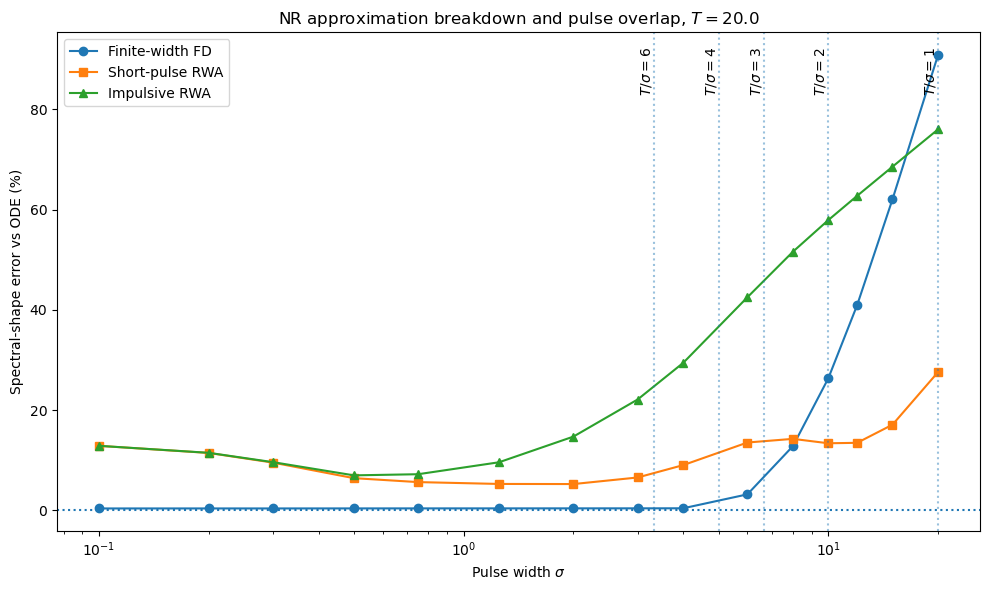

In [166]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    sigma_superextended,
    100.0 * FD_superextended,
    marker="o",
    label="Finite-width FD",
)

ax.plot(
    sigma_superextended,
    100.0 * short_superextended,
    marker="s",
    label="Short-pulse RWA",
)

ax.plot(
    sigma_superextended,
    100.0 * imp_superextended,
    marker="^",
    label="Impulsive RWA",
)

ax.axhline(
    0.0,
    linestyle=":",
)

for ratio in [6, 4, 3, 2, 1]:
    sigma_sep = T_bilat / ratio

    ax.axvline(
        sigma_sep,
        linestyle=":",
        alpha=0.45,
    )

    ax.text(
        sigma_sep,
        0.97,
        rf"$T/\sigma={ratio}$",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
    )

ax.set_xscale("log")

ax.set_xlabel(
    r"Pulse width $\sigma$"
)

ax.set_ylabel(
    "Spectral-shape error vs ODE (%)"
)

ax.set_title(
    rf"NR approximation breakdown and pulse overlap, "
    rf"$T={T_bilat}$"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "NR_overlap_stress_test_vs_sigma.png"
)

pdf_path = (
    figure_dir
    / "NR_overlap_stress_test_vs_sigma.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

### 8.4 Gaussian pulse overlap and breakdown of the separated-pulse FD expression

The finite-width frequency-domain expression used above assumes temporally
separated pulses.

For two equal Gaussian pulse envelopes separated by a fixed center-to-center
delay \(T\),

$$
g_2(t)
=
\exp\left[
-\frac{t^2}{2\sigma^2}
\right],
$$

and

$$
g_3(t)
=
\exp\left[
-\frac{(t-T)^2}{2\sigma^2}
\right].
$$

A normalized overlap measure is

$$
\mathcal O
=
\frac{
\int_{-\infty}^{\infty}
g_2(t)g_3(t)\,dt
}{
\sqrt{
\int g_2^2(t)\,dt
\int g_3^2(t)\,dt
}
},
$$

which evaluates analytically to

$$
\boxed{
\mathcal O(\sigma)
=
\exp\left[
-\frac{T^2}{4\sigma^2}
\right]
}.
$$

Equivalently,

$$
\mathcal O
=
\exp\left[
-\frac{1}{4}
\left(\frac{T}{\sigma}\right)^2
\right].
$$

We compare this analytical pulse-overlap measure with the numerical
spectral-shape error of the separated-pulse finite-width FD response.

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/Gaussian_pulse_overlap_examples_T20.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/Gaussian_pulse_overlap_examples_T20.pdf


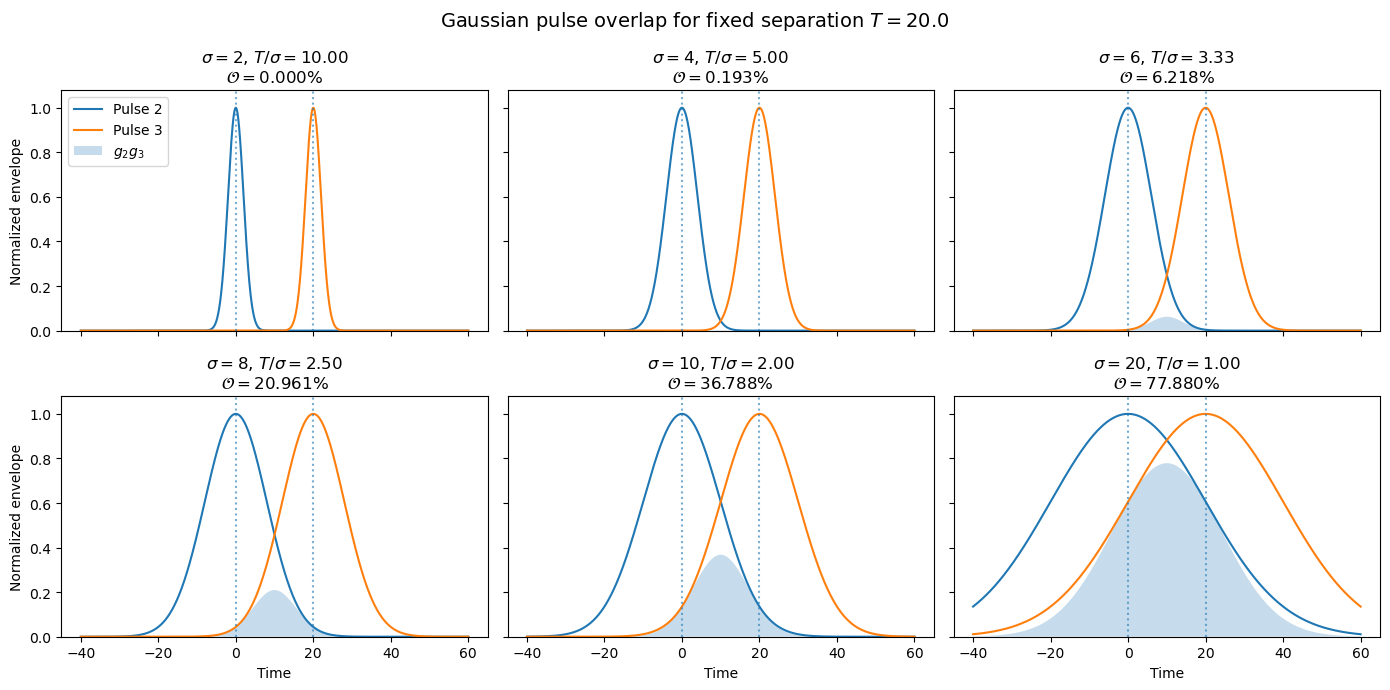

In [167]:
# ------------------------------------------------------------
# Visualize Gaussian overlap between pulses 2 and 3
# ------------------------------------------------------------

sigma_pulse_examples = [
    2.0,
    4.0,
    6.0,
    8.0,
    10.0,
    20.0,
]

T_overlap = T_bilat

t_pulse_plot = np.linspace(
    -40.0,
    60.0,
    4001,
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 7),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()


for ax, sigma_test in zip(
    axes,
    sigma_pulse_examples,
):

    g2 = np.exp(
        -(t_pulse_plot**2)
        / (2.0 * sigma_test**2)
    )

    g3 = np.exp(
        -((t_pulse_plot - T_overlap)**2)
        / (2.0 * sigma_test**2)
    )

    # Product is the integrand entering the
    # analytical overlap measure.
    overlap_integrand = g2 * g3

    overlap_value = np.exp(
        -(T_overlap**2)
        / (4.0 * sigma_test**2)
    )

    ax.plot(
        t_pulse_plot,
        g2,
        label="Pulse 2",
    )

    ax.plot(
        t_pulse_plot,
        g3,
        label="Pulse 3",
    )

    ax.fill_between(
        t_pulse_plot,
        0.0,
        overlap_integrand,
        alpha=0.25,
        label=r"$g_2g_3$",
    )

    ax.axvline(
        0.0,
        linestyle=":",
        alpha=0.6,
    )

    ax.axvline(
        T_overlap,
        linestyle=":",
        alpha=0.6,
    )

    ax.set_title(
        rf"$\sigma={sigma_test:g}$, "
        rf"$T/\sigma={T_overlap/sigma_test:.2f}$"
        "\n"
        rf"$\mathcal{{O}}={100*overlap_value:.3f}\%$"
    )

    ax.set_ylim(
        0.0,
        1.08,
    )


for ax in axes[3:]:
    ax.set_xlabel("Time")

for ax in axes[::3]:
    ax.set_ylabel("Normalized envelope")


axes[0].legend(
    loc="upper left",
)

fig.suptitle(
    rf"Gaussian pulse overlap for fixed separation $T={T_overlap}$",
    fontsize=14,
)

plt.tight_layout()

png_path = (
    figure_dir
    / "Gaussian_pulse_overlap_examples_T20.png"
)

pdf_path = (
    figure_dir
    / "Gaussian_pulse_overlap_examples_T20.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

In [168]:
# ------------------------------------------------------------
# Gaussian overlap for the complete sigma scan
# ------------------------------------------------------------

gaussian_overlap_all = np.exp(
    -(T_bilat**2)
    / (4.0 * sigma_superextended**2)
)

gaussian_overlap_percent = (
    100.0 * gaussian_overlap_all
)


print("GAUSSIAN OVERLAP AND FD ERROR")
print("-----------------------------")
print()
print(
    " sigma    T/sigma    overlap (%)    FD shape error (%)"
)
print(
    "-------------------------------------------------------"
)

for sigma, overlap, fd_error in zip(
    sigma_superextended,
    gaussian_overlap_percent,
    100.0 * FD_superextended,
):

    print(
        f"{sigma:6.2f}   "
        f"{T_bilat/sigma:7.3f}      "
        f"{overlap:9.4f}         "
        f"{fd_error:9.4f}"
    )

GAUSSIAN OVERLAP AND FD ERROR
-----------------------------

 sigma    T/sigma    overlap (%)    FD shape error (%)
-------------------------------------------------------
  0.10   200.000         0.0000            0.3990
  0.20   100.000         0.0000            0.4018
  0.30    66.667         0.0000            0.4001
  0.50    40.000         0.0000            0.4075
  0.75    26.667         0.0000            0.4116
  1.25    16.000         0.0000            0.4144
  2.00    10.000         0.0000            0.4177
  3.00     6.667         0.0015            0.4220
  4.00     5.000         0.1930            0.4324
  6.00     3.333         6.2177            3.2088
  8.00     2.500        20.9611           12.8328
 10.00     2.000        36.7879           26.3330
 12.00     1.667        49.9352           40.9445
 15.00     1.333        64.1180           62.0421
 20.00     1.000        77.8801           90.8136


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/FD_error_vs_Gaussian_overlap_sigma.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/FD_error_vs_Gaussian_overlap_sigma.pdf


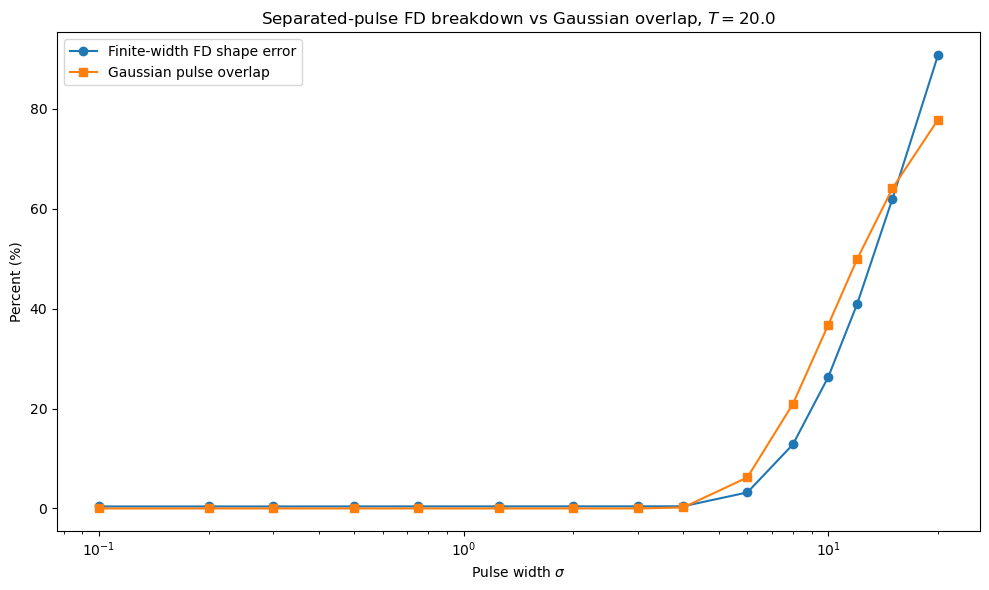

In [169]:
# ------------------------------------------------------------
# FD spectral error versus analytical Gaussian overlap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    sigma_superextended,
    100.0 * FD_superextended,
    marker="o",
    label="Finite-width FD shape error",
)

ax.plot(
    sigma_superextended,
    gaussian_overlap_percent,
    marker="s",
    label="Gaussian pulse overlap",
)

ax.set_xscale("log")

ax.set_xlabel(
    r"Pulse width $\sigma$"
)

ax.set_ylabel(
    "Percent (%)"
)

ax.set_title(
    rf"Separated-pulse FD breakdown vs Gaussian overlap, "
    rf"$T={T_bilat}$"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "FD_error_vs_Gaussian_overlap_sigma.png"
)

pdf_path = (
    figure_dir
    / "FD_error_vs_Gaussian_overlap_sigma.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/FD_error_directly_vs_Gaussian_overlap.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/FD_error_directly_vs_Gaussian_overlap.pdf


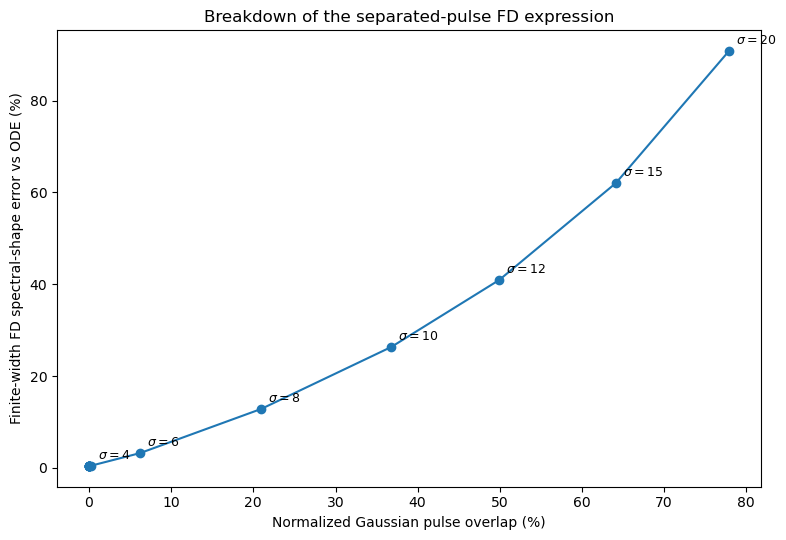

In [170]:
# ------------------------------------------------------------
# FD error directly as a function of Gaussian pulse overlap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5),
)

ax.plot(
    gaussian_overlap_percent,
    100.0 * FD_superextended,
    marker="o",
)

for sigma, overlap, error in zip(
    sigma_superextended,
    gaussian_overlap_percent,
    100.0 * FD_superextended,
):

    # Label only the large-sigma breakdown region
    # to avoid clutter.
    if sigma >= 4.0:

        ax.annotate(
            rf"$\sigma={sigma:g}$",
            (
                overlap,
                error,
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )


ax.set_xlabel(
    "Normalized Gaussian pulse overlap (%)"
)

ax.set_ylabel(
    "Finite-width FD spectral-shape error vs ODE (%)"
)

ax.set_title(
    "Breakdown of the separated-pulse FD expression"
)

plt.tight_layout()

png_path = (
    figure_dir
    / "FD_error_directly_vs_Gaussian_overlap.png"
)

pdf_path = (
    figure_dir
    / "FD_error_directly_vs_Gaussian_overlap.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

In [171]:
# ------------------------------------------------------------
# Analytical pulse-separation thresholds
# ------------------------------------------------------------

overlap_tolerances = np.array([
    0.10,
    0.05,
    0.01,
    0.005,
    0.001,
    0.0001,
])

ratio_thresholds = (
    2.0
    * np.sqrt(
        np.log(
            1.0 / overlap_tolerances
        )
    )
)


print("THEORETICAL GAUSSIAN SEPARATION CRITERIA")
print("----------------------------------------")
print()
print(
    "Allowed overlap       required T/sigma"
)
print(
    "---------------------------------------"
)

for eps, ratio in zip(
    overlap_tolerances,
    ratio_thresholds,
):

    print(
        f"{100*eps:9.4f} %          "
        f"{ratio:8.4f}"
    )

THEORETICAL GAUSSIAN SEPARATION CRITERIA
----------------------------------------

Allowed overlap       required T/sigma
---------------------------------------
  10.0000 %            3.0349
   5.0000 %            3.4616
   1.0000 %            4.2919
   0.5000 %            4.6036
   0.1000 %            5.2565
   0.0100 %            6.0697


## 9. Full three-pulse third-order ODE reference

The previous ODE benchmark imposed the pulse ordering

$$
1\rightarrow2\rightarrow3,
$$

while retaining the full molecular interaction

$$
V=V_\uparrow+V_\downarrow.
$$

This is appropriate in the well-separated-pulse regime, but it does not include
alternative temporal orderings when the pulse envelopes overlap.

We now construct a more complete third-order reference in which every interaction
may originate from any of the three finite laser pulses.

The total real field can be written as

$$
E(t)
=
\sum_{j=1}^{3}
\sum_{s=\pm1}
E_j^{(s)}(t),
$$

with

$$
E_j^{(s)}(t)
=
\frac{E_0}{2}
\exp\left[
-\frac{(t-\tau_j)^2}{2\sigma^2}
\right]
\exp\left[
-is\omega_{Lj}(t-\tau_j)
\right]
e^{is\Phi_j}.
$$

Rather than explicitly repeating the ODE calculation for many pulse phases,
we propagate the Fourier coefficients in the three pulse phases directly.

This procedure is mathematically equivalent to exact phase cycling at third order.

For the nonrephasing signal we extract the phase signature

$$
(+1,-1,+1),
$$

and for the rephasing signal,

$$
(-1,+1,+1).
$$

No rotating-wave approximation and no fixed temporal ordering of the three pulses
are imposed.

In [172]:
# ------------------------------------------------------------
# Phase-index structure for the unrestricted third-order ODE
# ------------------------------------------------------------

from itertools import product

def add_phase_key(a, b):
    return tuple(
        x + y
        for x, y in zip(a, b)
    )

def sub_phase_key(a, b):
    return tuple(
        x - y
        for x, y in zip(a, b)
    )


# Each real pulse contains positive- and negative-frequency
# components.  A component from pulse j changes its phase
# index by +/- 1.
phase_components = []

for j in range(3):

    for s in (-1, +1):

        key = [0, 0, 0]
        key[j] = s

        phase_components.append(
            (
                tuple(key),
                j,
                s,
            )
        )


# First-order phase sectors.
order1_keys = [
    item[0]
    for item in phase_components
]


# All phase sectors reachable after two interactions.
order2_keys = sorted(
    set(
        add_phase_key(a, b)
        for a, b in product(
            order1_keys,
            repeat=2,
        )
    )
)


order1_index = {
    key: i
    for i, key in enumerate(order1_keys)
}

order2_index = {
    key: i
    for i, key in enumerate(order2_keys)
}


n_order1 = len(order1_keys)
n_order2 = len(order2_keys)

print("First-order phase sectors :", n_order1)
print("Second-order phase sectors:", n_order2)

print()
print("First order:")
print(order1_keys)

print()
print("Number of complex ODE variables:")
print(
    (n_order1 + n_order2 + 1) * d**2
)

First-order phase sectors : 6
Second-order phase sectors: 19

First order:
[(-1, 0, 0), (1, 0, 0), (0, -1, 0), (0, 1, 0), (0, 0, -1), (0, 0, 1)]

Number of complex ODE variables:
416


In [173]:
# ------------------------------------------------------------
# Individual complex laser-field components
# ------------------------------------------------------------

def full3_field_component(
    t,
    tau,
    s,
    sigma,
    omega_L,
    E0=1.0,
):
    """
    Coefficient of exp(i*s*Phi_j) in a real Gaussian pulse.
    """

    u = t - tau

    return (
        0.5
        * E0
        * np.exp(
            -u**2
            / (2.0 * sigma**2)
        )
        * np.exp(
            -1j * s * omega_L * u
        )
    )


omega_L_full3 = np.array([
    omega_L1,
    omega_L2,
    omega_L3,
])

Vrho_ss = V @ rho_ss_vec

In [174]:
# ------------------------------------------------------------
# Full three-pulse, phase-resolved third-order ODE
# ------------------------------------------------------------

def full3_phase_resolved_rhs(
    t,
    y,
    taus,
    sigma,
    target_signature,
):
    """
    Exact third-order perturbative hierarchy for three finite
    real pulses.

    Features:
      - full molecular V
      - both +/- frequency components of every pulse
      - every pulse may act at every perturbative order
      - no RWA
      - no imposed 1 -> 2 -> 3 pulse ordering
      - target phase signature extracted analytically
    """

    nL = d**2

    n1_size = n_order1 * nL
    n2_size = n_order2 * nL

    rho1 = y[
        :n1_size
    ].reshape(
        n_order1,
        nL,
    )

    rho2 = y[
        n1_size:n1_size+n2_size
    ].reshape(
        n_order2,
        nL,
    )

    rho3 = y[
        n1_size+n2_size:
    ]


    # --------------------------------------------------------
    # All six complex field components
    # --------------------------------------------------------

    Ecomp = {}

    for phase_key, j, s in phase_components:

        Ecomp[
            (j, s)
        ] = full3_field_component(
            t=t,
            tau=taus[j],
            s=s,
            sigma=sigma,
            omega_L=omega_L_full3[j],
            E0=E0,
        )


    # --------------------------------------------------------
    # First order
    # --------------------------------------------------------

    drho1 = np.zeros_like(
        rho1
    )

    for i, (
        phase_key,
        j,
        s,
    ) in enumerate(
        phase_components
    ):

        drho1[i] = (
            L @ rho1[i]
            + Ecomp[(j, s)]
            * Vrho_ss
        )


    # --------------------------------------------------------
    # Second order
    # --------------------------------------------------------

    drho2 = np.zeros_like(
        rho2
    )

    for i, key2 in enumerate(
        order2_keys
    ):

        value = (
            L @ rho2[i]
        )

        for (
            component_key,
            j,
            s,
        ) in phase_components:

            previous_key = sub_phase_key(
                key2,
                component_key,
            )

            if previous_key in order1_index:

                previous = rho1[
                    order1_index[
                        previous_key
                    ]
                ]

                value += (
                    Ecomp[(j, s)]
                    * (V @ previous)
                )

        drho2[i] = value


    # --------------------------------------------------------
    # Third order
    #
    # We only propagate the requested phase signature.
    # --------------------------------------------------------

    drho3 = (
        L @ rho3
    )

    for (
        component_key,
        j,
        s,
    ) in phase_components:

        previous_key = sub_phase_key(
            target_signature,
            component_key,
        )

        if previous_key in order2_index:

            previous = rho2[
                order2_index[
                    previous_key
                ]
            ]

            drho3 += (
                Ecomp[(j, s)]
                * (V @ previous)
            )


    return np.concatenate([
        drho1.ravel(),
        drho2.ravel(),
        drho3,
    ])

In [175]:
# ------------------------------------------------------------
# Target third-order phase signatures
# ------------------------------------------------------------

target_NR = (
    +1,
    -1,
    +1,
)

target_R = (
    -1,
    +1,
    +1,
)

print("NR target =", target_NR)
print("R target  =", target_R)

print()
print(
    "NR reachable at third order:",
    all(
        key in order2_index
        for key in [
            sub_phase_key(
                target_NR,
                c[0],
            )
            for c in phase_components
            if sub_phase_key(
                target_NR,
                c[0],
            ) in order2_index
        ]
    )
)

NR target = (1, -1, 1)
R target  = (-1, 1, 1)

NR reachable at third order: True


In [176]:
# ------------------------------------------------------------
# Physical full-three-pulse ODE grid
# ------------------------------------------------------------

def full3_ode_time_domain_grid(
    target_signature,
    sigma,
    T,
    t1_axis,
    t3_axis,
    max_step,
    n_sigma_start=8.0,
):
    """
    Full finite-pulse third-order response for physical
    t1 >= 0 and t3 >= 0.

    All pulse orderings generated by pulse overlap are retained.
    """

    nL = d**2

    total_size = (
        n_order1
        + n_order2
        + 1
    ) * nL

    y0 = np.zeros(
        total_size,
        dtype=complex,
    )

    P_td = np.zeros(
        (
            len(t3_axis),
            len(t1_axis),
        ),
        dtype=complex,
    )


    for i, t1 in enumerate(
        t1_axis
    ):

        if (
            i == 0
            or (i + 1) % 20 == 0
            or i == len(t1_axis) - 1
        ):
            print(
                f"  t1 {i+1}/{len(t1_axis)}"
            )

        tau1 = 0.0
        tau2 = t1
        tau3 = t1 + T

        taus = np.array([
            tau1,
            tau2,
            tau3,
        ])

        detection_times = (
            tau3 + t3_axis
        )

        # Start well before the earliest pulse.
        t_start = (
            np.min(taus)
            - n_sigma_start * sigma
        )

        t_stop = (
            detection_times[-1]
        )


        sol = solve_ivp(
            full3_phase_resolved_rhs,
            (
                t_start,
                t_stop,
            ),
            y0,
            t_eval=detection_times,
            args=(
                taus,
                sigma,
                target_signature,
            ),
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=max_step,
        )

        if not sol.success:
            raise RuntimeError(
                sol.message
            )


        rho3 = sol.y[
            -nL:,
            :
        ]

        P_td[:, i] = (
            mu_bra @ rho3
        )


    return P_td

In [177]:
# ------------------------------------------------------------
# Full-three-pulse survey grid
# ------------------------------------------------------------

tmax_full3 = 160.0
dt_full3 = 1.0

t1_full3 = np.arange(
    0.0,
    tmax_full3
    + 0.5 * dt_full3,
    dt_full3,
)

t3_full3 = np.arange(
    0.0,
    tmax_full3
    + 0.5 * dt_full3,
    dt_full3,
)

print(
    "t1 points =",
    len(t1_full3),
)

print(
    "t3 points =",
    len(t3_full3),
)

t1 points = 161
t3 points = 161


In [178]:
# ------------------------------------------------------------
# Sanity check: sigma = 1.25
# ------------------------------------------------------------

sigma_full3_test = 1.25

max_step_full3_test = min(
    0.20,
    sigma_full3_test / 4.0,
)

P_NR_full3_td_test = (
    full3_ode_time_domain_grid(
        target_signature=target_NR,
        sigma=sigma_full3_test,
        T=T_bilat,
        t1_axis=t1_full3,
        t3_axis=t3_full3,
        max_step=max_step_full3_test,
    )
)

P_NR_full3_test = (
    transform_NR_ODE_2D(
        P_td=P_NR_full3_td_test,
        t1_axis=t1_full3,
        t3_axis=t3_full3,
        eta_value=eta_bilat,
    )
)

print(
    "Full-three-pulse spectrum finite:",
    np.all(
        np.isfinite(
            P_NR_full3_test
        )
    ),
)

print(
    "max |P| =",
    np.max(
        np.abs(
            P_NR_full3_test
        )
    ),
)

  t1 1/161
  t1 20/161
  t1 40/161
  t1 60/161
  t1 80/161
  t1 100/161
  t1 120/161
  t1 140/161
  t1 160/161
  t1 161/161
Full-three-pulse spectrum finite: True
max |P| = 2495.3312229397416


In [183]:
# ------------------------------------------------------------
# Compare against full three-pulse ODE
# ------------------------------------------------------------

P_NR_FD_test = finite_NR_FD_sigma(
    sigma_full3_test,
    eta_bilat,
)

P_NR_short_test = short_NR_RWA_sigma(
    sigma_full3_test,
    eta_bilat,
)


raw_FD, alpha_FD, shape_FD = (
    comparison_diagnostics(
        P_NR_FD_test,
        P_NR_full3_test,
    )
)

raw_short, alpha_short, shape_short = (
    comparison_diagnostics(
        P_NR_short_test,
        P_NR_full3_test,
    )
)

_, alpha_imp, shape_imp = (
    comparison_diagnostics(
        M_NR_impulsive_bilat,
        P_NR_full3_test,
    )
)


print(
    "FULL THREE-PULSE NR REFERENCE"
)

print(
    "-----------------------------"
)

print()

print(
    f"Finite-width FD:"
    f" raw = {100*raw_FD:.4f} %, "
    f"shape = {100*shape_FD:.4f} %"
)

print(
    f"Short-pulse RWA:"
    f" raw = {100*raw_short:.4f} %, "
    f"shape = {100*shape_short:.4f} %"
)

print(
    f"Impulsive RWA:"
    f" shape = {100*shape_imp:.4f} %"
)

print()

print(
    "alpha FD    =",
    alpha_FD,
)

print(
    "alpha short =",
    alpha_short,
)

print(
    "alpha imp   =",
    alpha_imp,
)

FULL THREE-PULSE NR REFERENCE
-----------------------------

Finite-width FD: raw = 10.2551 %, shape = 9.8224 %
Short-pulse RWA: raw = 6.7306 %, shape = 6.4304 %
Impulsive RWA: shape = 3.4665 %

alpha FD    = (1.0020628819709332-0.02962175827607471j)
alpha short = (1.0173151309633022-0.010528332549239466j)
alpha imp   = (3.82627705490931-0.03194788620133076j)


### 9.1 Separating Fourier-boundary effects from pulse-ordering effects

The unrestricted three-pulse ODE at \(\sigma=1.25\) differs from the
finite-width FD result by approximately \(10\%\) when a physical
\(t_1,t_3\ge0\) transform is used.

Two effects are mixed in this comparison:

1. the finite-width FD expression was derived using the complete pulse-offset
   integrals, whereas the physical ODE spectrum is Fourier transformed only for
   nonnegative delays;

2. when \(t_1\) is close to zero, pulses 1 and 2 overlap and the unrestricted
   ODE contains temporal orderings other than \(1\rightarrow2\rightarrow3\).

To separate these effects, we compare the sequential and unrestricted
third-order ODEs on exactly the same positive-delay grid.

In [184]:
# ------------------------------------------------------------
# Sequential ODE on exactly the same positive-delay grid
# ------------------------------------------------------------

sigma_order_test = 1.25

max_step_order_test = min(
    0.20,
    sigma_order_test / 4.0,
)

P_NR_seq_positive_td = ode_time_domain_grid_controlled(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_order_test,
    T=T_bilat,
    t1_axis=t1_full3,
    t3_axis=t3_full3,
    max_step=max_step_order_test,
)

P_NR_seq_positive = transform_NR_ODE_2D(
    P_td=P_NR_seq_positive_td,
    t1_axis=t1_full3,
    t3_axis=t3_full3,
    eta_value=eta_bilat,
)

print(
    "Sequential positive-grid spectrum finite:",
    np.all(np.isfinite(P_NR_seq_positive)),
)

  t1 1/161
  t1 41/161
  t1 81/161
  t1 121/161
  t1 161/161
Sequential positive-grid spectrum finite: True


In [185]:
# ------------------------------------------------------------
# Disentangle the sources of disagreement
# ------------------------------------------------------------

# FD vs sequential ODE on positive-only grid
raw_FD_seq, alpha_FD_seq, shape_FD_seq = (
    comparison_diagnostics(
        P_NR_FD_test,
        P_NR_seq_positive,
    )
)

# Unrestricted ODE vs sequential ODE
raw_full3_seq, alpha_full3_seq, shape_full3_seq = (
    comparison_diagnostics(
        P_NR_full3_test,
        P_NR_seq_positive,
    )
)

# FD vs unrestricted three-pulse ODE
raw_FD_full3, alpha_FD_full3, shape_FD_full3 = (
    comparison_diagnostics(
        P_NR_FD_test,
        P_NR_full3_test,
    )
)


print("ERROR DECOMPOSITION — sigma = 1.25")
print("----------------------------------")
print()

print("1. FD vs sequential ODE, same positive grid")
print(f"   raw error   = {100*raw_FD_seq:8.4f} %")
print(f"   shape error = {100*shape_FD_seq:8.4f} %")
print(f"   alpha       = {alpha_FD_seq}")
print()

print("2. Full three-pulse ODE vs sequential ODE")
print(f"   raw error   = {100*raw_full3_seq:8.4f} %")
print(f"   shape error = {100*shape_full3_seq:8.4f} %")
print(f"   alpha       = {alpha_full3_seq}")
print()

print("3. FD vs full three-pulse ODE")
print(f"   raw error   = {100*raw_FD_full3:8.4f} %")
print(f"   shape error = {100*shape_FD_full3:8.4f} %")
print(f"   alpha       = {alpha_FD_full3}")

ERROR DECOMPOSITION — sigma = 1.25
----------------------------------

1. FD vs sequential ODE, same positive grid
   raw error   =  11.6180 %
   shape error =  10.3197 %
   alpha       = (0.9547493563504836-0.024045542479162633j)

2. Full three-pulse ODE vs sequential ODE
   raw error   =   9.2978 %
   shape error =   7.6986 %
   alpha       = (0.9503224757704674-0.0011772475632223168j)

3. FD vs full three-pulse ODE
   raw error   =  10.2551 %
   shape error =   9.8224 %
   alpha       = (1.0020628819709332-0.02962175827607471j)


In [186]:
# ------------------------------------------------------------
# Exclude progressively more pulse-1 / pulse-2 overlap
# ------------------------------------------------------------

cutoff_sigma_values = np.array([
    0.0,
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
    6.0,
])

cutoff_errors_raw = []
cutoff_errors_shape = []
cutoff_alphas = []
cutoff_actual_t1 = []


for n_sigma in cutoff_sigma_values:

    requested_cut = (
        n_sigma * sigma_order_test
    )

    mask = (
        t1_full3 >= requested_cut
    )

    t1_cut = t1_full3[mask]

    P_seq_cut_td = (
        P_NR_seq_positive_td[:, mask]
    )

    P_full3_cut_td = (
        P_NR_full3_td_test[:, mask]
    )

    P_seq_cut = transform_NR_ODE_2D(
        P_td=P_seq_cut_td,
        t1_axis=t1_cut,
        t3_axis=t3_full3,
        eta_value=eta_bilat,
    )

    P_full3_cut = transform_NR_ODE_2D(
        P_td=P_full3_cut_td,
        t1_axis=t1_cut,
        t3_axis=t3_full3,
        eta_value=eta_bilat,
    )

    raw, alpha, shape = comparison_diagnostics(
        P_full3_cut,
        P_seq_cut,
    )

    cutoff_errors_raw.append(raw)
    cutoff_errors_shape.append(shape)
    cutoff_alphas.append(alpha)

    cutoff_actual_t1.append(
        t1_cut[0]
    )


cutoff_errors_raw = np.array(
    cutoff_errors_raw
)

cutoff_errors_shape = np.array(
    cutoff_errors_shape
)

cutoff_alphas = np.array(
    cutoff_alphas
)

cutoff_actual_t1 = np.array(
    cutoff_actual_t1
)

In [187]:
# ------------------------------------------------------------
# Relate ordering error to pulse-1 / pulse-2 overlap
# ------------------------------------------------------------

overlap12_at_cutoff = np.exp(
    -(cutoff_actual_t1**2)
    / (4.0 * sigma_order_test**2)
)

print("PULSE-ORDERING ERROR VS t1 CUTOFF")
print("---------------------------------")
print()
print(
    " cut/sigma   actual t1   overlap12     "
    "raw error    shape error"
)
print(
    "------------------------------------------------------------"
)

for n_sig, tcut, overlap, raw, shape in zip(
    cutoff_sigma_values,
    cutoff_actual_t1,
    overlap12_at_cutoff,
    cutoff_errors_raw,
    cutoff_errors_shape,
):

    print(
        f"{n_sig:8.2f}   "
        f"{tcut:9.3f}   "
        f"{100*overlap:9.4f}%   "
        f"{100*raw:9.4f}%   "
        f"{100*shape:10.4f}%"
    )

PULSE-ORDERING ERROR VS t1 CUTOFF
---------------------------------

 cut/sigma   actual t1   overlap12     raw error    shape error
------------------------------------------------------------
    0.00       0.000    100.0000%      9.2978%       7.6986%
    0.50       1.000     85.2144%      4.5108%       3.8083%
    1.00       2.000     52.7292%      1.8124%       1.5547%
    2.00       3.000     23.6928%      0.5836%       0.5070%
    3.00       4.000      7.7305%      0.1465%       0.1285%
    4.00       5.000      1.8316%      0.0281%       0.0248%
    5.00       7.000      0.0394%      0.0004%       0.0004%
    6.00       8.000      0.0036%      0.0000%       0.0000%


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_full3_vs_sequential_t1_cutoff.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_full3_vs_sequential_t1_cutoff.pdf


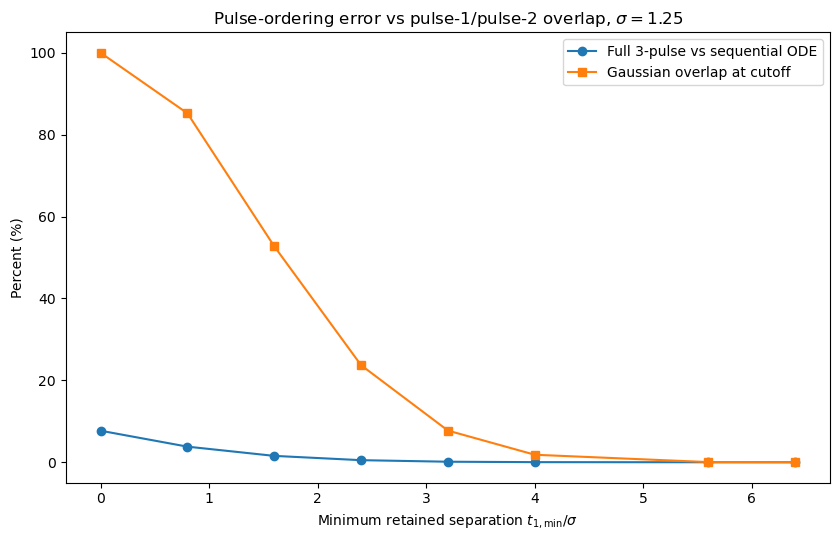

In [188]:
fig, ax = plt.subplots(
    figsize=(8.5, 5.5),
)

ax.plot(
    cutoff_actual_t1 / sigma_order_test,
    100.0 * cutoff_errors_shape,
    marker="o",
    label="Full 3-pulse vs sequential ODE",
)

ax.plot(
    cutoff_actual_t1 / sigma_order_test,
    100.0 * overlap12_at_cutoff,
    marker="s",
    label="Gaussian overlap at cutoff",
)

ax.set_xlabel(
    r"Minimum retained separation $t_{1,\min}/\sigma$"
)

ax.set_ylabel(
    "Percent (%)"
)

ax.set_title(
    rf"Pulse-ordering error vs pulse-1/pulse-2 overlap, "
    rf"$\sigma={sigma_order_test}$"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "NR_full3_vs_sequential_t1_cutoff.png"
)

pdf_path = (
    figure_dir
    / "NR_full3_vs_sequential_t1_cutoff.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_ordering_error_vs_overlap12.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_ordering_error_vs_overlap12.pdf


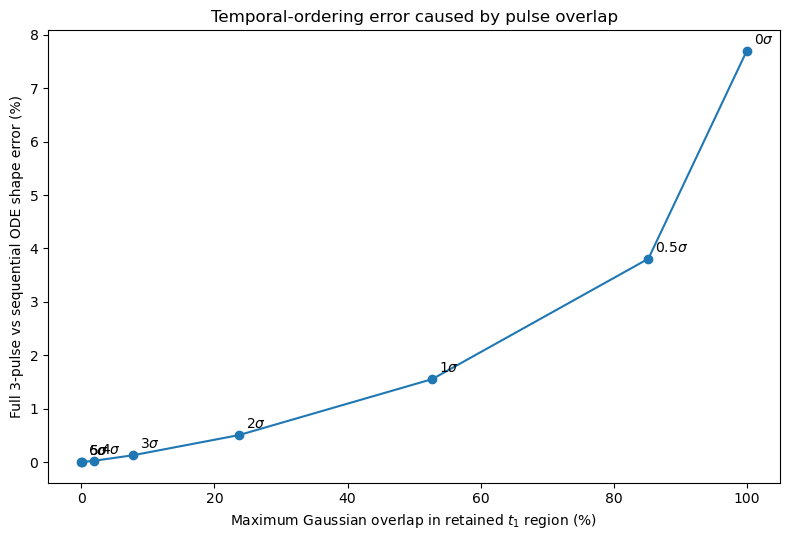

In [189]:
fig, ax = plt.subplots(
    figsize=(8, 5.5),
)

ax.plot(
    100.0 * overlap12_at_cutoff,
    100.0 * cutoff_errors_shape,
    marker="o",
)

for n_sig, overlap, err in zip(
    cutoff_sigma_values,
    100.0 * overlap12_at_cutoff,
    100.0 * cutoff_errors_shape,
):

    ax.annotate(
        rf"${n_sig:g}\sigma$",
        (overlap, err),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_xlabel(
    "Maximum Gaussian overlap in retained $t_1$ region (%)"
)

ax.set_ylabel(
    "Full 3-pulse vs sequential ODE shape error (%)"
)

ax.set_title(
    "Temporal-ordering error caused by pulse overlap"
)

plt.tight_layout()

png_path = (
    figure_dir
    / "NR_ordering_error_vs_overlap12.png"
)

pdf_path = (
    figure_dir
    / "NR_ordering_error_vs_overlap12.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_ordering_error_and_overlap_dual_axis.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_ordering_error_and_overlap_dual_axis.pdf


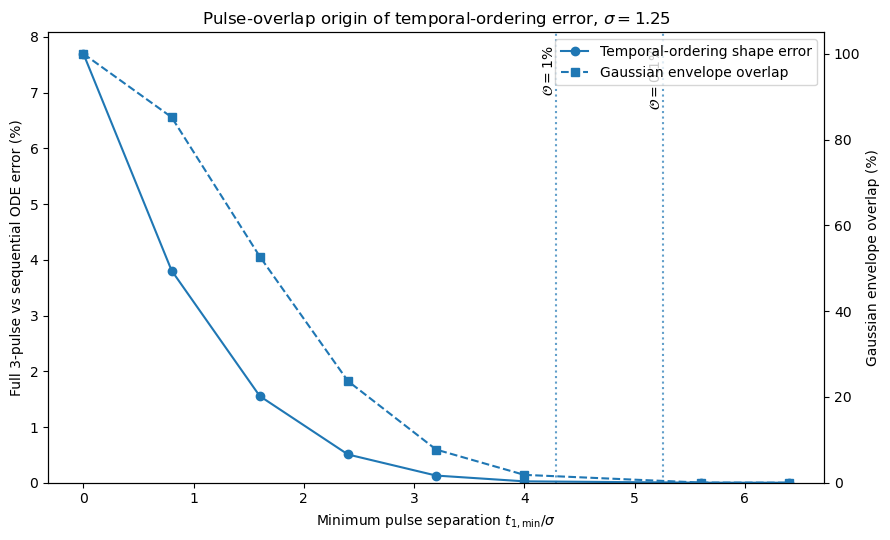

In [190]:
# ------------------------------------------------------------
# Cleaner pulse-overlap / ordering-error figure
# ------------------------------------------------------------

actual_cut_sigma = (
    cutoff_actual_t1
    / sigma_order_test
)

fig, ax1 = plt.subplots(
    figsize=(9, 5.5)
)

line1 = ax1.plot(
    actual_cut_sigma,
    100.0 * cutoff_errors_shape,
    marker="o",
    label="Temporal-ordering shape error",
)

ax1.set_xlabel(
    r"Minimum pulse separation $t_{1,\min}/\sigma$"
)

ax1.set_ylabel(
    "Full 3-pulse vs sequential ODE error (%)"
)

ax1.set_ylim(
    bottom=0.0,
)

ax2 = ax1.twinx()

line2 = ax2.plot(
    actual_cut_sigma,
    100.0 * overlap12_at_cutoff,
    marker="s",
    linestyle="--",
    label="Gaussian envelope overlap",
)

ax2.set_ylabel(
    "Gaussian envelope overlap (%)"
)

ax2.set_ylim(
    0.0,
    105.0,
)

# Analytical 1% and 0.1% overlap boundaries
ratio_1pct = (
    2.0 * np.sqrt(np.log(100.0))
)

ratio_01pct = (
    2.0 * np.sqrt(np.log(1000.0))
)

ax1.axvline(
    ratio_1pct,
    linestyle=":",
    alpha=0.7,
)

ax1.axvline(
    ratio_01pct,
    linestyle=":",
    alpha=0.7,
)

ax1.text(
    ratio_1pct,
    0.97,
    r"$\mathcal{O}=1\%$",
    transform=ax1.get_xaxis_transform(),
    rotation=90,
    va="top",
    ha="right",
)

ax1.text(
    ratio_01pct,
    0.97,
    r"$\mathcal{O}=0.1\%$",
    transform=ax1.get_xaxis_transform(),
    rotation=90,
    va="top",
    ha="right",
)

lines = line1 + line2
labels = [
    line.get_label()
    for line in lines
]

ax1.legend(
    lines,
    labels,
    loc="upper right",
)

ax1.set_title(
    rf"Pulse-overlap origin of temporal-ordering error, "
    rf"$\sigma={sigma_order_test}$"
)

fig.tight_layout()

png_path = (
    figure_dir
    / "NR_ordering_error_and_overlap_dual_axis.png"
)

pdf_path = (
    figure_dir
    / "NR_ordering_error_and_overlap_dual_axis.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

## 10. Three pulse-width regimes

The unrestricted three-pulse ODE confirms that the sequential full-\(V\)
third-order ODE becomes equivalent to the unrestricted calculation when
neighboring Gaussian pulses are sufficiently separated.

For the present Gaussian pulses, temporal-ordering corrections become
negligible at separations of approximately \(4\)–\(5\sigma\).

We therefore use the sequential full-\(V\), non-RWA finite-pulse ODE as the
reference for studying pulse-width approximations while restricting the scan
to the separated-pulse domain,

$$
T/\sigma \gtrsim 5.
$$

Three regimes are expected:

1. **Ultrashort / non-RWA regime:** the pulse bandwidth is sufficiently broad
   that counter-rotating contributions are not strongly suppressed.

2. **Impulsive-RWA window:** counter-rotating contributions are suppressed
   while molecular evolution during the pulse remains weak.

3. **Finite-pulse regime:** molecular evolution during the pulse becomes
   important, so impulsive and short-pulse approximations increasingly fail.

The finite-width full-\(V\) frequency-domain treatment is expected to remain
accurate throughout all three regimes.

In [191]:
# ------------------------------------------------------------
# Extreme ultrashort point: sigma = 0.05
# ------------------------------------------------------------

sigma_ultra = 0.05

dt_ultra = 0.10
tmax_ultra = 120.0

t1_ultra = np.arange(
    -8.0 * sigma_ultra,
    tmax_ultra + 0.5 * dt_ultra,
    dt_ultra,
)

t3_ultra = np.arange(
    -8.0 * sigma_ultra,
    tmax_ultra + 0.5 * dt_ultra,
    dt_ultra,
)

max_step_ultra = 0.01

print("sigma =", sigma_ultra)
print("T/sigma =", T_bilat / sigma_ultra)
print("dt transform =", dt_ultra)
print("ODE max step =", max_step_ultra)
print("t1 points =", len(t1_ultra))
print("t3 points =", len(t3_ultra))

sigma = 0.05
T/sigma = 400.0
dt transform = 0.1
ODE max step = 0.01
t1 points = 1205
t3 points = 1205


In [192]:
P_NR_td_ultra = ode_time_domain_grid_controlled(
    s1=+1,
    s2=-1,
    s3=+1,
    sigma=sigma_ultra,
    T=T_bilat,
    t1_axis=t1_ultra,
    t3_axis=t3_ultra,
    max_step=max_step_ultra,
)

P_NR_ODE_ultra = transform_NR_ODE_2D(
    P_td=P_NR_td_ultra,
    t1_axis=t1_ultra,
    t3_axis=t3_ultra,
    eta_value=eta_bilat,
)

  t1 1/1205
  t1 41/1205
  t1 81/1205
  t1 121/1205
  t1 161/1205
  t1 201/1205
  t1 241/1205
  t1 281/1205
  t1 321/1205
  t1 361/1205
  t1 401/1205
  t1 441/1205
  t1 481/1205
  t1 521/1205
  t1 561/1205
  t1 601/1205
  t1 641/1205
  t1 681/1205
  t1 721/1205
  t1 761/1205
  t1 801/1205
  t1 841/1205
  t1 881/1205
  t1 921/1205
  t1 961/1205
  t1 1001/1205
  t1 1041/1205
  t1 1081/1205
  t1 1121/1205
  t1 1161/1205
  t1 1201/1205


In [193]:
P_NR_FD_ultra = finite_NR_FD_sigma(
    sigma_ultra,
    eta_bilat,
)

P_NR_short_ultra = short_NR_RWA_sigma(
    sigma_ultra,
    eta_bilat,
)

_, alpha_FD_ultra, shape_FD_ultra = comparison_diagnostics(
    P_NR_FD_ultra,
    P_NR_ODE_ultra,
)

_, alpha_short_ultra, shape_short_ultra = comparison_diagnostics(
    P_NR_short_ultra,
    P_NR_ODE_ultra,
)

_, alpha_imp_ultra, shape_imp_ultra = comparison_diagnostics(
    M_NR_impulsive_bilat,
    P_NR_ODE_ultra,
)

print("sigma = 0.05")
print("----------------")
print(
    f"Finite-width FD : {100*shape_FD_ultra:8.4f} %"
)
print(
    f"Short-pulse RWA : {100*shape_short_ultra:8.4f} %"
)
print(
    f"Impulsive RWA   : {100*shape_imp_ultra:8.4f} %"
)

sigma = 0.05
----------------
Finite-width FD :   0.3975 %
Short-pulse RWA :  13.2676 %
Impulsive RWA   :  13.2684 %


In [194]:
# ------------------------------------------------------------
# Three-regime data restricted to separated pulses
# ------------------------------------------------------------

sigma_regime_scan = np.array([
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
    0.75,
    1.25,
    2.00,
    3.00,
    4.00,
])

# Values already computed in the extended scan.
existing_lookup = {
    float(s): (fd, short, imp)
    for s, fd, short, imp in zip(
        sigma_extended_all,
        err_FD_extended_all,
        err_short_extended_all,
        err_imp_extended_all,
    )
}


FD_regime = []
short_regime = []
imp_regime = []

for sigma in sigma_regime_scan:

    if np.isclose(
        sigma,
        sigma_ultra,
    ):
        FD_regime.append(
            shape_FD_ultra
        )
        short_regime.append(
            shape_short_ultra
        )
        imp_regime.append(
            shape_imp_ultra
        )

    else:
        fd, short, imp = existing_lookup[
            float(sigma)
        ]

        FD_regime.append(fd)
        short_regime.append(short)
        imp_regime.append(imp)


FD_regime = np.array(FD_regime)
short_regime = np.array(short_regime)
imp_regime = np.array(imp_regime)

In [195]:
Delta_CR = (
    Omega_plus
    + omega_L1
)

chi_CR_regime = (
    Delta_CR
    * sigma_regime_scan
)

chi_J_regime = (
    abs(J)
    * sigma_regime_scan
)

chi_gamma_regime = (
    max(gamma_a, gamma_b)
    * sigma_regime_scan
)

In [196]:
print("NR THREE-REGIME BENCHMARK")
print("-------------------------")
print()

print(
    "sigma   DCR*sigma   J*sigma   "
    "FD error    Short RWA    Impulsive RWA"
)

print(
    "-------------------------------------------------------------"
)

for (
    sigma,
    chi_cr,
    chi_j,
    fd,
    short,
    imp,
) in zip(
    sigma_regime_scan,
    chi_CR_regime,
    chi_J_regime,
    FD_regime,
    short_regime,
    imp_regime,
):

    print(
        f"{sigma:5.2f}    "
        f"{chi_cr:8.3f}    "
        f"{chi_j:7.3f}    "
        f"{100*fd:8.3f}%    "
        f"{100*short:8.3f}%    "
        f"{100*imp:8.3f}%"
    )

NR THREE-REGIME BENCHMARK
-------------------------

sigma   DCR*sigma   J*sigma   FD error    Short RWA    Impulsive RWA
-------------------------------------------------------------
 0.05       0.124      0.005       0.398%      13.268%      13.268%
 0.10       0.248      0.010       0.399%      12.883%      12.886%
 0.20       0.497      0.020       0.402%      11.466%      11.490%
 0.30       0.745      0.030       0.400%       9.540%       9.630%
 0.50       1.241      0.050       0.408%       6.441%       6.997%
 0.75       1.862      0.075       0.412%       5.653%       7.224%
 1.25       3.104      0.125       0.414%       5.285%       9.605%
 2.00       4.966      0.200       0.418%       5.263%      14.726%
 3.00       7.449      0.300       0.422%       6.572%      22.122%
 4.00       9.931      0.400       0.432%       9.036%      29.421%


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_three_physical_regimes.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/NR_three_physical_regimes.pdf


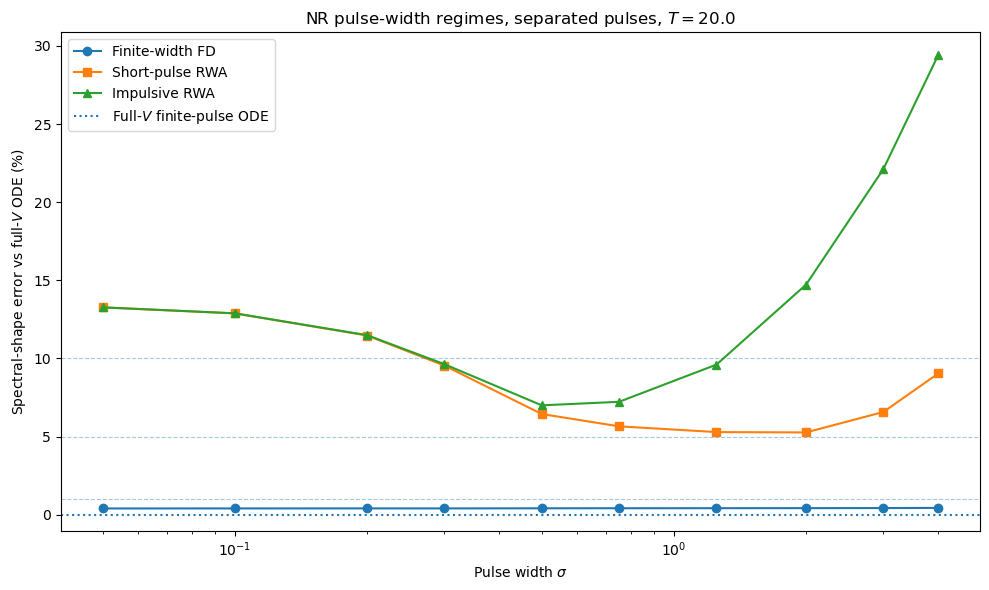

In [197]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    sigma_regime_scan,
    100.0 * FD_regime,
    marker="o",
    label="Finite-width FD",
)

ax.plot(
    sigma_regime_scan,
    100.0 * short_regime,
    marker="s",
    label="Short-pulse RWA",
)

ax.plot(
    sigma_regime_scan,
    100.0 * imp_regime,
    marker="^",
    label="Impulsive RWA",
)

ax.axhline(
    0.0,
    linestyle=":",
    label="Full-$V$ finite-pulse ODE",
)

for level in [
    1.0,
    5.0,
    10.0,
]:
    ax.axhline(
        level,
        linestyle="--",
        linewidth=0.8,
        alpha=0.4,
    )

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    r"Pulse width $\sigma$"
)

ax.set_ylabel(
    "Spectral-shape error vs full-$V$ ODE (%)"
)

ax.set_title(
    rf"NR pulse-width regimes, separated pulses, "
    rf"$T={T_bilat}$"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "NR_three_physical_regimes.png"
)

pdf_path = (
    figure_dir
    / "NR_three_physical_regimes.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

## Figure B: Breakdown of the separated-pulse approximation

The finite-width frequency-domain formulation assumes temporally separated
laser pulses.

For two equal Gaussian envelopes separated by \(T\), the normalized overlap is

$$
\mathcal O(\sigma)
=
\exp\left[
-\frac{T^2}{4\sigma^2}
\right].
$$

We compare this analytical overlap directly with the spectral-shape error of
the finite-width FD response relative to the finite-pulse ODE.

The purpose of this figure is different from the three-regime comparison.
Here the pulse width is intentionally increased until the separated-pulse
assumption itself fails.

In [198]:
# ------------------------------------------------------------
# Figure B data: separated-pulse breakdown
# ------------------------------------------------------------

sigma_B = np.array([
    3.0,
    4.0,
    6.0,
    8.0,
    10.0,
    12.0,
    15.0,
    20.0,
])

# Look up the corresponding FD errors from the completed scan.
FD_lookup = {
    float(s): float(err)
    for s, err in zip(
        sigma_superextended,
        FD_superextended,
    )
}

FD_error_B = np.array([
    FD_lookup[float(s)]
    for s in sigma_B
])

overlap_B = np.exp(
    -(T_bilat**2)
    / (4.0 * sigma_B**2)
)

overlap_B_percent = (
    100.0 * overlap_B
)

FD_error_B_percent = (
    100.0 * FD_error_B
)

T_over_sigma_B = (
    T_bilat / sigma_B
)


print("FIGURE B DATA")
print("-------------")
print()
print(
    "sigma    T/sigma    Gaussian overlap (%)    FD error (%)"
)
print(
    "----------------------------------------------------------"
)

for sigma, ratio, overlap, error in zip(
    sigma_B,
    T_over_sigma_B,
    overlap_B_percent,
    FD_error_B_percent,
):

    print(
        f"{sigma:5.1f}     "
        f"{ratio:7.3f}          "
        f"{overlap:9.3f}          "
        f"{error:9.3f}"
    )

FIGURE B DATA
-------------

sigma    T/sigma    Gaussian overlap (%)    FD error (%)
----------------------------------------------------------
  3.0       6.667              0.001              0.422
  4.0       5.000              0.193              0.432
  6.0       3.333              6.218              3.209
  8.0       2.500             20.961             12.833
 10.0       2.000             36.788             26.333
 12.0       1.667             49.935             40.945
 15.0       1.333             64.118             62.042
 20.0       1.000             77.880             90.814


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/Figure_B_FD_breakdown_vs_pulse_overlap.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/Figure_B_FD_breakdown_vs_pulse_overlap.pdf


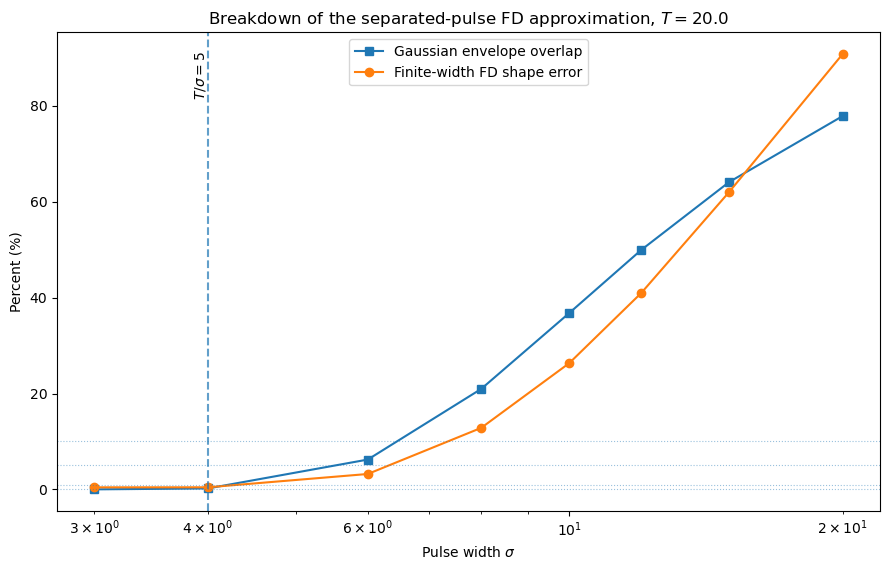

In [199]:
# ------------------------------------------------------------
# Figure B:
# Gaussian pulse overlap and separated-pulse FD breakdown
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5.8),
)

ax.plot(
    sigma_B,
    overlap_B_percent,
    marker="s",
    label="Gaussian envelope overlap",
)

ax.plot(
    sigma_B,
    FD_error_B_percent,
    marker="o",
    label="Finite-width FD shape error",
)

# Analytical overlap thresholds
for overlap_level in [
    0.1,
    1.0,
    5.0,
    10.0,
]:
    ax.axhline(
        overlap_level,
        linestyle=":",
        linewidth=0.8,
        alpha=0.45,
    )

# Mark conservative ~5 sigma separation.
sigma_5sep = (
    T_bilat / 5.0
)

ax.axvline(
    sigma_5sep,
    linestyle="--",
    alpha=0.7,
)

ax.text(
    sigma_5sep,
    0.96,
    r"$T/\sigma=5$",
    transform=ax.get_xaxis_transform(),
    rotation=90,
    va="top",
    ha="right",
)

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    r"Pulse width $\sigma$"
)

ax.set_ylabel(
    "Percent (%)"
)

ax.set_title(
    rf"Breakdown of the separated-pulse FD approximation, "
    rf"$T={T_bilat}$"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "Figure_B_FD_breakdown_vs_pulse_overlap.png"
)

pdf_path = (
    figure_dir
    / "Figure_B_FD_breakdown_vs_pulse_overlap.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/Figure_B_FD_error_directly_vs_overlap.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/Figure_B_FD_error_directly_vs_overlap.pdf


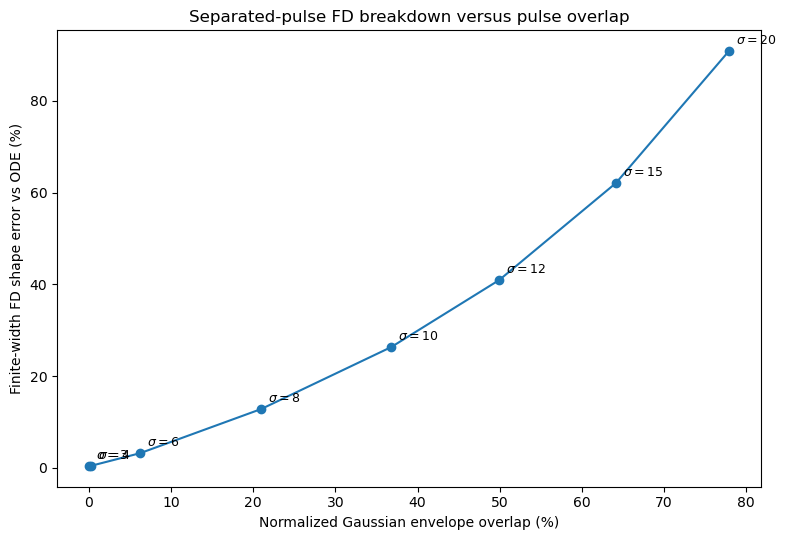

In [200]:
# ------------------------------------------------------------
# Figure B companion:
# FD error directly versus Gaussian overlap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5),
)

ax.plot(
    overlap_B_percent,
    FD_error_B_percent,
    marker="o",
)

for sigma, overlap, error in zip(
    sigma_B,
    overlap_B_percent,
    FD_error_B_percent,
):

    ax.annotate(
        rf"$\sigma={sigma:g}$",
        (
            overlap,
            error,
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel(
    "Normalized Gaussian envelope overlap (%)"
)

ax.set_ylabel(
    "Finite-width FD shape error vs ODE (%)"
)

ax.set_title(
    "Separated-pulse FD breakdown versus pulse overlap"
)

plt.tight_layout()

png_path = (
    figure_dir
    / "Figure_B_FD_error_directly_vs_overlap.png"
)

pdf_path = (
    figure_dir
    / "Figure_B_FD_error_directly_vs_overlap.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

## 11. Summary and conclusions

This notebook validates the finite-width direct frequency-domain formulation
for third-order nonlinear spectroscopy.

The main conclusions are:

1. The analytical finite-pulse operators \(F_1\), \(F_2\), and \(F_3\) agree
   with their direct numerical time-domain integrals to approximately
   \(10^{-13}\).

2. For a stationary initial state,

   $$
   F_1^{(s)}|\rho_{\mathrm{ss}}\rangle\rangle
   =
   E_1^{(s)}|\rho_{\mathrm{ss}}\rangle\rangle,
   $$

   as expected from
   \(\mathcal L|\rho_{\mathrm{ss}}\rangle\rangle=0\).

3. The full-\(V\) finite-width frequency-domain response converges to the
   explicit finite-pulse ODE result. At
   \(\sigma=1.25\), \(T=20\), and a converged Fourier window,

   $$
   \epsilon_{\mathrm{FD/ODE}}^{\mathrm{NR}}
   =
   0.0586\%,
   $$

   and

   $$
   \epsilon_{\mathrm{FD/ODE}}^{\mathrm{R}}
   =
   0.0582\%.
   $$

4. Three distinct pulse-width regimes are observed in the separated-pulse
   domain:

   - an ultrashort regime in which the rotating-wave approximation fails;
   - an intermediate impulsive-RWA regime in which conventional pathway
     descriptions are most accurate;
   - a finite-pulse regime in which evolution during the laser pulse becomes
     important and impulsive approximations deteriorate.

   The finite-width full-\(V\) formulation remains accurate throughout these
   regimes.

5. The separated-pulse assumption can be quantified using the normalized
   overlap of two equal Gaussian envelopes,

   $$
   \mathcal O
   =
   \exp\left[
   -\frac{\Delta\tau^2}{4\sigma^2}
   \right].
   $$

   The unrestricted three-pulse ODE confirms that temporal-ordering
   corrections become negligible as neighboring pulse overlaps vanish.

6. A conservative separation of approximately

   $$
   \Delta\tau \gtrsim 5\sigma
   $$

   corresponds to very small Gaussian overlap and provides a practical
   separated-pulse criterion for the present calculations.

7. When the pulses overlap strongly, the separated-pulse finite-width
   factorization leaves its domain of validity and its error grows rapidly.

Together, these calculations establish both the numerical correctness and
the domain of validity of the finite-width direct frequency-domain method.

In [201]:
# ------------------------------------------------------------
# Save final Notebook 04 validation data
# ------------------------------------------------------------

validation_file = (
    figure_dir
    / "notebook04_validation_data.npz"
)

np.savez(
    validation_file,

    # Three-regime benchmark
    sigma_regime=sigma_regime_scan,
    FD_regime=FD_regime,
    short_regime=short_regime,
    impulsive_regime=imp_regime,

    # Pulse-overlap breakdown
    sigma_overlap=sigma_B,
    gaussian_overlap=overlap_B,
    FD_overlap_error=FD_error_B,

    # Full3 vs sequential ordering test
    cutoff_actual_t1=cutoff_actual_t1,
    cutoff_shape_error=cutoff_errors_shape,
    cutoff_raw_error=cutoff_errors_raw,
    overlap12_at_cutoff=overlap12_at_cutoff,

    # Flagship converged validation
    NR_FD_shape_tmax160=shape_NR_FD_160,
    R_FD_shape_tmax160=shape_R_FD_160,
)

print("Saved:")
print(validation_file)

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/04_finite_pulse_validation/notebook04_validation_data.npz
